# **PREPARACIÓN**

In [ ]:
!pip install roboflow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 146.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="vAIN3xc5BdYzwV5xdllL")
project = rf.workspace("neuros-workspace").project("registradora_ahora_si")
version = project.version(2)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Registradora_ahora_si-2 in yolov8:: 100%|██████████| 2447/2447 [00:00<00:00, 4453.65it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
ruta_yaml = '/content/Registradora_ahora_si-2/README.roboflow.txt'

with open(ruta_yaml, "r") as file:
    contenido = file.read()

print(contenido)


Registradora_ahora_si - v2 2026-03-27 9:23am

This dataset was exported via roboflow.com on March 27, 2026 at 2:25 PM GMT

Roboflow is an end-to-end computer vision platform that helps you
* collaborate with your team on computer vision projects
* collect & organize images
* understand and search unstructured image data
* annotate, and create datasets
* export, train, and deploy computer vision models
* use active learning to improve your dataset over time

For state of the art Computer Vision training notebooks you can use with this dataset,
visit https://github.com/roboflow/notebooks

To find over 100k other datasets and pre-trained models, visit https://universe.roboflow.com

The dataset includes 1219 images.
Productos are annotated in YOLOv8 format.

The following pre-processing was applied to each image:
* Auto-orientation of pixel data (with EXIF-orientation stripping)
* Resize to 640x640 (Stretch)

No image augmentation techniques were applied.





In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8s.pt")

In [ ]:
import pandas as pd
from IPython.display import Image, display

# **TUNING**

## **Optimizer: Auto**

### **Batches: 8**

In [ ]:
model.tune(
    data='/content/Registradora_ahora_si-2/data.yaml',
    epochs=10,
    iterations=15,
    imgsz=640,
    optimizer='auto',
    batch=8
)

Tuner: Initialized Tuner instance with 'tune_dir=/content/runs/detect/tune'
Tuner: 💡 Learn about tuning at https://docs.ultralytics.com/guides/hyperparameter-tuning
Tuner: Starting iteration 1/15 with hyperparameters: {'lr0': 0.01, 'lrf': 0.01, 'momentum': 0.937, 'weight_decay': 0.0005, 'warmup_epochs': 3.0, 'warmup_momentum': 0.8, 'box': 7.5, 'cls': 0.5, 'dfl': 1.5, 'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4, 'degrees': 0.0, 'translate': 0.1, 'scale': 0.5, 'shear': 0.0, 'perspective': 0.0, 'flipud': 0.0, 'fliplr': 0.5, 'bgr': 0.0, 'mosaic': 1.0, 'mixup': 0.0, 'cutmix': 0.0, 'copy_paste': 0.0, 'close_mosaic': 10}
Saved /content/runs/detect/tune/tune_scatter_plots.png
Saved /content/runs/detect/tune/tune_fitness.png

Tuner: 1/15 iterations complete ✅ (291.28s)
Tuner: Results saved to /content/runs/detect/tune
Tuner: Best fitness=0.95317 observed at iteration 1
Tuner: Best fitness metrics are {'metrics/precision(B)': 0.96785, 'metrics/recall(B)': 0.97957, 'metrics/mAP50(B)': 0.98582, 'me

In [ ]:
auto_8 = pd.read_csv('/content/runs/detect/tune/tune_results.csv')
auto_8.sort_values(by='fitness', ascending=False).head(3)

,fitness,lr0,lrf,momentum,weight_decay,warmup_epochs,warmup_momentum,box,cls,dfl,...,shear,perspective,flipud,fliplr,bgr,mosaic,mixup,cutmix,copy_paste,close_mosaic
7,0.96607,0.00635,0.01103,0.98000,0.000,1.37910,0.69567,8.20411,0.50332,1.51328,...,0.00008,0.00031,0.00896,0.37324,0.00122,0.99907,0.00525,0.00907,0.00042,7
13,0.95985,0.00250,0.01126,0.98000,0.000,2.34823,0.66642,7.02554,0.58317,1.85084,...,0.00153,0.00050,0.00777,0.38557,0.00018,0.91367,0.00440,0.00047,0.00057,9
2,0.95985,0.01000,0.01000,0.97153,0.001,2.55630,0.79439,7.18229,0.44699,1.50672,...,0.00000,0.00000,0.01250,0.40776,0.00000,0.99299,0.00449,0.00744,0.00000,9


In [ ]:
ruta_yaml = '/content/runs/detect/tune/best_hyperparameters.yaml'

with open(ruta_yaml, "r") as file:
    contenido = file.read()

print(contenido)

# 15/15 iterations complete ✅ (4449.95s)
# Results saved to /content/runs/detect/tune
# Best fitness=0.96607 observed at iteration 8
# Best fitness metrics are {'metrics/precision(B)': 0.96258, 'metrics/recall(B)': 0.98052, 'metrics/mAP50(B)': 0.9942, 'metrics/mAP50-95(B)': 0.96607, 'val/box_loss': 0.29105, 'val/cls_loss': 0.28909, 'val/dfl_loss': 0.82847, 'fitness': 0.96607}
# Best fitness model is /content/runs/detect/train3
lr0: 0.00635
lrf: 0.01103
momentum: 0.98
weight_decay: 0.0
warmup_epochs: 1.3791
warmup_momentum: 0.69567
box: 8.20411
cls: 0.50332
dfl: 1.51328
hsv_h: 0.0083
hsv_s: 0.76639
hsv_v: 0.3067
degrees: 0.01211
translate: 0.05779
scale: 0.44046
shear: 8.0e-05
perspective: 0.00031
flipud: 0.00896
fliplr: 0.37324
bgr: 0.00122
mosaic: 0.99907
mixup: 0.00525
cutmix: 0.00907
copy_paste: 0.00042
close_mosaic: 7



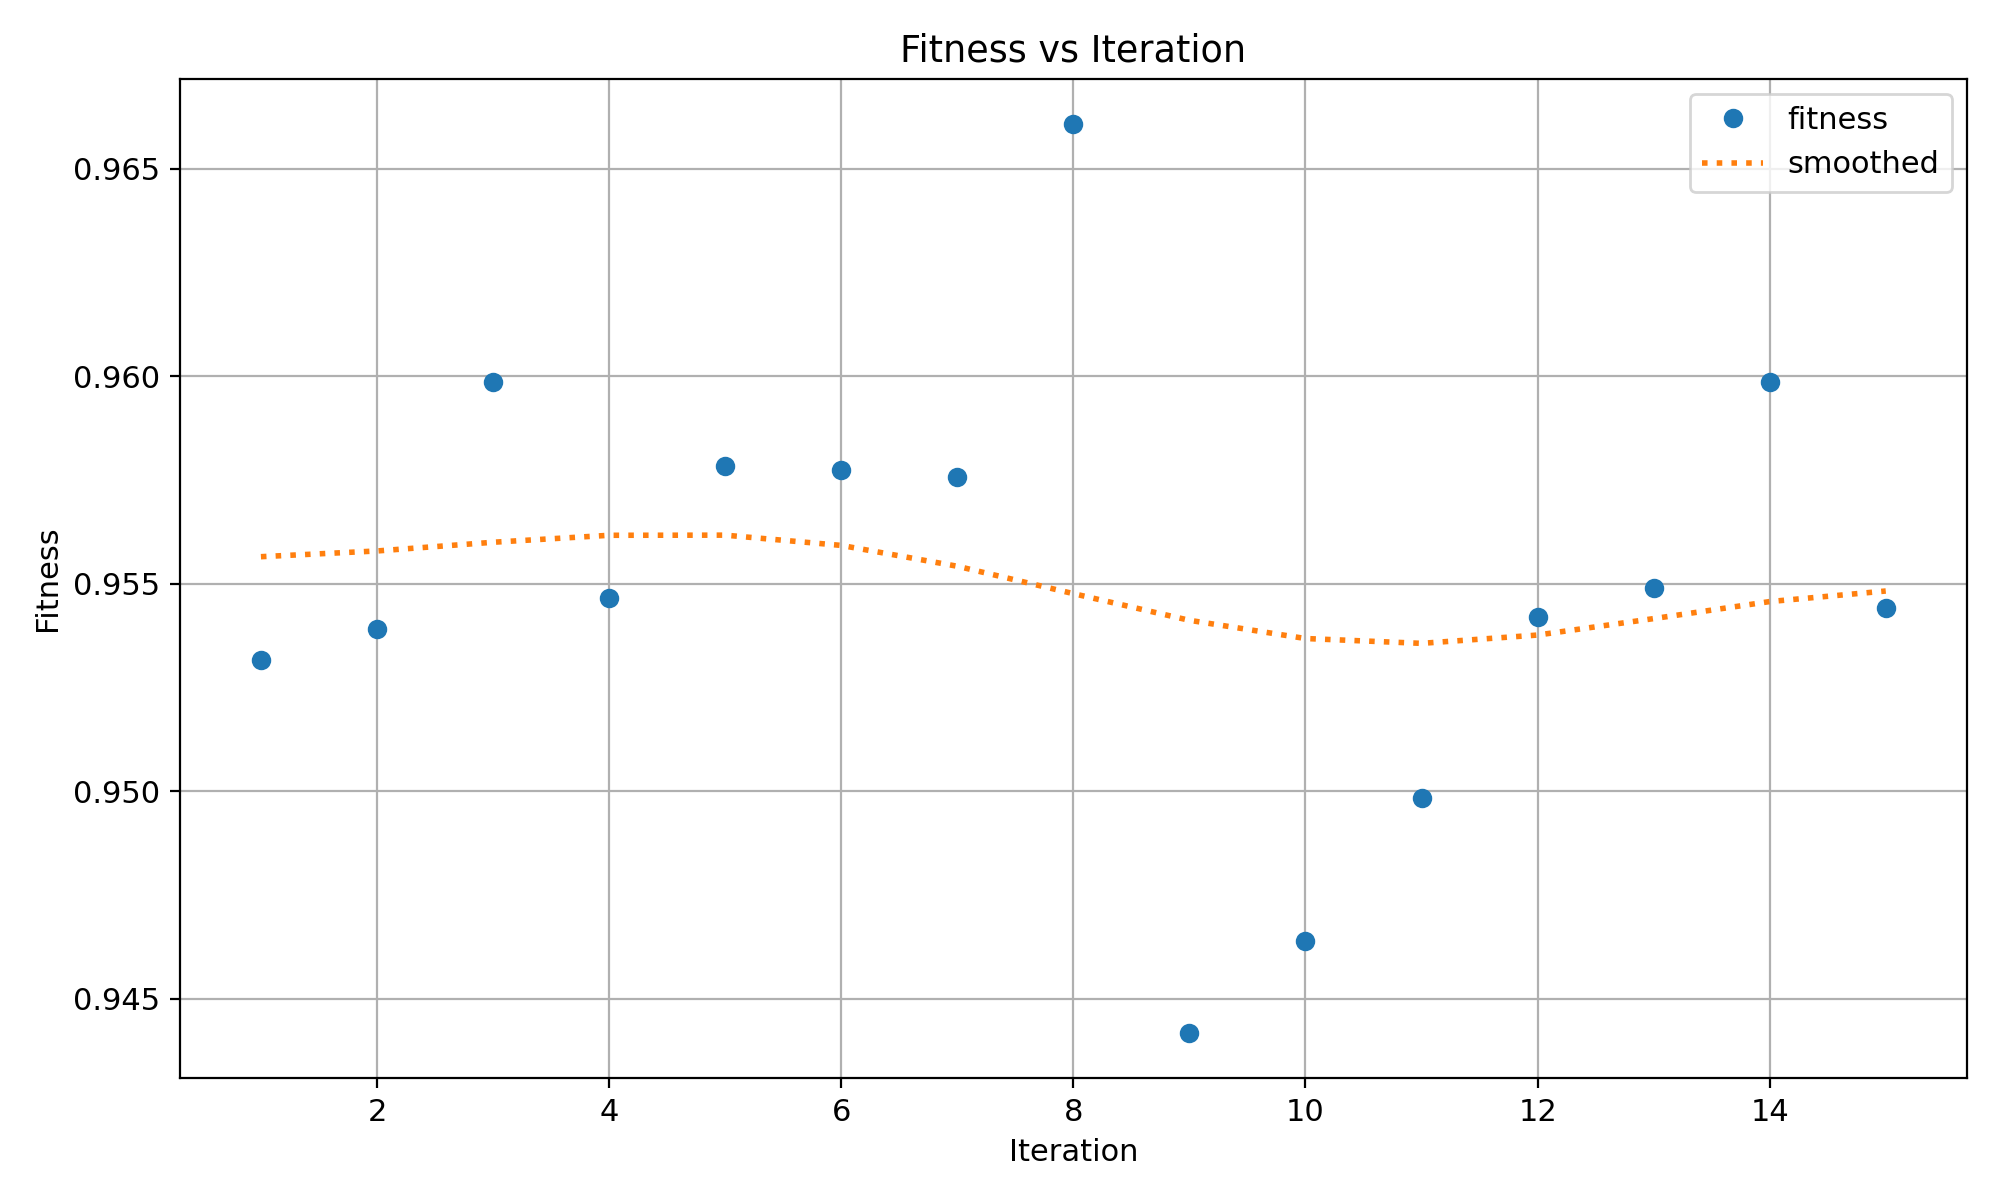

In [ ]:
display(Image('/content/runs/detect/tune/tune_fitness.png'))

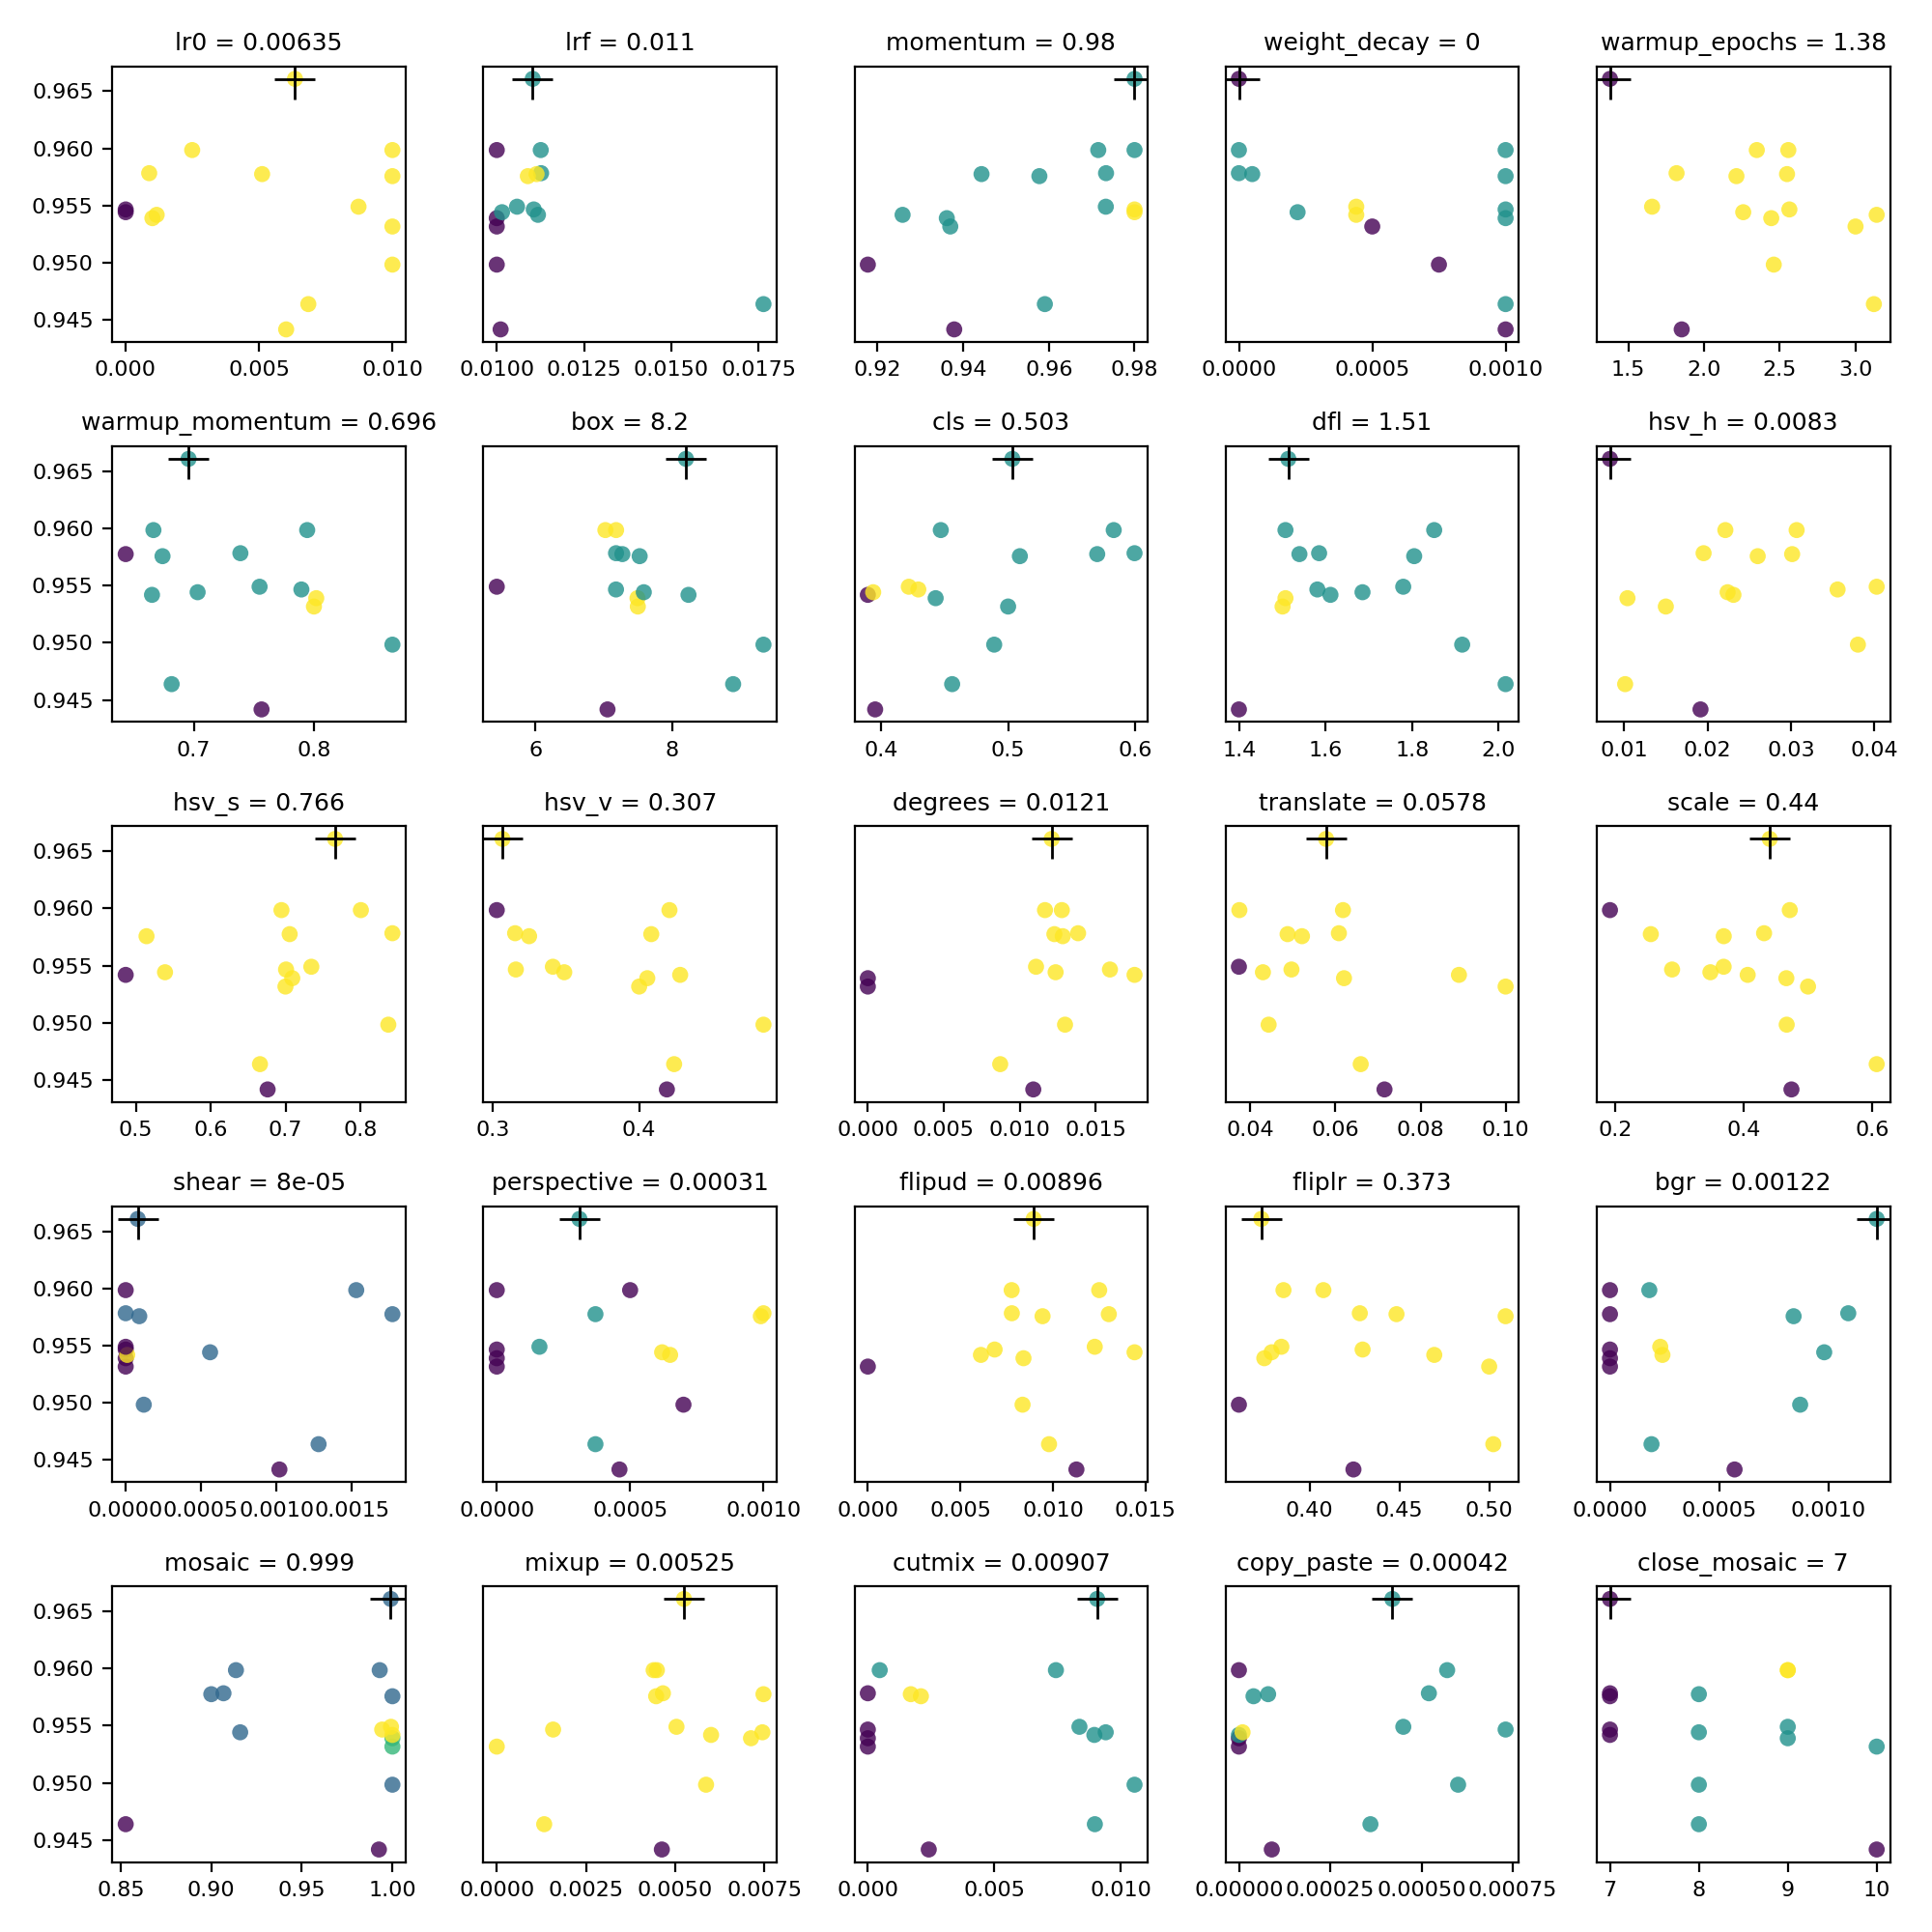

In [ ]:
display(Image('/content/runs/detect/tune/tune_scatter_plots.png'))

### **Batches: 16**

In [ ]:
model.tune(
    data='/content/Registradora_ahora_si-2/data.yaml',
    epochs=10,
    iterations=15,
    imgsz=640,
    optimizer='auto',
    batch=16
)

Tuner: Initialized Tuner instance with 'tune_dir=/content/runs/detect/tune'
Tuner: 💡 Learn about tuning at https://docs.ultralytics.com/guides/hyperparameter-tuning
Tuner: Starting iteration 1/15 with hyperparameters: {'lr0': 0.01, 'lrf': 0.01, 'momentum': 0.937, 'weight_decay': 0.0005, 'warmup_epochs': 3.0, 'warmup_momentum': 0.8, 'box': 7.5, 'cls': 0.5, 'dfl': 1.5, 'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4, 'degrees': 0.0, 'translate': 0.1, 'scale': 0.5, 'shear': 0.0, 'perspective': 0.0, 'flipud': 0.0, 'fliplr': 0.5, 'bgr': 0.0, 'mosaic': 1.0, 'mixup': 0.0, 'cutmix': 0.0, 'copy_paste': 0.0, 'close_mosaic': 10}
Saved /content/runs/detect/tune/tune_scatter_plots.png
Saved /content/runs/detect/tune/tune_fitness.png

Tuner: 1/15 iterations complete ✅ (255.60s)
Tuner: Results saved to /content/runs/detect/tune
Tuner: Best fitness=0.95718 observed at iteration 1
Tuner: Best fitness metrics are {'metrics/precision(B)': 0.96238, 'metrics/recall(B)': 0.9716, 'metrics/mAP50(B)': 0.98313, 'met

In [ ]:
auto_16 = pd.read_csv('/content/runs/detect/tune/tune_results.csv')
auto_16.sort_values(by='fitness', ascending=False).head(3)

,fitness,lr0,lrf,momentum,weight_decay,warmup_epochs,warmup_momentum,box,cls,dfl,...,shear,perspective,flipud,fliplr,bgr,mosaic,mixup,cutmix,copy_paste,close_mosaic
4,0.96621,0.01,0.01016,0.93036,0.00037,3.14386,0.94207,7.40635,0.38017,1.44490,...,0.00000,0.00046,0.00068,0.48707,0.00258,0.98415,0.00610,0.00275,0.00190,9
6,0.96282,0.01,0.01000,0.92837,0.00000,2.36098,0.76014,7.47411,0.49069,1.45745,...,0.00034,0.00031,0.00428,0.47077,0.00316,0.98512,0.00150,0.00000,0.00135,8
9,0.96272,0.01,0.01009,0.87783,0.00005,2.78823,0.50919,8.05563,0.53892,1.89121,...,0.00005,0.00000,0.00041,0.27584,0.00266,1.00000,0.00422,0.00312,0.00085,9


In [ ]:
ruta_yaml = '/content/runs/detect/tune/best_hyperparameters.yaml'

with open(ruta_yaml, "r") as file:
    contenido = file.read()

print(contenido)

# 15/15 iterations complete ✅ (3914.14s)
# Results saved to /content/runs/detect/tune
# Best fitness=0.96621 observed at iteration 5
# Best fitness metrics are {'metrics/precision(B)': 0.96243, 'metrics/recall(B)': 0.96611, 'metrics/mAP50(B)': 0.99108, 'metrics/mAP50-95(B)': 0.96621, 'val/box_loss': 0.26166, 'val/cls_loss': 0.1973, 'val/dfl_loss': 0.77591, 'fitness': 0.96621}
# Best fitness model is /content/runs/detect/train
lr0: 0.01
lrf: 0.01016
momentum: 0.93036
weight_decay: 0.00037
warmup_epochs: 3.14386
warmup_momentum: 0.94207
box: 7.40635
cls: 0.38017
dfl: 1.4449
hsv_h: 0.00888
hsv_s: 0.52042
hsv_v: 0.43848
degrees: 0.0
translate: 0.09008
scale: 0.37636
shear: 0.0
perspective: 0.00046
flipud: 0.00068
fliplr: 0.48707
bgr: 0.00258
mosaic: 0.98415
mixup: 0.0061
cutmix: 0.00275
copy_paste: 0.0019
close_mosaic: 9



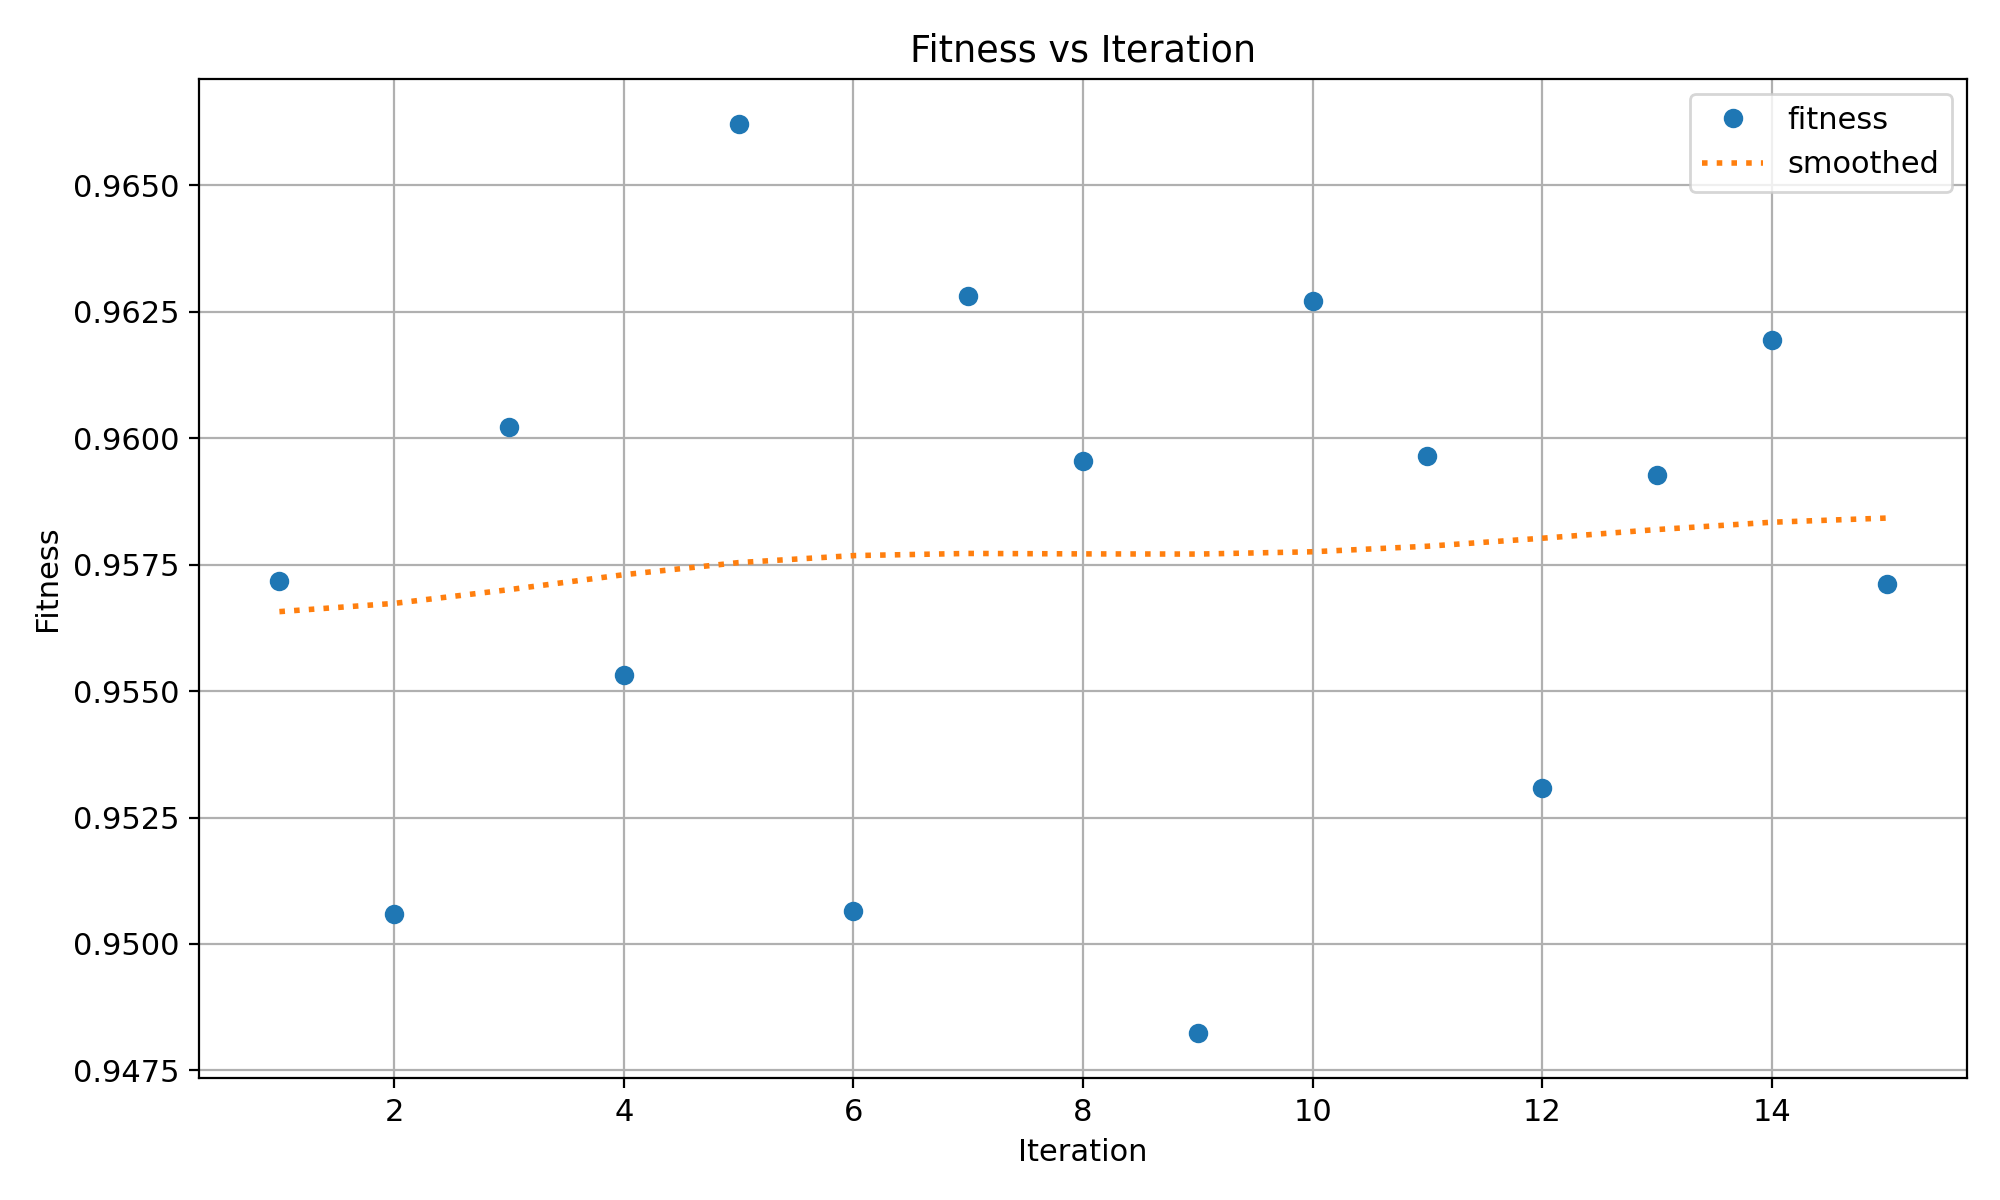

In [ ]:
display(Image('/content/runs/detect/tune/tune_fitness.png'))

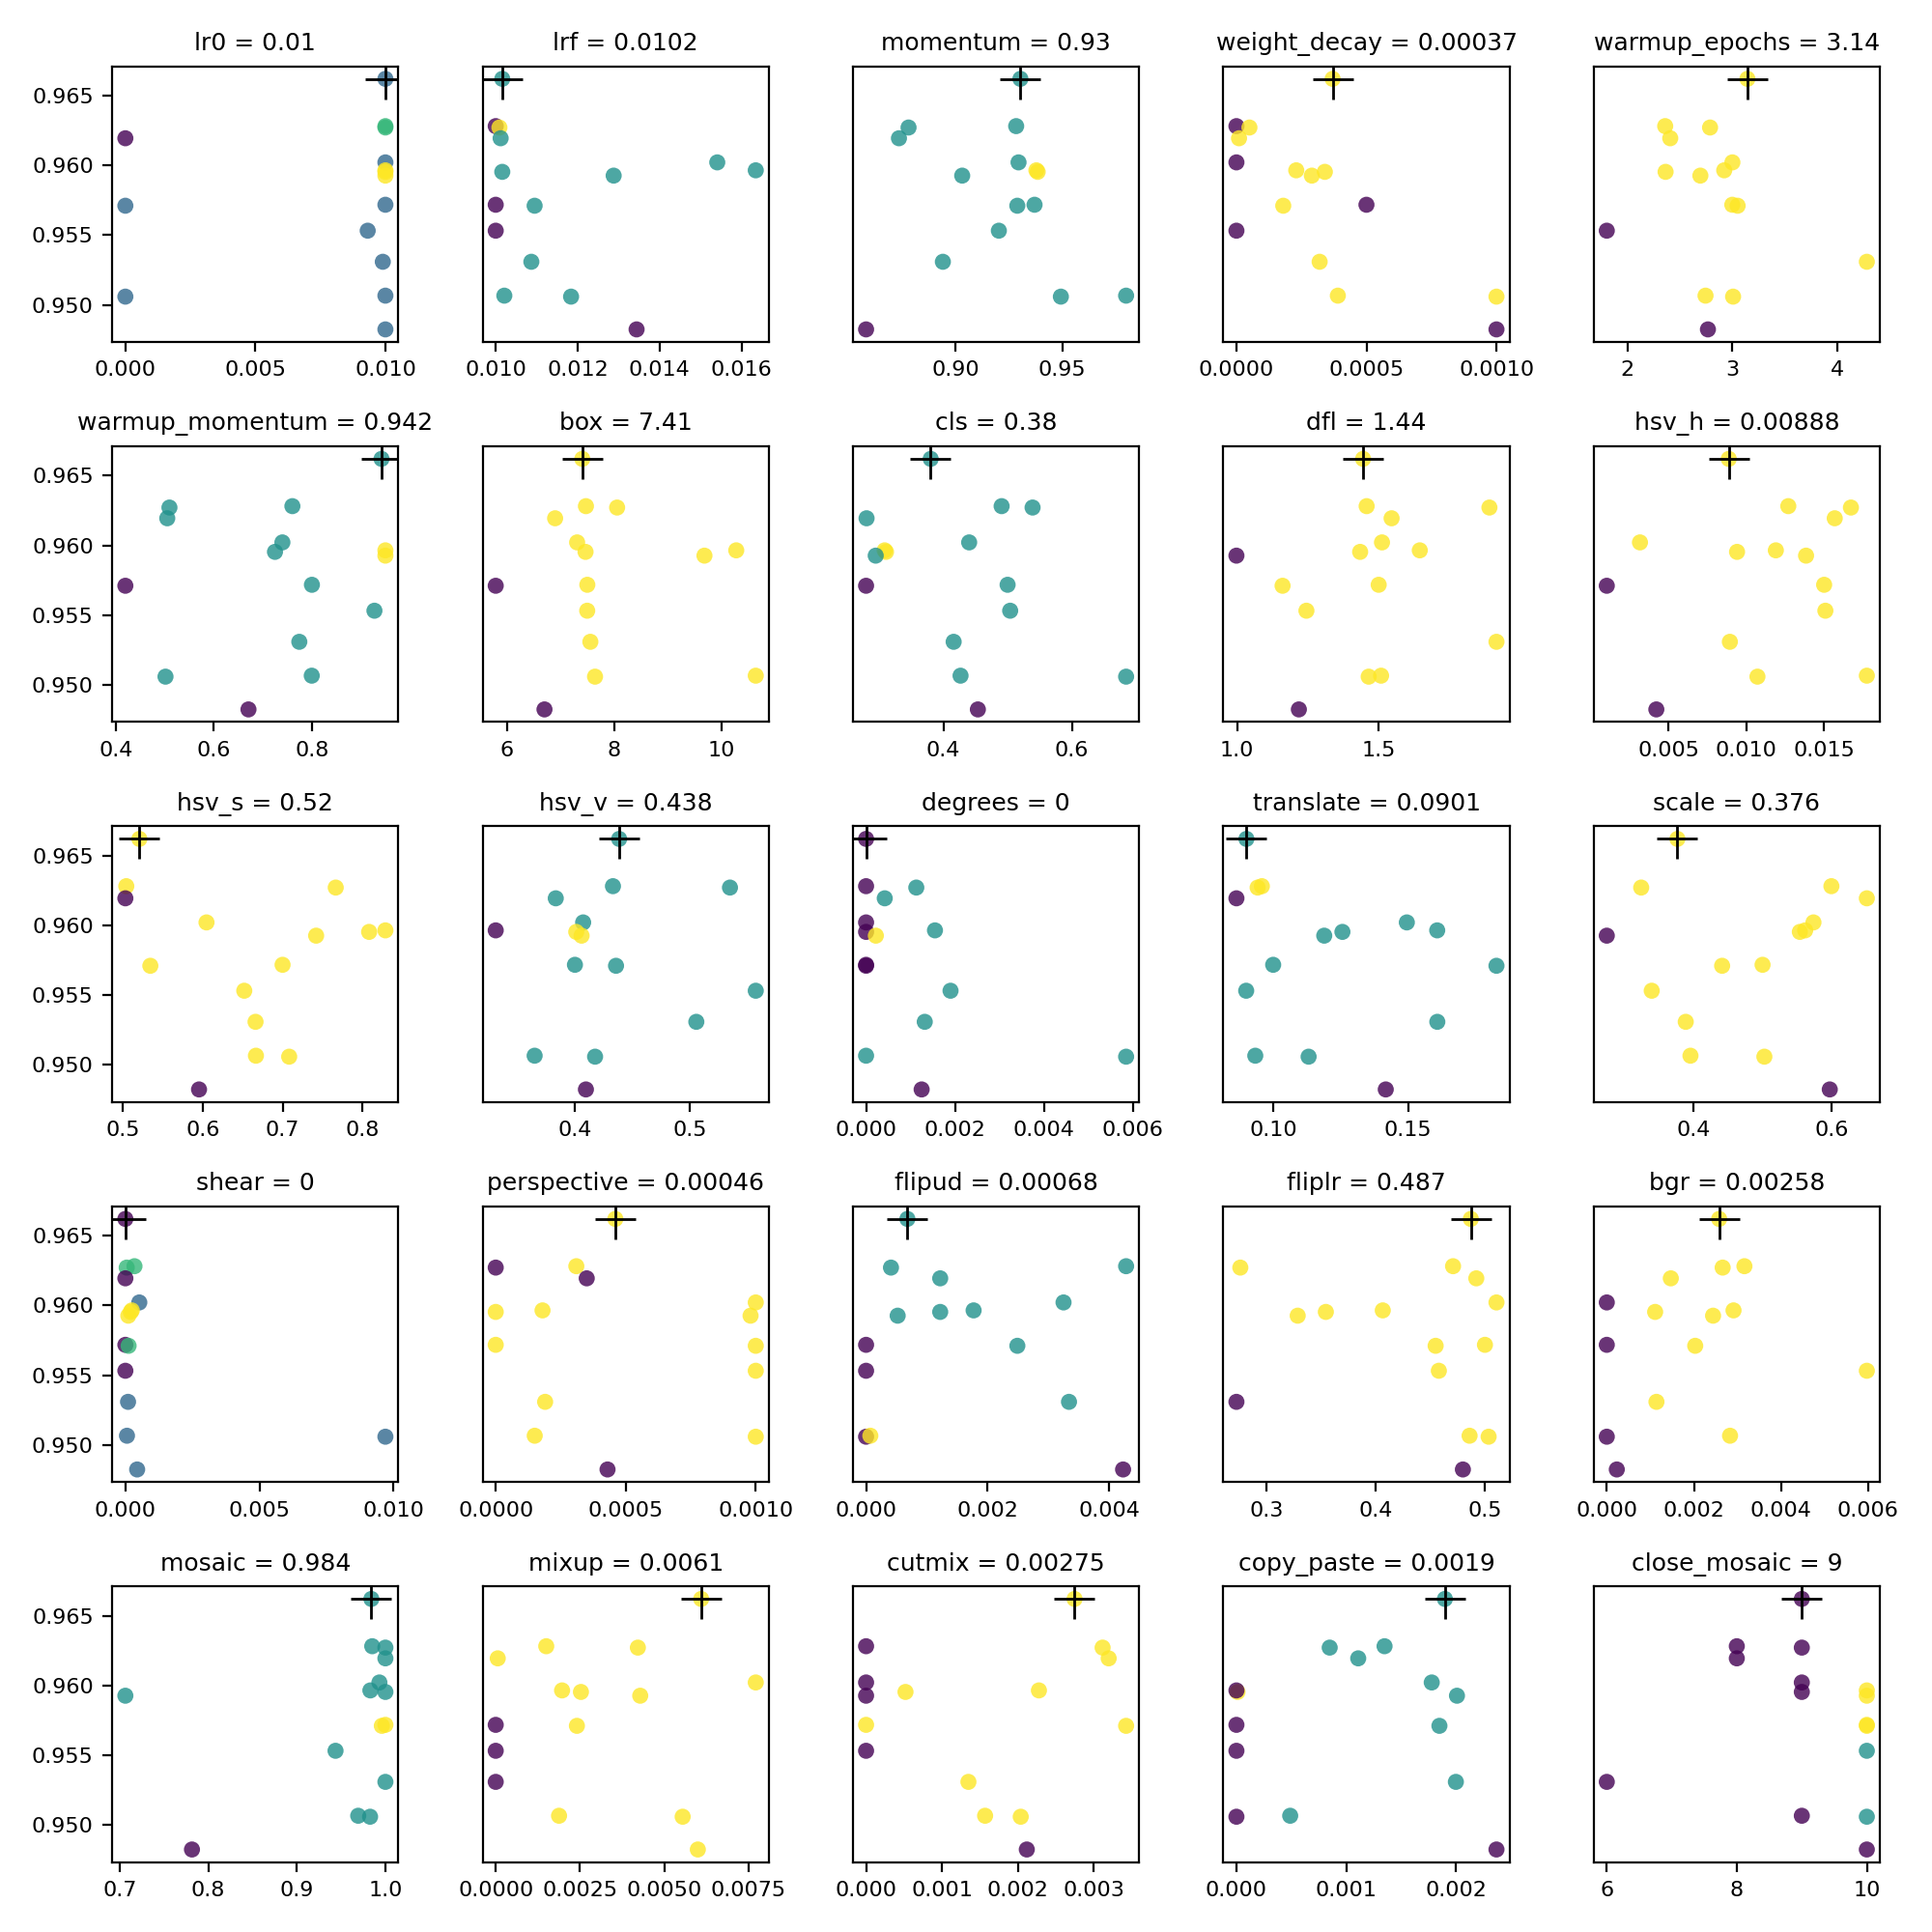

In [ ]:
display(Image('/content/runs/detect/tune/tune_scatter_plots.png'))

### **Batches: 32**

In [ ]:
model.tune(
    data='/content/Registradora_ahora_si-2/data.yaml',
    epochs=10,
    iterations=15,
    imgsz=640,
    optimizer='auto',
    batch=32
)

Tuner: Initialized Tuner instance with 'tune_dir=/content/runs/detect/tune'
Tuner: 💡 Learn about tuning at https://docs.ultralytics.com/guides/hyperparameter-tuning
Tuner: Starting iteration 1/15 with hyperparameters: {'lr0': 0.01, 'lrf': 0.01, 'momentum': 0.937, 'weight_decay': 0.0005, 'warmup_epochs': 3.0, 'warmup_momentum': 0.8, 'box': 7.5, 'cls': 0.5, 'dfl': 1.5, 'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4, 'degrees': 0.0, 'translate': 0.1, 'scale': 0.5, 'shear': 0.0, 'perspective': 0.0, 'flipud': 0.0, 'fliplr': 0.5, 'bgr': 0.0, 'mosaic': 1.0, 'mixup': 0.0, 'cutmix': 0.0, 'copy_paste': 0.0, 'close_mosaic': 10}
Saved /content/runs/detect/tune/tune_scatter_plots.png
Saved /content/runs/detect/tune/tune_fitness.png

Tuner: 1/15 iterations complete ✅ (250.14s)
Tuner: Results saved to /content/runs/detect/tune
Tuner: Best fitness=0.95186 observed at iteration 1
Tuner: Best fitness metrics are {'metrics/precision(B)': 0.95658, 'metrics/recall(B)': 0.98354, 'metrics/mAP50(B)': 0.98074, 'me

In [ ]:
auto_32 = pd.read_csv('/content/runs/detect/tune/tune_results.csv')
auto_32.sort_values(by='fitness', ascending=False).head(3)

,fitness,lr0,lrf,momentum,weight_decay,warmup_epochs,warmup_momentum,box,cls,dfl,...,shear,perspective,flipud,fliplr,bgr,mosaic,mixup,cutmix,copy_paste,close_mosaic
4,0.96153,0.01000,0.01018,0.93320,0.00000,3.81452,0.95000,10.24344,0.59724,1.32124,...,0.00058,0.00100,0.00037,0.50500,0.00079,0.99988,0.00981,0.00319,0.01238,10
14,0.95721,0.00659,0.01413,0.94469,0.00100,4.16228,0.92234,9.62529,0.58859,1.32665,...,0.00004,0.00091,0.00029,0.59342,0.00362,0.87548,0.00753,0.00658,0.01592,10
8,0.95710,0.01000,0.01257,0.93943,0.00027,3.65308,0.68740,9.70113,0.49490,1.15839,...,0.00008,0.00055,0.00014,0.45127,0.00153,0.97245,0.00196,0.00667,0.01104,9


In [ ]:
ruta_yaml = '/content/runs/detect/tune/best_hyperparameters.yaml'

with open(ruta_yaml, "r") as file:
    contenido = file.read()

print(contenido)

# 15/15 iterations complete ✅ (3868.50s)
# Results saved to /content/runs/detect/tune
# Best fitness=0.96153 observed at iteration 5
# Best fitness metrics are {'metrics/precision(B)': 0.95554, 'metrics/recall(B)': 0.97827, 'metrics/mAP50(B)': 0.98517, 'metrics/mAP50-95(B)': 0.96153, 'val/box_loss': 0.36713, 'val/cls_loss': 0.31725, 'val/dfl_loss': 0.71251, 'fitness': 0.96153}
# Best fitness model is /content/runs/detect/train3
lr0: 0.01
lrf: 0.01018
momentum: 0.9332
weight_decay: 0.0
warmup_epochs: 3.81452
warmup_momentum: 0.95
box: 10.24344
cls: 0.59724
dfl: 1.32124
hsv_h: 0.00289
hsv_s: 0.82354
hsv_v: 0.4318
degrees: 0.01244
translate: 0.13266
scale: 0.5499
shear: 0.00058
perspective: 0.001
flipud: 0.00037
fliplr: 0.505
bgr: 0.00079
mosaic: 0.99988
mixup: 0.00981
cutmix: 0.00319
copy_paste: 0.01238
close_mosaic: 10



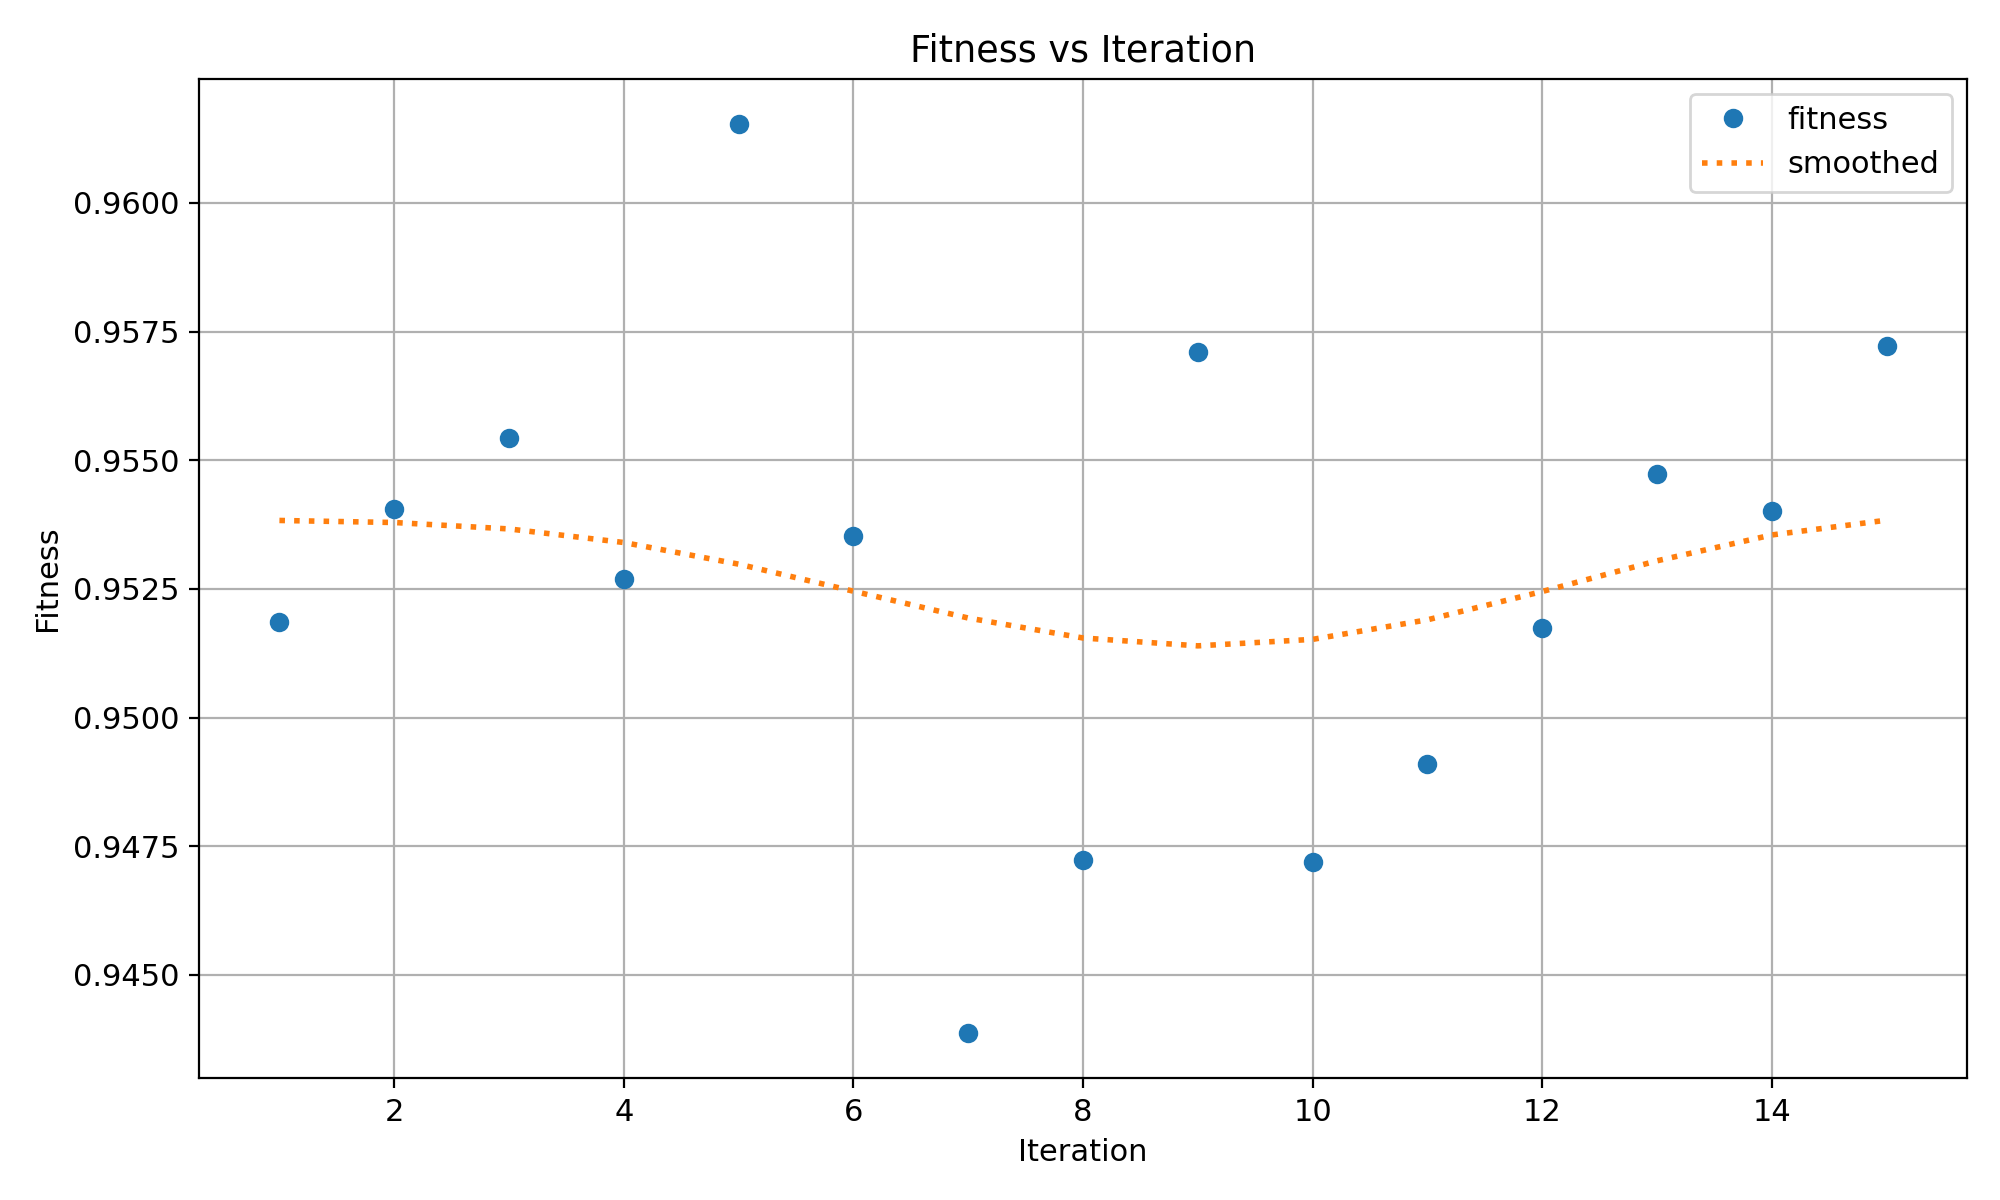

In [ ]:
display(Image('/content/runs/detect/tune/tune_fitness.png'))

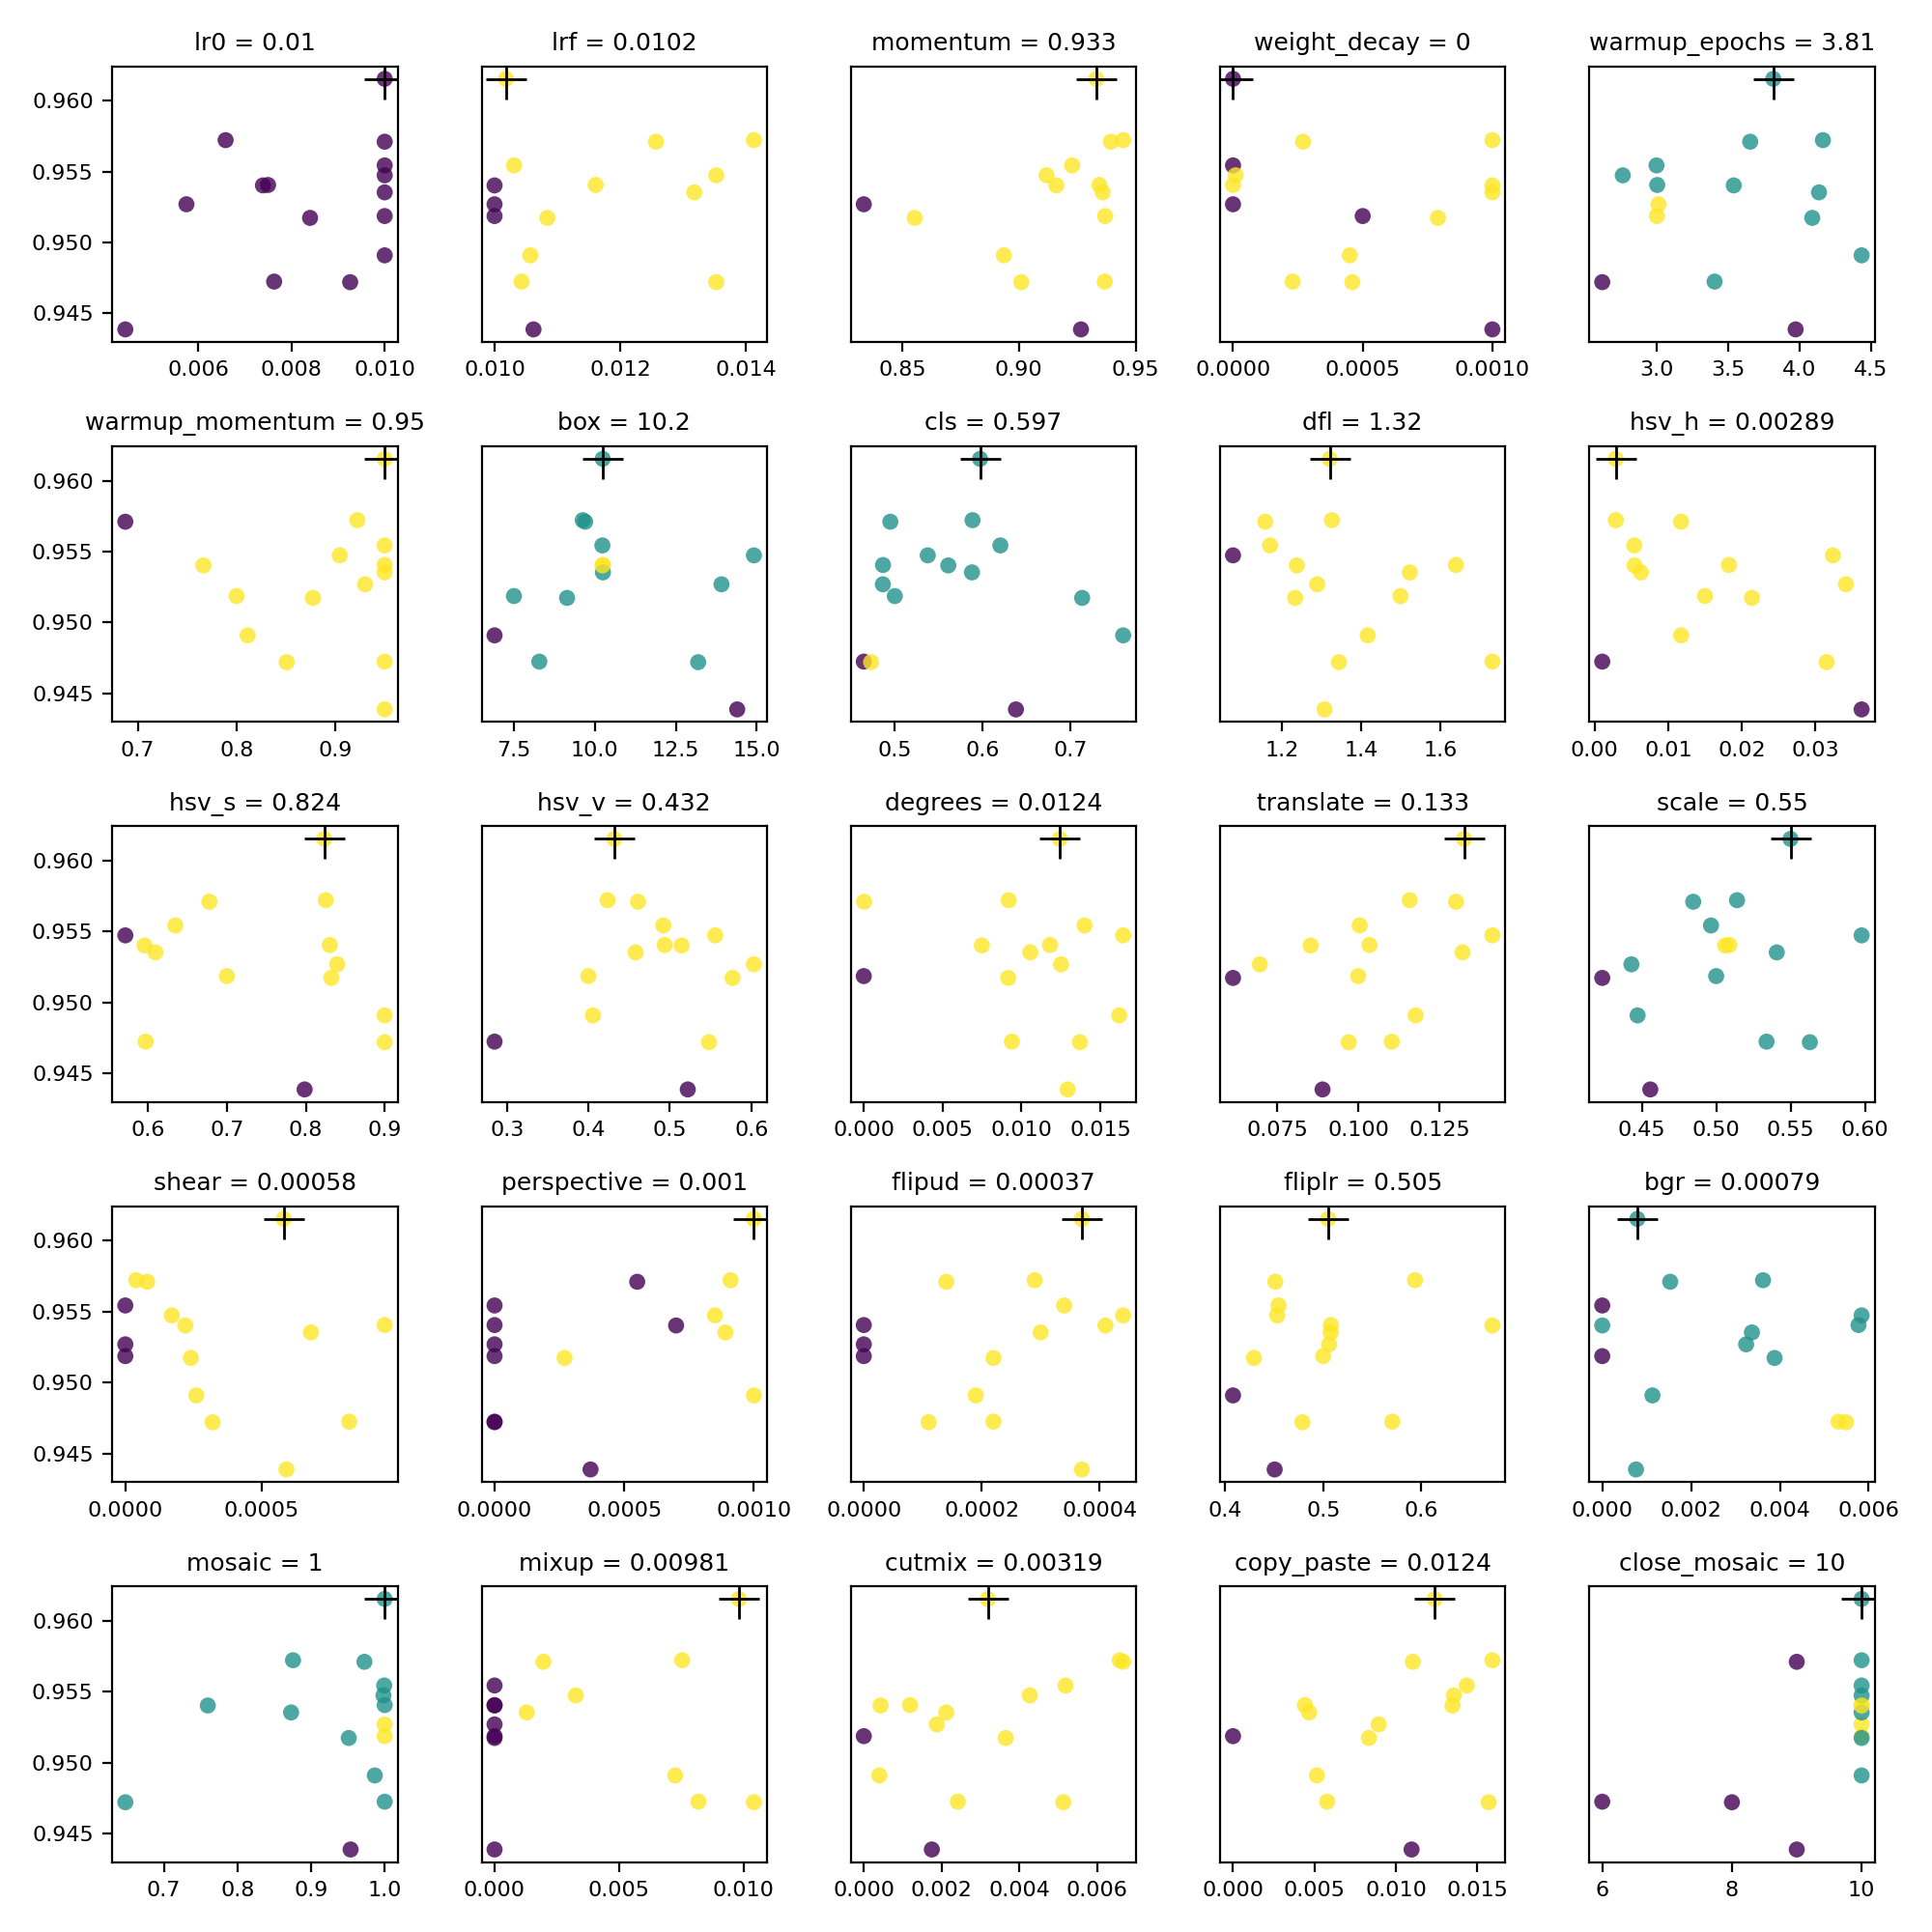

In [ ]:
display(Image('/content/runs/detect/tune/tune_scatter_plots.png'))

## **Optimizer: MuSGD**

In [ ]:
model.tune(
    data='/content/Registradora_ahora_si-2/data.yaml',
    epochs=10,
    iterations=15,
    imgsz=640,
    optimizer='MuSGD',
    batch=16
)

Tuner: Initialized Tuner instance with 'tune_dir=/content/runs/detect/tune'
Tuner: 💡 Learn about tuning at https://docs.ultralytics.com/guides/hyperparameter-tuning
Tuner: Starting iteration 1/15 with hyperparameters: {'lr0': 0.01, 'lrf': 0.01, 'momentum': 0.937, 'weight_decay': 0.0005, 'warmup_epochs': 3.0, 'warmup_momentum': 0.8, 'box': 7.5, 'cls': 0.5, 'dfl': 1.5, 'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4, 'degrees': 0.0, 'translate': 0.1, 'scale': 0.5, 'shear': 0.0, 'perspective': 0.0, 'flipud': 0.0, 'fliplr': 0.5, 'bgr': 0.0, 'mosaic': 1.0, 'mixup': 0.0, 'cutmix': 0.0, 'copy_paste': 0.0, 'close_mosaic': 10}
Saved /content/runs/detect/tune/tune_scatter_plots.png
Saved /content/runs/detect/tune/tune_fitness.png

Tuner: 1/15 iterations complete ✅ (290.46s)
Tuner: Results saved to /content/runs/detect/tune
Tuner: Best fitness=0.94748 observed at iteration 1
Tuner: Best fitness metrics are {'metrics/precision(B)': 0.95718, 'metrics/recall(B)': 0.96464, 'metrics/mAP50(B)': 0.98618, 'me

In [ ]:
musgd = pd.read_csv('/content/runs/detect/tune/tune_results.csv')
musgd.sort_values(by='fitness', ascending=False).head(3)

,fitness,lr0,lrf,momentum,weight_decay,warmup_epochs,warmup_momentum,box,cls,dfl,...,shear,perspective,flipud,fliplr,bgr,mosaic,mixup,cutmix,copy_paste,close_mosaic
14,0.96056,0.00419,0.01000,0.90172,0.00046,2.94273,0.47578,9.29242,0.65439,1.45246,...,0.00242,0.00100,0.00157,0.43735,0.00000,1.00000,0.00087,0.00062,0.00464,9
13,0.95920,0.00167,0.01934,0.91989,0.00096,2.80949,0.63433,6.64285,0.49140,1.37810,...,0.00512,0.00023,0.00031,0.56935,0.00135,1.00000,0.00337,0.00000,0.00452,7
2,0.95810,0.00187,0.01000,0.98000,0.00100,3.00521,0.60233,7.50175,0.44835,1.49476,...,0.00000,0.00000,0.00000,0.51331,0.00000,0.99756,0.00494,0.00000,0.00613,10


In [ ]:
ruta_yaml = '/content/runs/detect/tune/best_hyperparameters.yaml'

with open(ruta_yaml, "r") as file:
    contenido = file.read()

print(contenido)

# 15/15 iterations complete ✅ (4348.24s)
# Results saved to /content/runs/detect/tune
# Best fitness=0.96056 observed at iteration 15
# Best fitness metrics are {'metrics/precision(B)': 0.94558, 'metrics/recall(B)': 0.97976, 'metrics/mAP50(B)': 0.98892, 'metrics/mAP50-95(B)': 0.96056, 'val/box_loss': 0.33095, 'val/cls_loss': 0.35591, 'val/dfl_loss': 0.78328, 'fitness': 0.96056}
# Best fitness model is /content/runs/detect/train4
lr0: 0.00419
lrf: 0.01
momentum: 0.90172
weight_decay: 0.00046
warmup_epochs: 2.94273
warmup_momentum: 0.47578
box: 9.29242
cls: 0.65439
dfl: 1.45246
hsv_h: 0.00401
hsv_s: 0.9
hsv_v: 0.27615
degrees: 0.0
translate: 0.05952
scale: 0.58006
shear: 0.00242
perspective: 0.001
flipud: 0.00157
fliplr: 0.43735
bgr: 0.0
mosaic: 1.0
mixup: 0.00087
cutmix: 0.00062
copy_paste: 0.00464
close_mosaic: 9



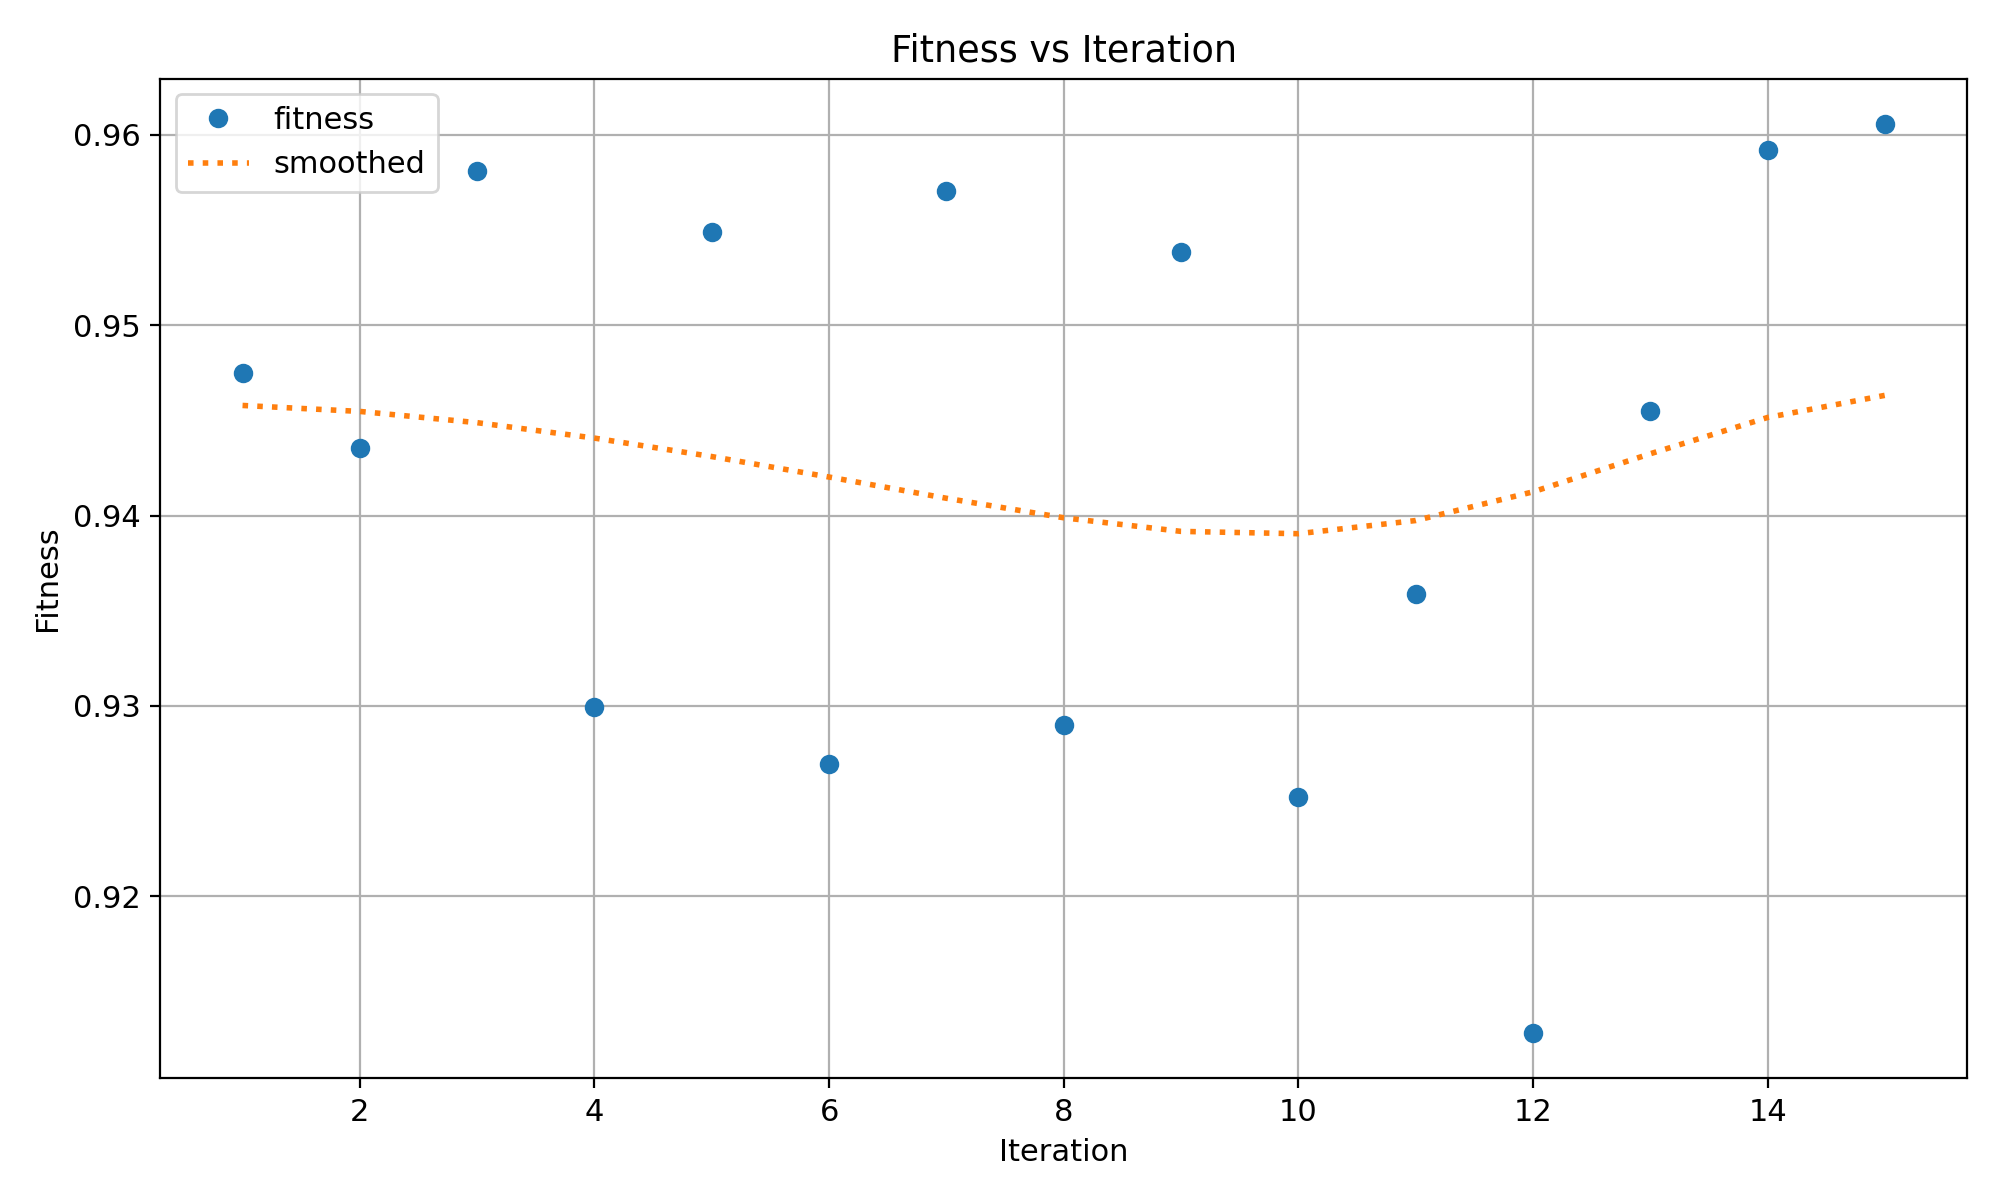

In [ ]:
display(Image('/content/runs/detect/tune/tune_fitness.png'))

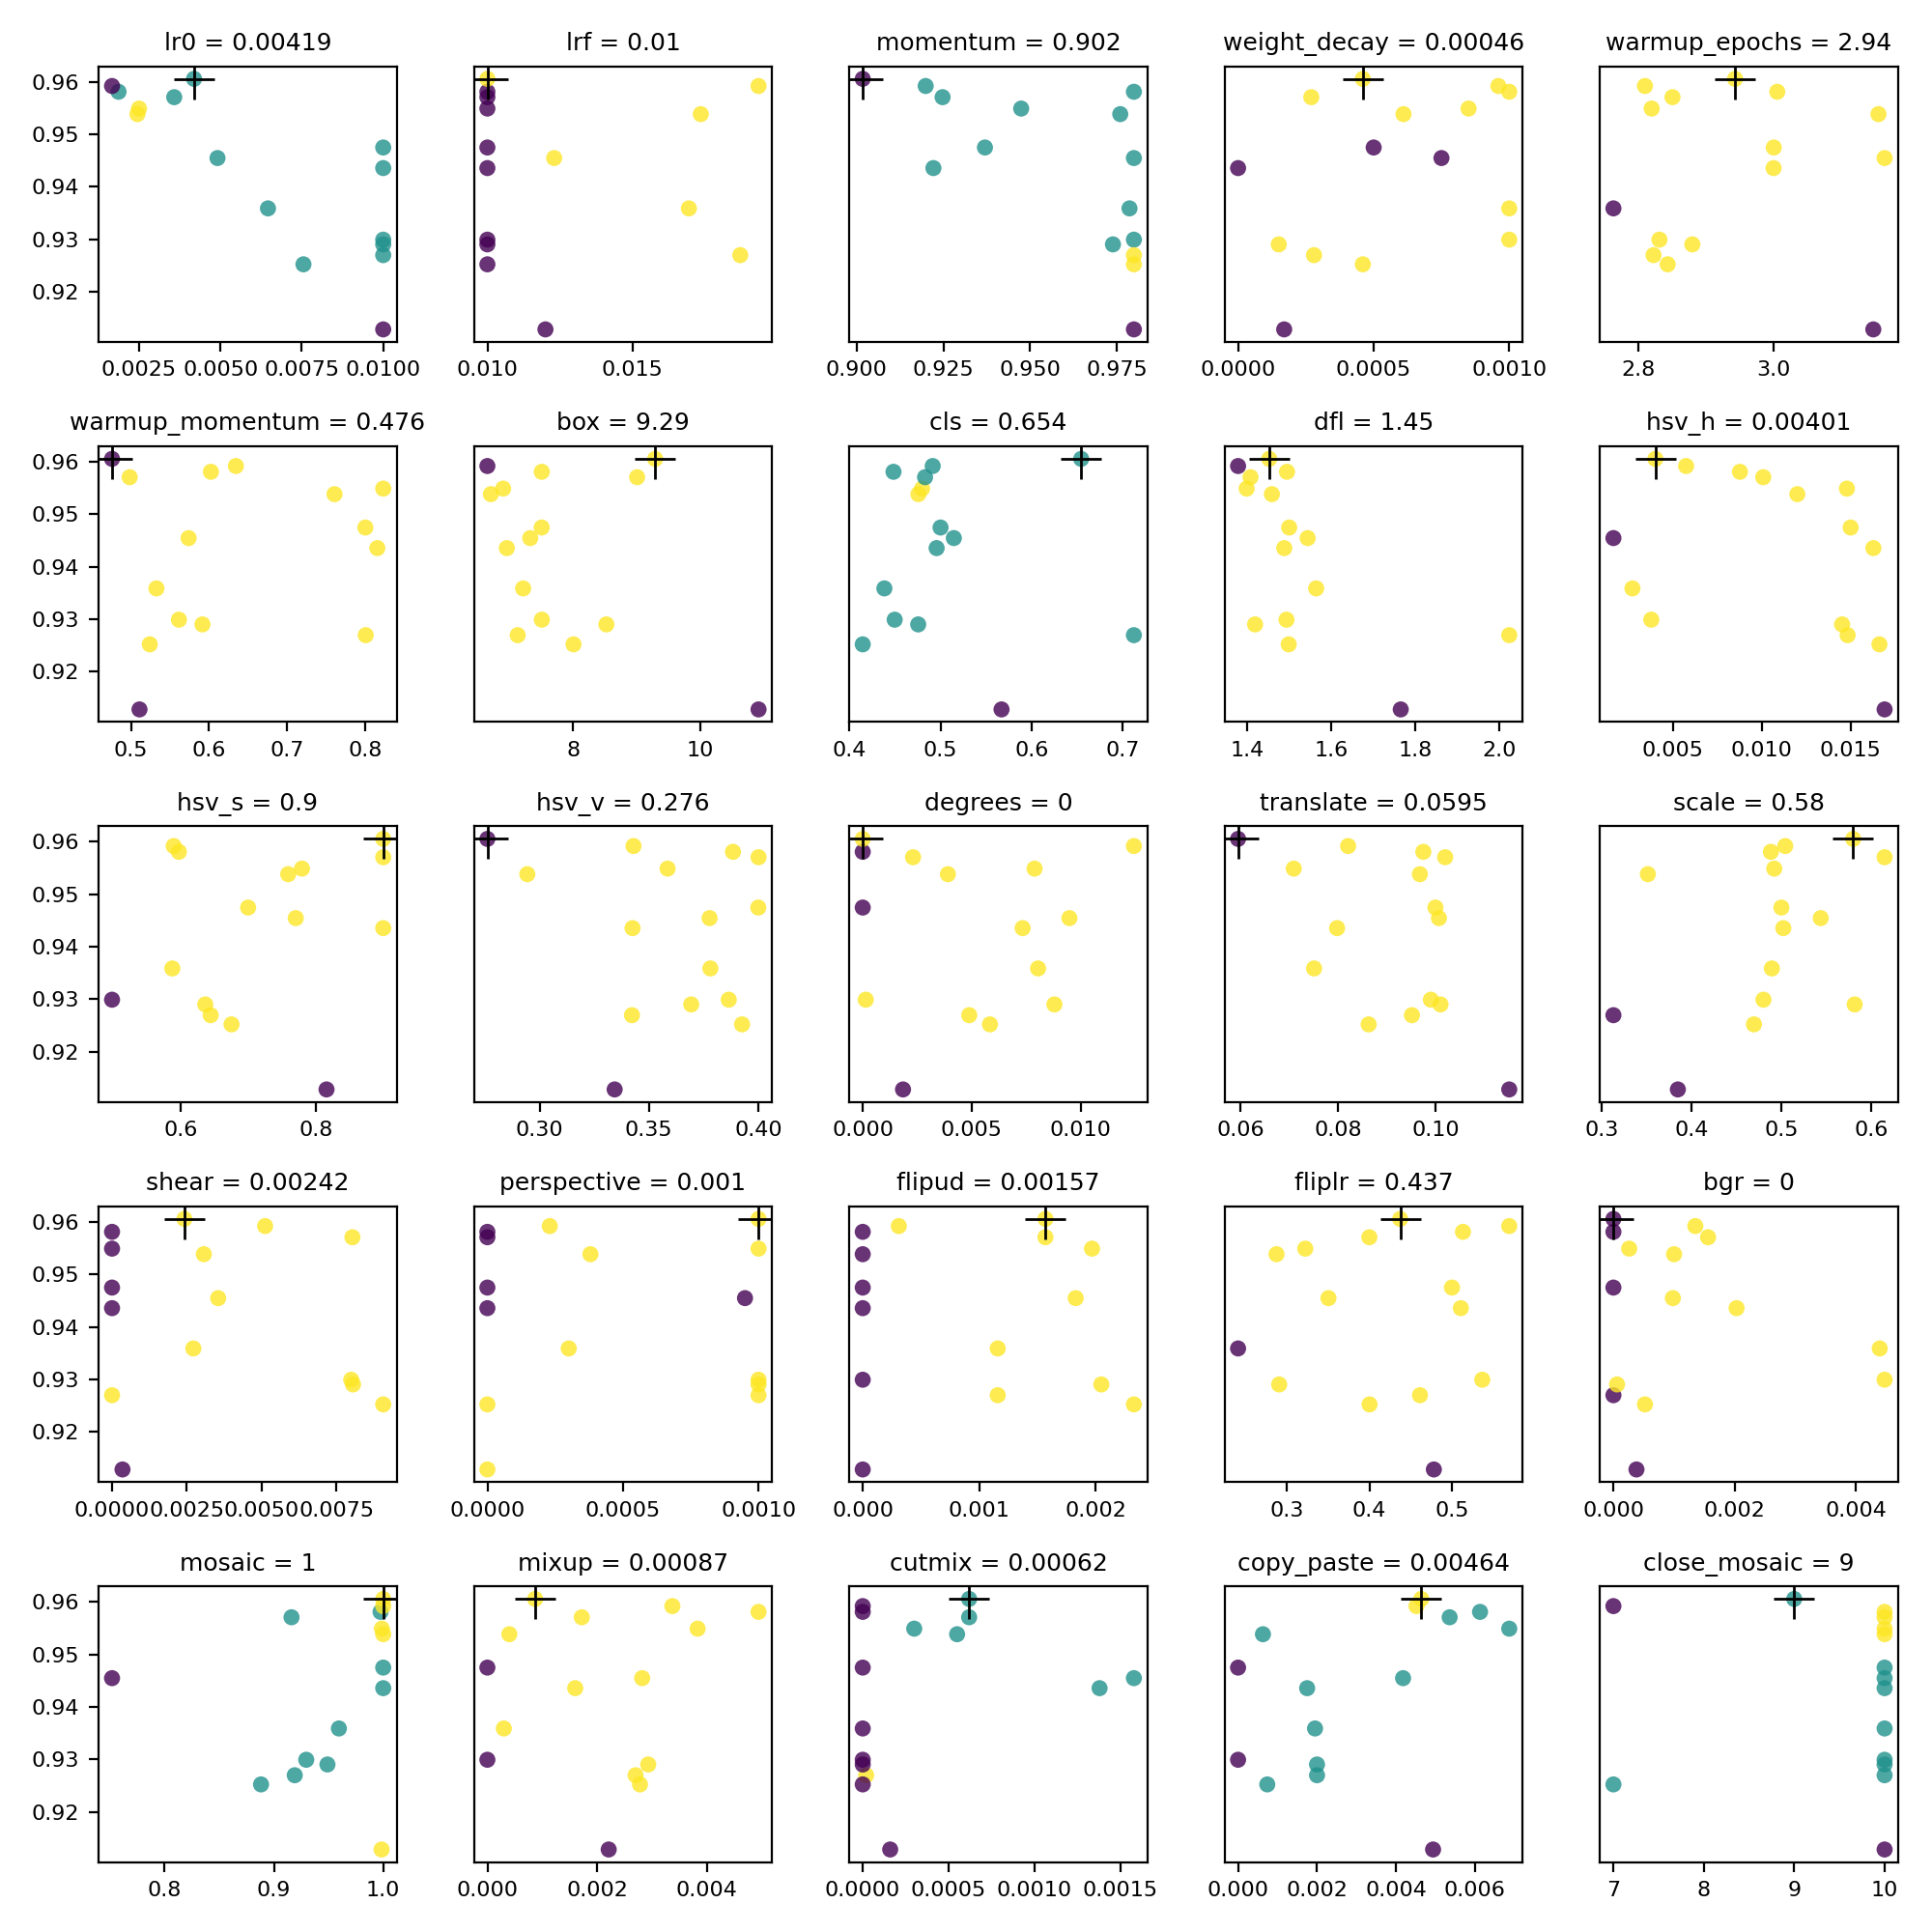

In [ ]:
display(Image('/content/runs/detect/tune/tune_scatter_plots.png'))

## **Optimizer: AdamW**

In [ ]:
model.tune(
    data='/content/Registradora_ahora_si-2/data.yaml',
    epochs=10,
    iterations=15,
    imgsz=640,
    optimizer='AdamW',
    batch=16
)

Tuner: Initialized Tuner instance with 'tune_dir=/content/runs/detect/tune'
Tuner: 💡 Learn about tuning at https://docs.ultralytics.com/guides/hyperparameter-tuning
Tuner: Starting iteration 1/15 with hyperparameters: {'lr0': 0.01, 'lrf': 0.01, 'momentum': 0.937, 'weight_decay': 0.0005, 'warmup_epochs': 3.0, 'warmup_momentum': 0.8, 'box': 7.5, 'cls': 0.5, 'dfl': 1.5, 'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4, 'degrees': 0.0, 'translate': 0.1, 'scale': 0.5, 'shear': 0.0, 'perspective': 0.0, 'flipud': 0.0, 'fliplr': 0.5, 'bgr': 0.0, 'mosaic': 1.0, 'mixup': 0.0, 'cutmix': 0.0, 'copy_paste': 0.0, 'close_mosaic': 10}
Saved /content/runs/detect/tune/tune_scatter_plots.png
Saved /content/runs/detect/tune/tune_fitness.png

Tuner: 1/15 iterations complete ✅ (269.55s)
Tuner: Results saved to /content/runs/detect/tune
Tuner: Best fitness=0.5672 observed at iteration 1
Tuner: Best fitness metrics are {'metrics/precision(B)': 0.59033, 'metrics/recall(B)': 0.62494, 'metrics/mAP50(B)': 0.62959, 'met

In [ ]:
adamw = pd.read_csv('/content/runs/detect/tune/tune_results.csv')
adamw.sort_values(by='fitness', ascending=False).head(3)

,fitness,lr0,lrf,momentum,weight_decay,warmup_epochs,warmup_momentum,box,cls,dfl,...,shear,perspective,flipud,fliplr,bgr,mosaic,mixup,cutmix,copy_paste,close_mosaic
2,0.94607,0.00015,0.01000,0.94155,0.00000,2.99751,0.79793,8.68252,0.62940,1.70520,...,0.00605,0.00000,0.00000,0.70038,0.00180,0.97717,0.00512,0.01474,0.01321,10
12,0.92980,0.00182,0.01588,0.88443,0.00020,2.97642,0.68826,6.54601,0.62110,1.44274,...,0.00250,0.00000,0.00605,0.72173,0.00136,0.89331,0.00492,0.00314,0.02491,9
13,0.87374,0.00358,0.01846,0.86408,0.00021,3.94487,0.95000,8.06596,0.63336,1.30359,...,0.00391,0.00084,0.00945,0.63723,0.00122,0.91250,0.00368,0.00642,0.01453,8


In [ ]:
ruta_yaml = '/content/runs/detect/tune/best_hyperparameters.yaml'

with open(ruta_yaml, "r") as file:
    contenido = file.read()

print(contenido)

# 15/15 iterations complete ✅ (4155.86s)
# Results saved to /content/runs/detect/tune
# Best fitness=0.94607 observed at iteration 3
# Best fitness metrics are {'metrics/precision(B)': 0.94625, 'metrics/recall(B)': 0.97965, 'metrics/mAP50(B)': 0.97464, 'metrics/mAP50-95(B)': 0.94607, 'val/box_loss': 0.3205, 'val/cls_loss': 0.3835, 'val/dfl_loss': 0.92799, 'fitness': 0.94607}
# Best fitness model is /content/runs/detect/train
lr0: 0.00015
lrf: 0.01
momentum: 0.94155
weight_decay: 0.0
warmup_epochs: 2.99751
warmup_momentum: 0.79793
box: 8.68252
cls: 0.6294
dfl: 1.7052
hsv_h: 0.01316
hsv_s: 0.63189
hsv_v: 0.39675
degrees: 0.0
translate: 0.08983
scale: 0.47557
shear: 0.00605
perspective: 0.0
flipud: 0.0
fliplr: 0.70038
bgr: 0.0018
mosaic: 0.97717
mixup: 0.00512
cutmix: 0.01474
copy_paste: 0.01321
close_mosaic: 10



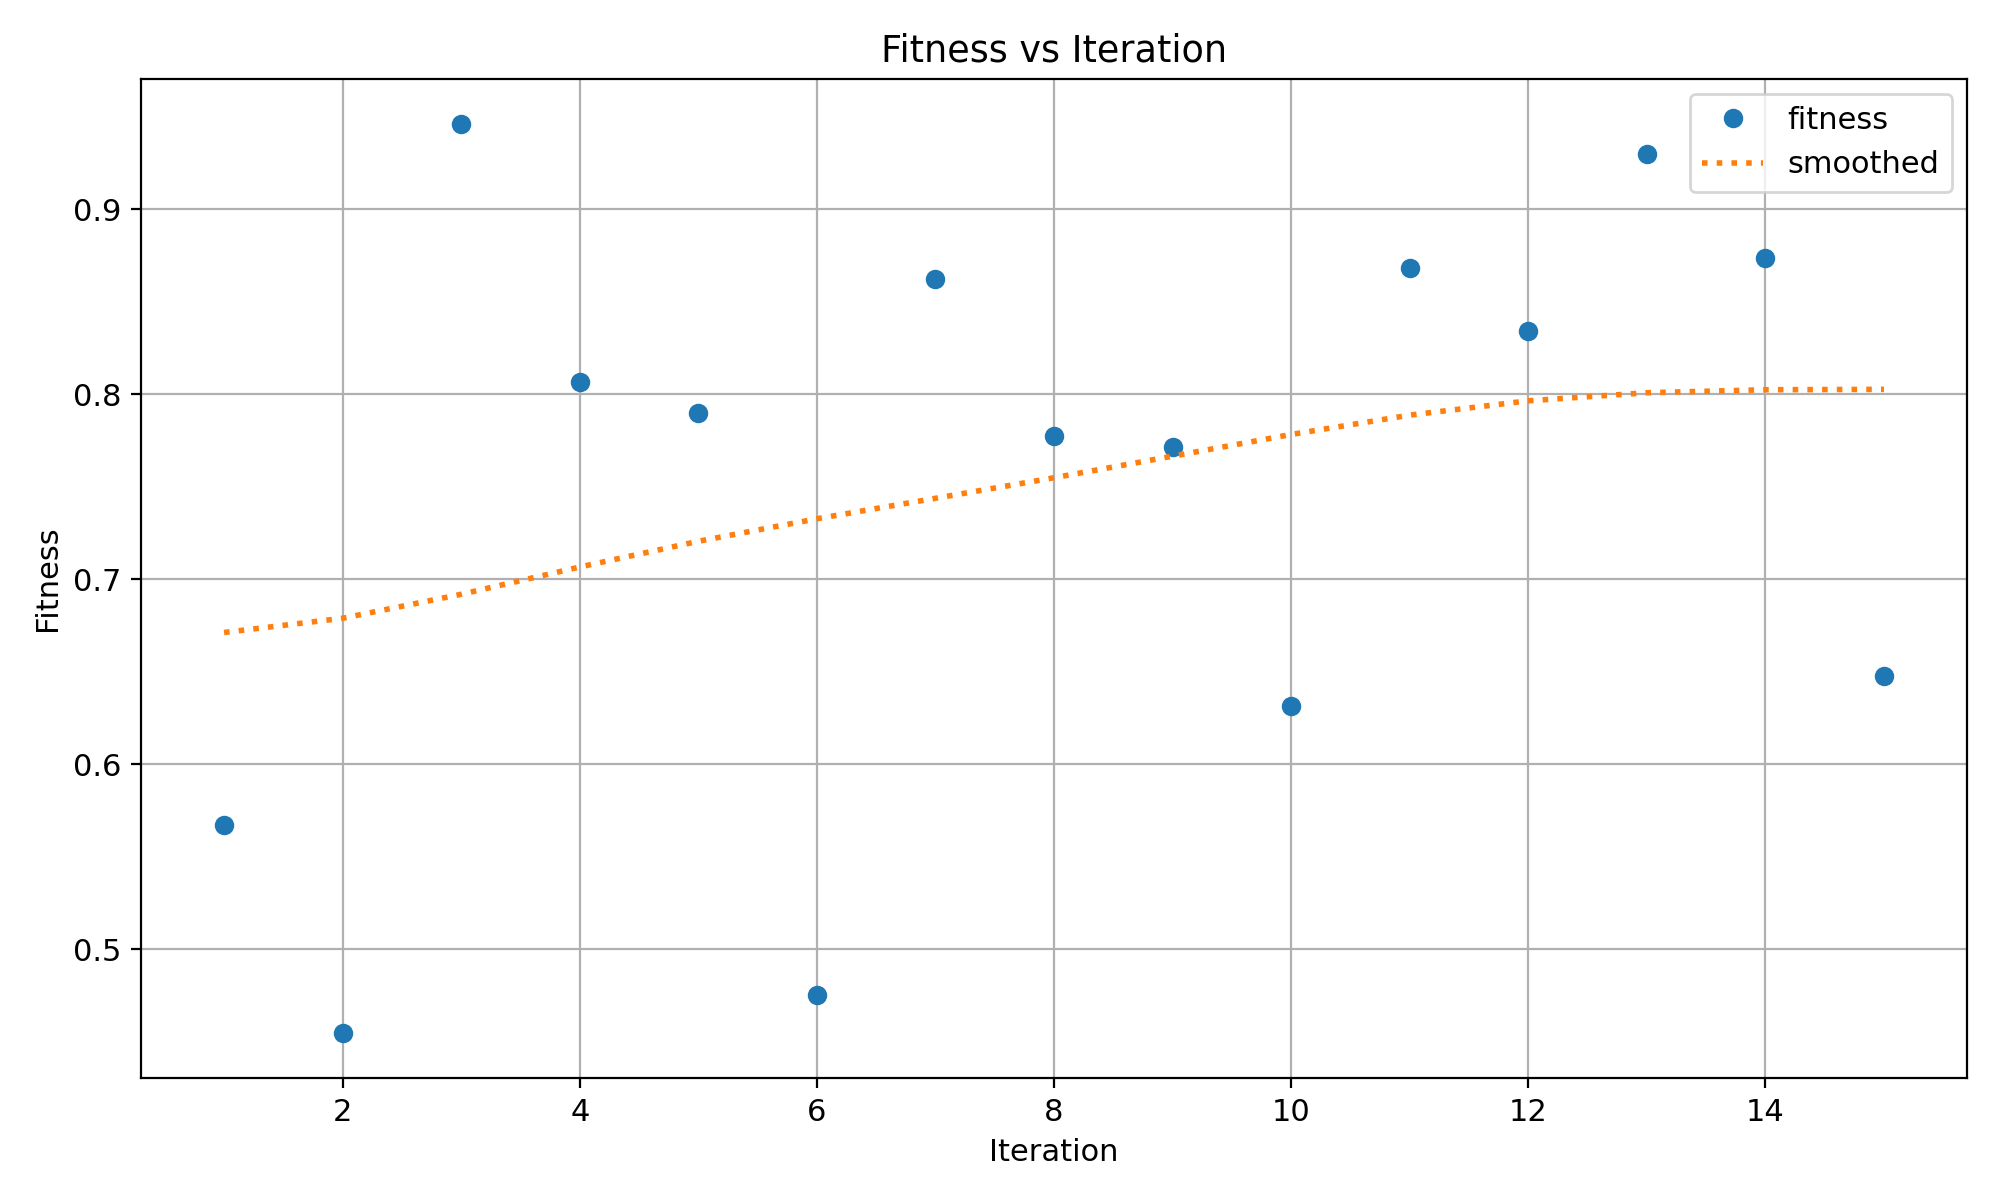

In [ ]:
display(Image('/content/runs/detect/tune/tune_fitness.png'))

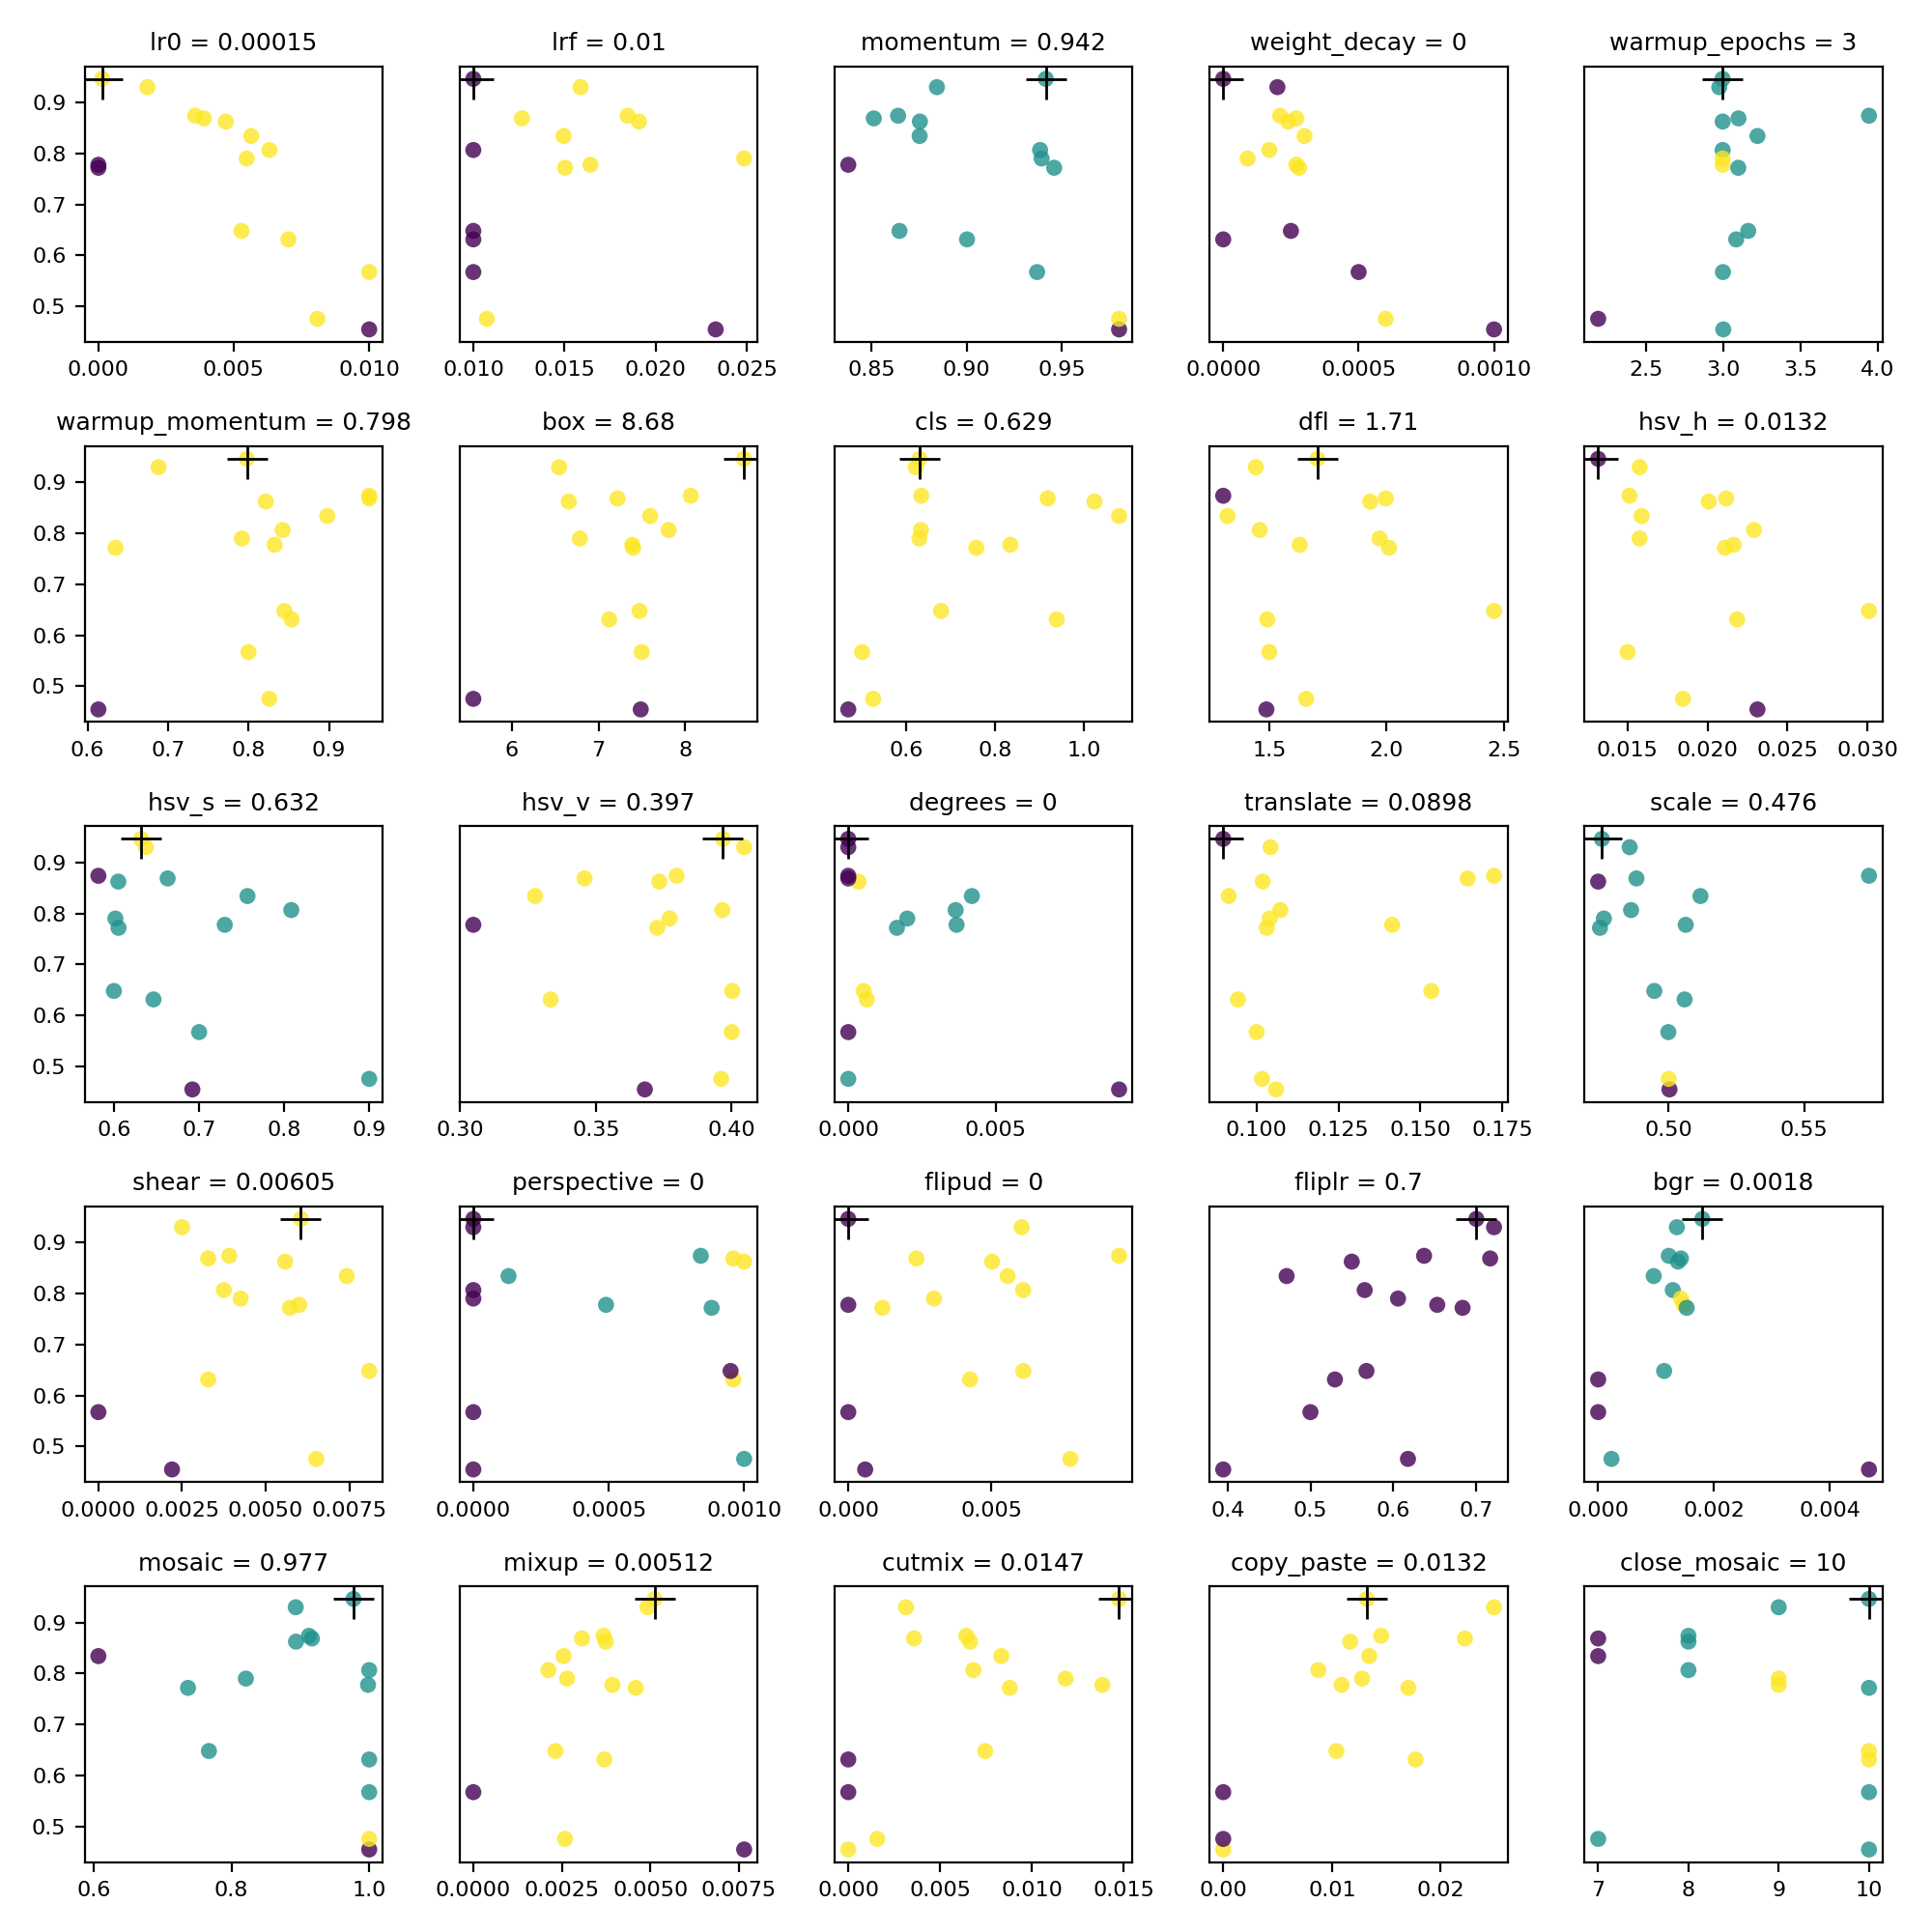

In [ ]:
display(Image('/content/runs/detect/tune/tune_scatter_plots.png'))

# **ENTRENAMIENTO**

In [ ]:
model.train(
    data='/content/Registradora_ahora_si-2/data.yaml',
    epochs=300,
    patience=50,
    imgsz=640,
    optimizer='auto',
    batch=16,
    lr0=0.01,
    lrf=0.01016,
    momentum=0.93036,
    weight_decay=0.00037,
    warmup_epochs=3.14386,
    warmup_momentum=0.94207,
    box=7.40635,
    cls=0.38017,
    dfl=1.4449,
    hsv_h=0.00888,
    hsv_s=0.52042,
    hsv_v=0.43848,
    degrees=0.0,
    translate=0.09008,
    scale=0.37636,
    shear=0.0,
    perspective=0.00046,
    flipud=0.00068,
    fliplr=0.48707,
    bgr=0.00258,
    mosaic=0.98415,
    mixup=0.0061,
    cutmix=0.00275,
    copy_paste=0.0019,
    close_mosaic=9
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.00258, box=7.40635, cache=False, cfg=None, classes=None, close_mosaic=9, cls=0.38017, compile=False, conf=None, copy_paste=0.0019, copy_paste_mode=flip, cos_lr=False, cutmix=0.00275, data=/content/Registradora_ahora_si-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.4449, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.48707, flipud=0.00068, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.00888, hsv_s=0.52042, hsv_v=0.43848, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01016, mask_ratio=4, max_det=300, mixup=0.0061, mode=train, model=yolov8s.pt, momentum=0.93036, mosaic=0.98415, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=Fa

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79433c6946b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,  

# **RESULTADOS**

## **Métricas**

In [ ]:
resultados = pd.read_csv('/content/runs/detect/train/results.csv')
resultados.sort_values(by='metrics/mAP50-95(B)', ascending=False).head(5)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
99,100,2564.23,0.29463,0.19995,0.83719,0.94502,0.98140,0.98659,0.96822,0.26747,0.15764,0.78430,0.000157,0.000157,0.000157
80,81,2077.38,0.30895,0.20822,0.83937,0.96489,0.97307,0.98848,0.96680,0.26761,0.15778,0.78172,0.000171,0.000171,0.000171
82,83,2128.90,0.30310,0.20738,0.83781,0.95277,0.98142,0.98747,0.96583,0.26935,0.16254,0.78219,0.000170,0.000170,0.000170
89,90,2307.83,0.29817,0.21766,0.83807,0.95616,0.95915,0.98497,0.96518,0.26242,0.15978,0.78234,0.000165,0.000165,0.000165
81,82,2103.14,0.30196,0.22072,0.83819,0.93643,0.98322,0.98784,0.96474,0.27462,0.16530,0.78406,0.000171,0.000171,0.000171


In [ ]:
resultados = pd.read_csv('/content/runs/detect/train/results.csv')
resultados.sort_values(by='metrics/mAP50-95(B)', ascending=False).tail(5)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
4,5,128.3350,0.38795,0.66777,0.86229,0.89421,0.91987,0.97132,0.91113,0.34859,0.39513,0.83417,0.000230,0.000230,0.000230
3,4,103.0600,0.38986,0.80659,0.86550,0.86569,0.92576,0.96509,0.89894,0.35788,0.43298,0.83292,0.000231,0.000231,0.000231
2,3,78.7339,0.38974,1.03818,0.86672,0.76825,0.84162,0.90304,0.84799,0.36359,0.70572,0.83908,0.000219,0.000219,0.000219
1,2,54.3289,0.39065,1.50818,0.87260,0.60502,0.73040,0.75105,0.71671,0.32764,0.91749,0.82301,0.000146,0.000146,0.000146
0,1,28.7383,0.51725,2.95611,0.94981,0.52587,0.37937,0.35737,0.33730,0.35173,1.70826,0.84367,0.000073,0.000073,0.000073


In [ ]:
ruta_yaml = '/content/runs/detect/train/args.yaml'

with open(ruta_yaml, "r") as file:
    contenido = file.read()

print(contenido)

task: detect
mode: train
model: yolov8s.pt
data: /content/Registradora_ahora_si-2/data.yaml
epochs: 300
time: null
patience: 50
batch: 16
imgsz: 640
save: true
save_period: -1
cache: false
device: null
workers: 8
project: null
name: train
exist_ok: false
pretrained: true
optimizer: auto
verbose: true
seed: 0
deterministic: true
single_cls: false
rect: false
cos_lr: false
close_mosaic: 9
resume: false
amp: true
fraction: 1.0
profile: false
freeze: null
multi_scale: 0.0
compile: false
overlap_mask: true
mask_ratio: 4
dropout: 0.0
val: true
split: val
save_json: false
conf: null
iou: 0.7
max_det: 300
half: false
dnn: false
plots: true
end2end: null
source: null
vid_stride: 1
stream_buffer: false
visualize: false
augment: false
agnostic_nms: false
classes: null
retina_masks: false
embed: null
show: false
save_frames: false
save_txt: false
save_conf: false
save_crop: false
show_labels: true
show_conf: true
show_boxes: true
line_width: null
format: torchscript
keras: false
optimize: false
in

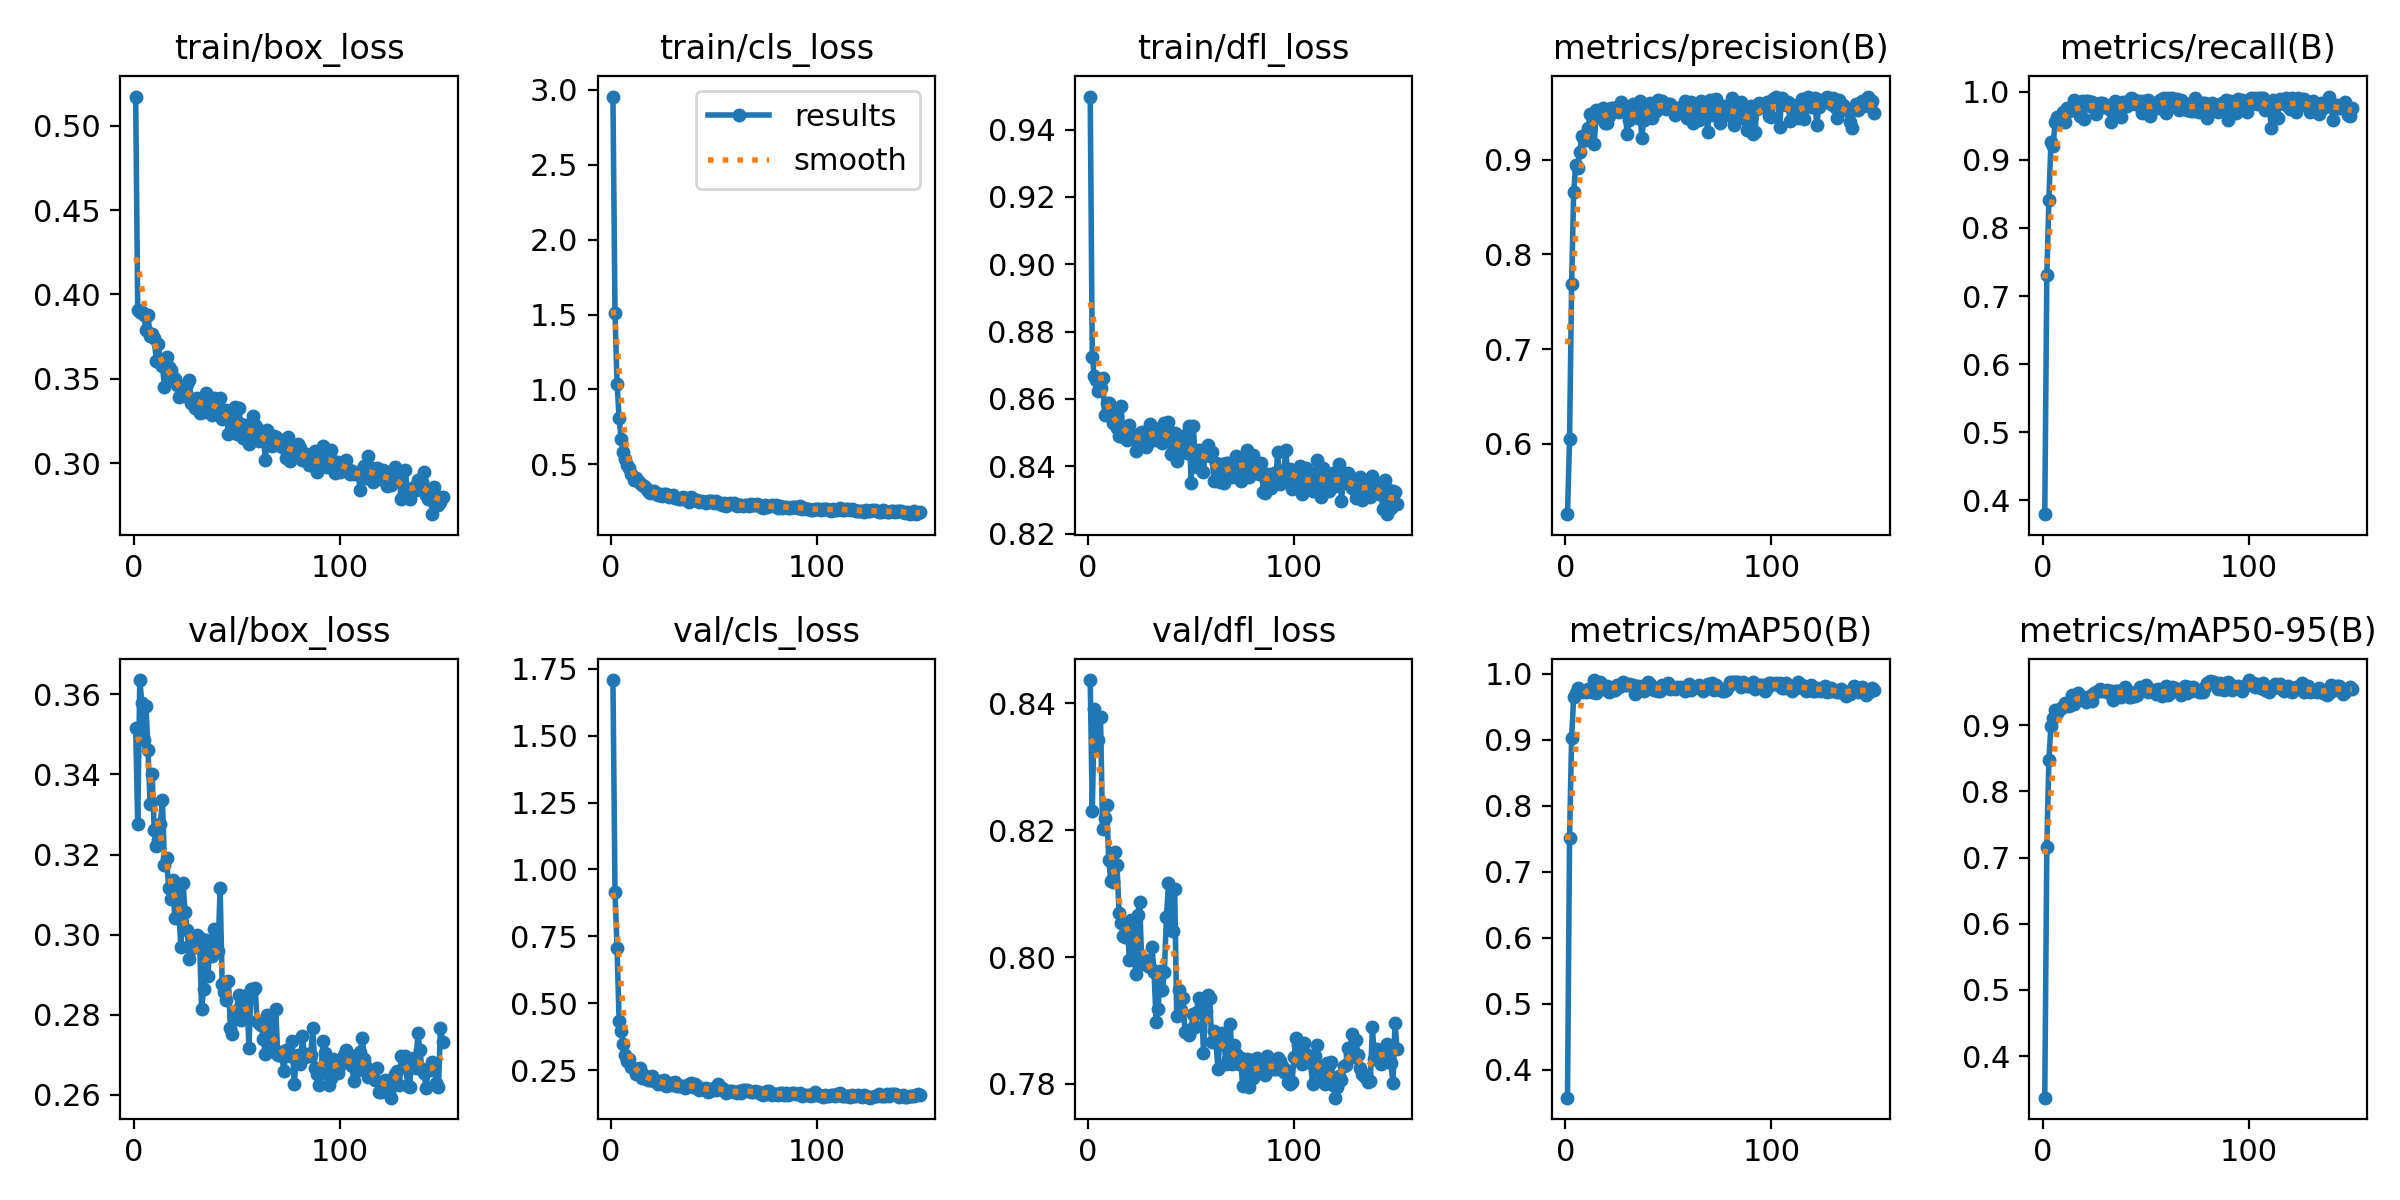

In [ ]:
display(Image('/content/runs/detect/train/results.png'))

## **Matriz De Confusión**

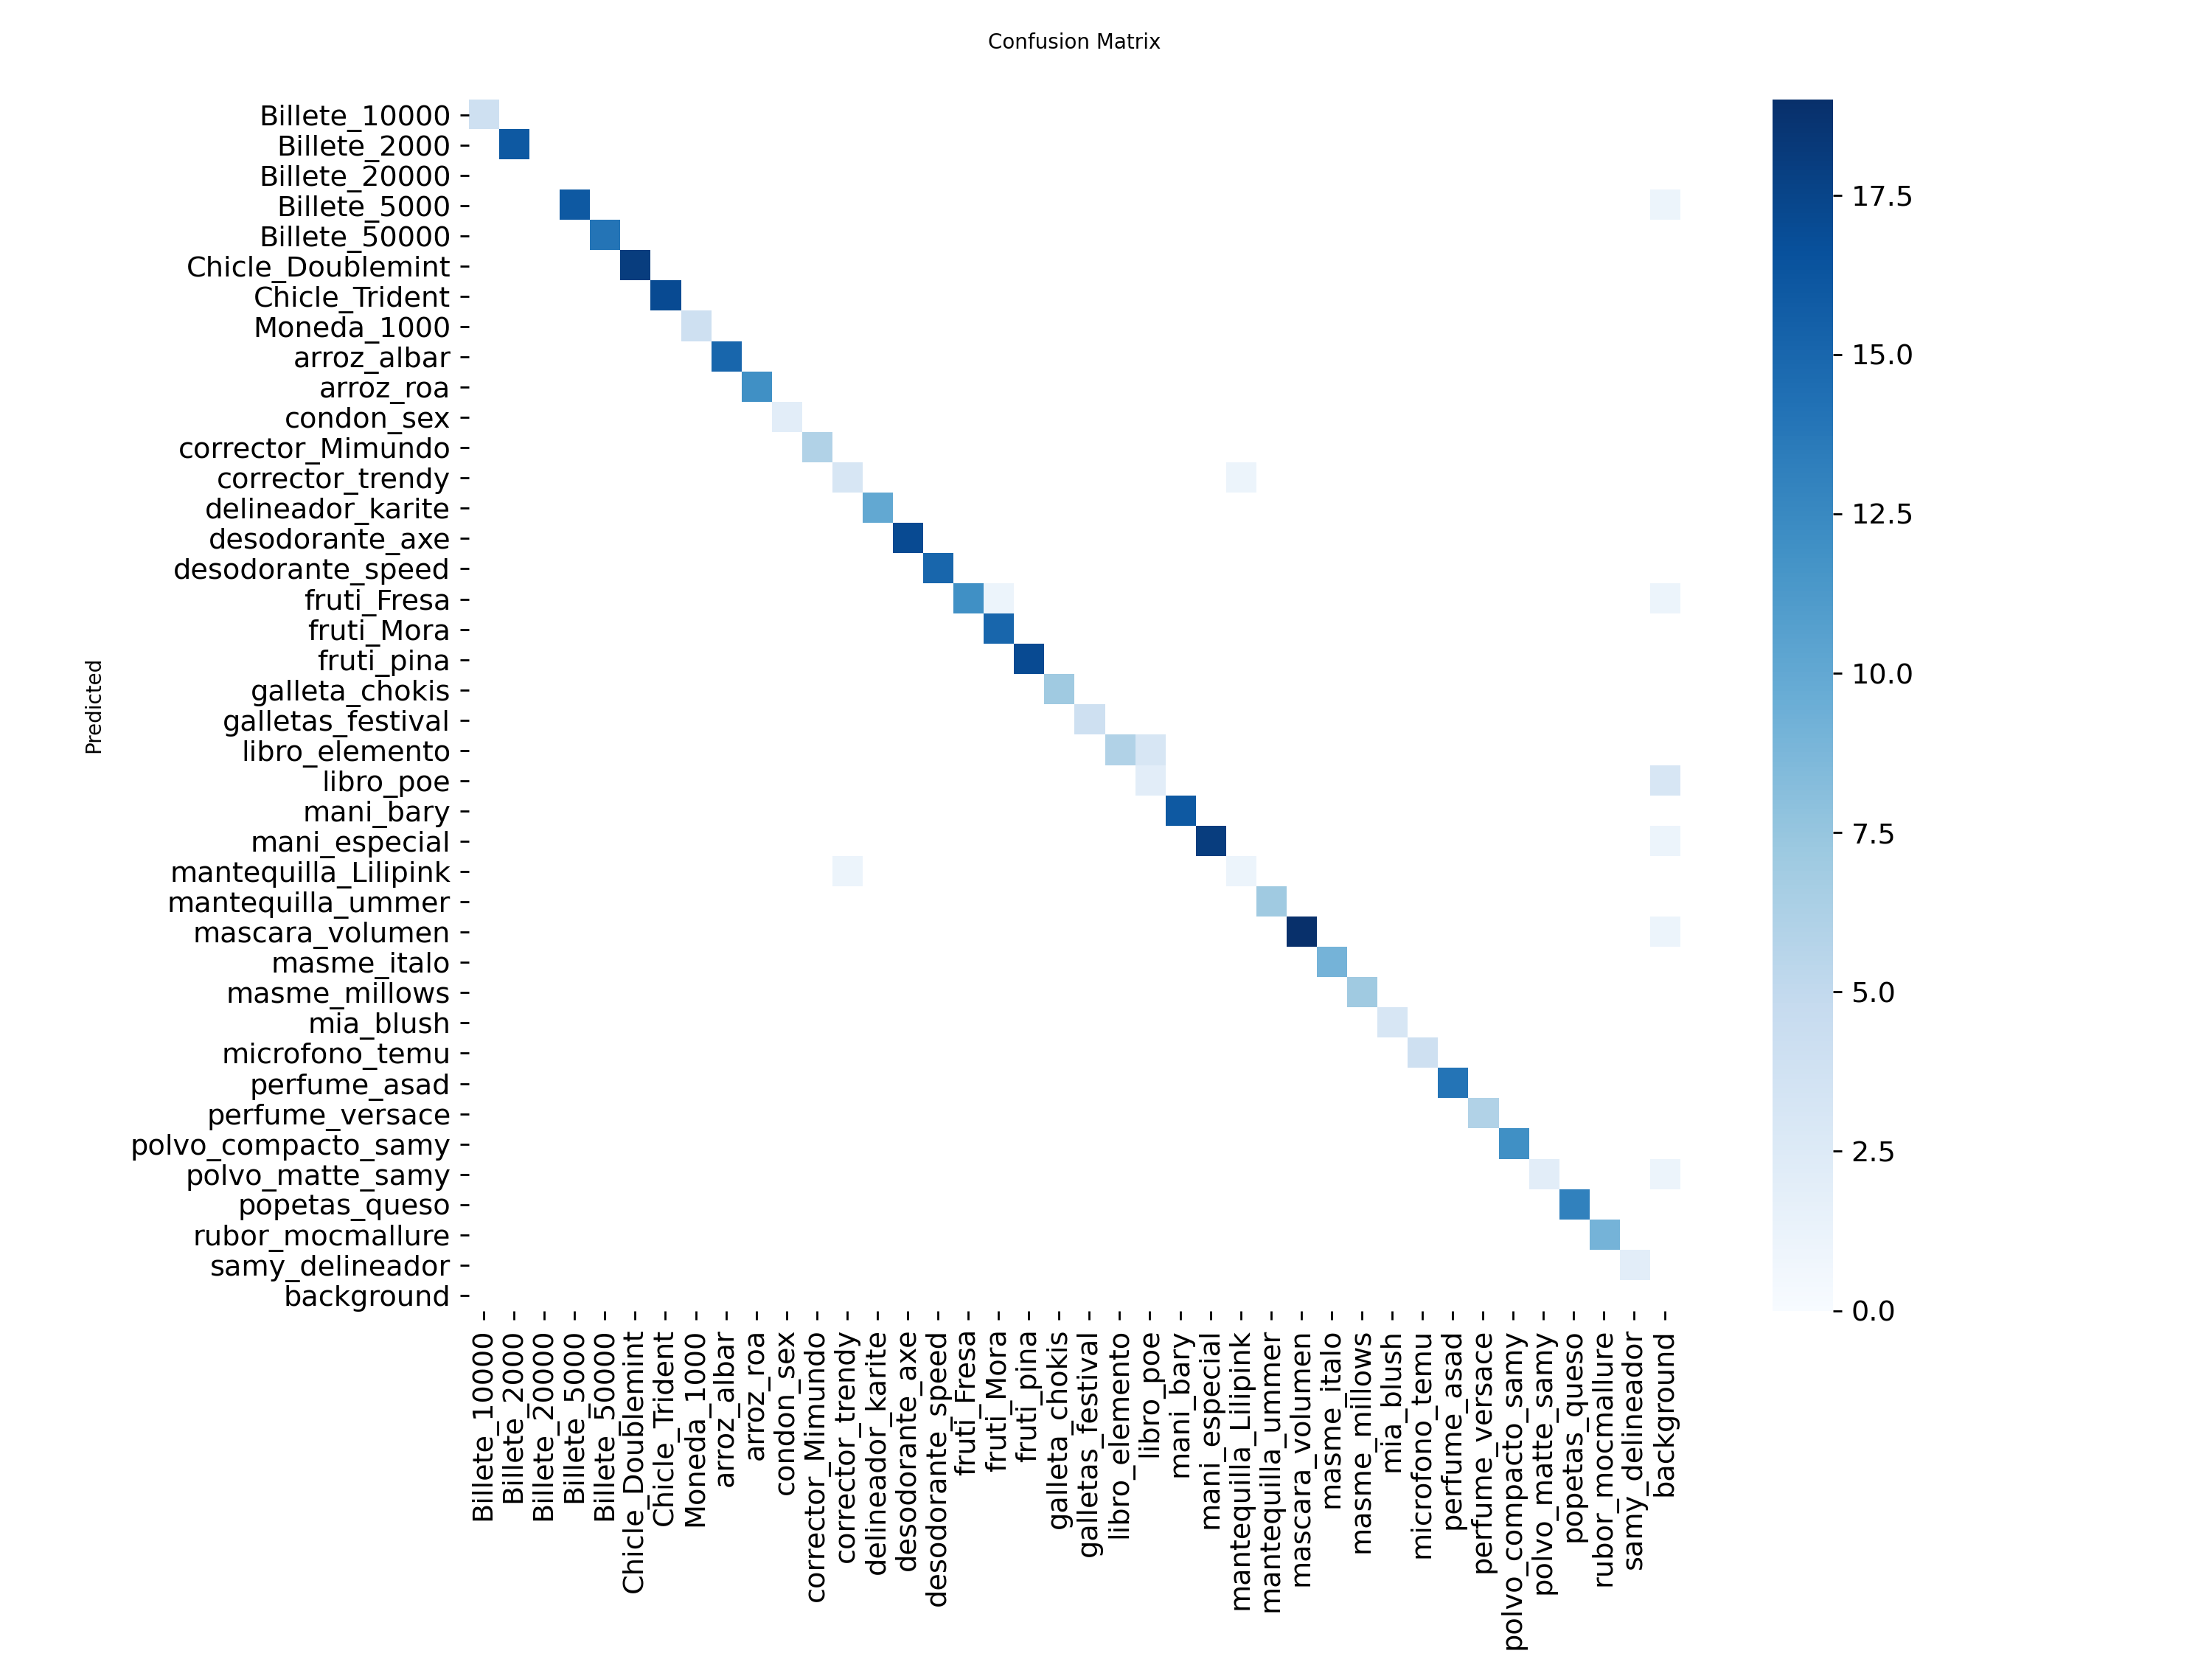

In [ ]:
display(Image('/content/runs/detect/train/confusion_matrix.png'))

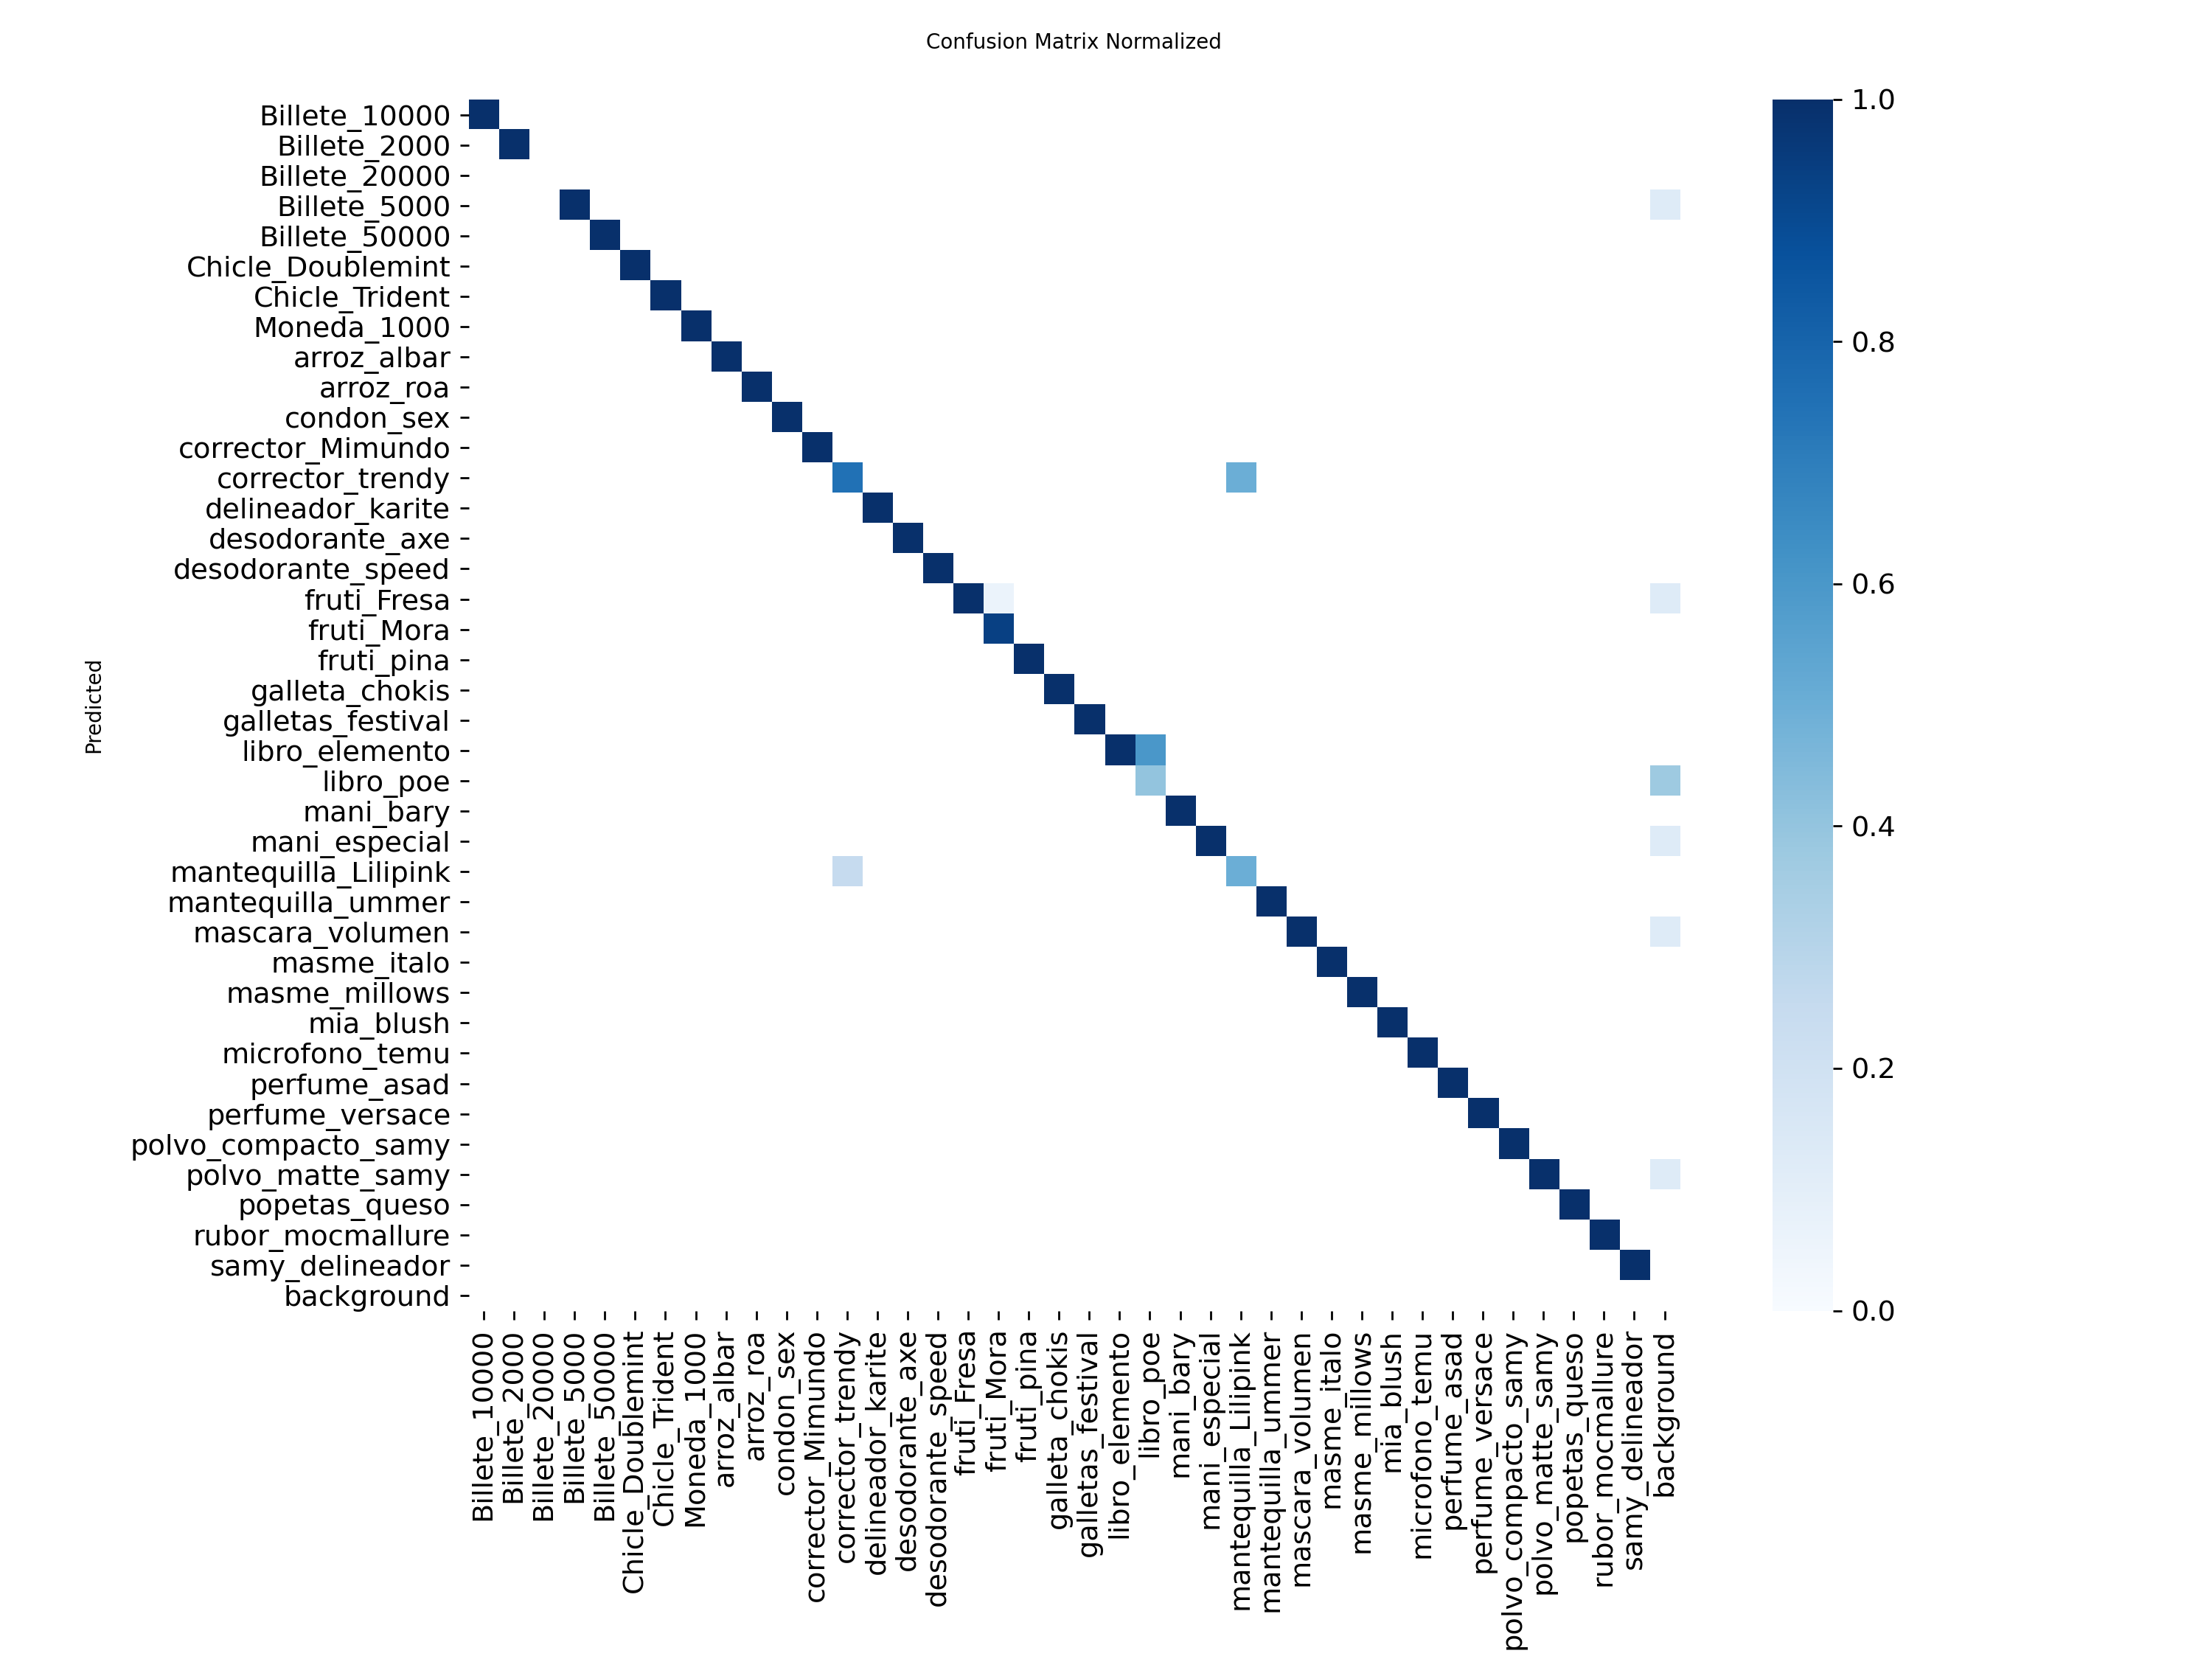

In [ ]:
display(Image('/content/runs/detect/train/confusion_matrix_normalized.png'))

## **Precision, Recall y F1-Score**

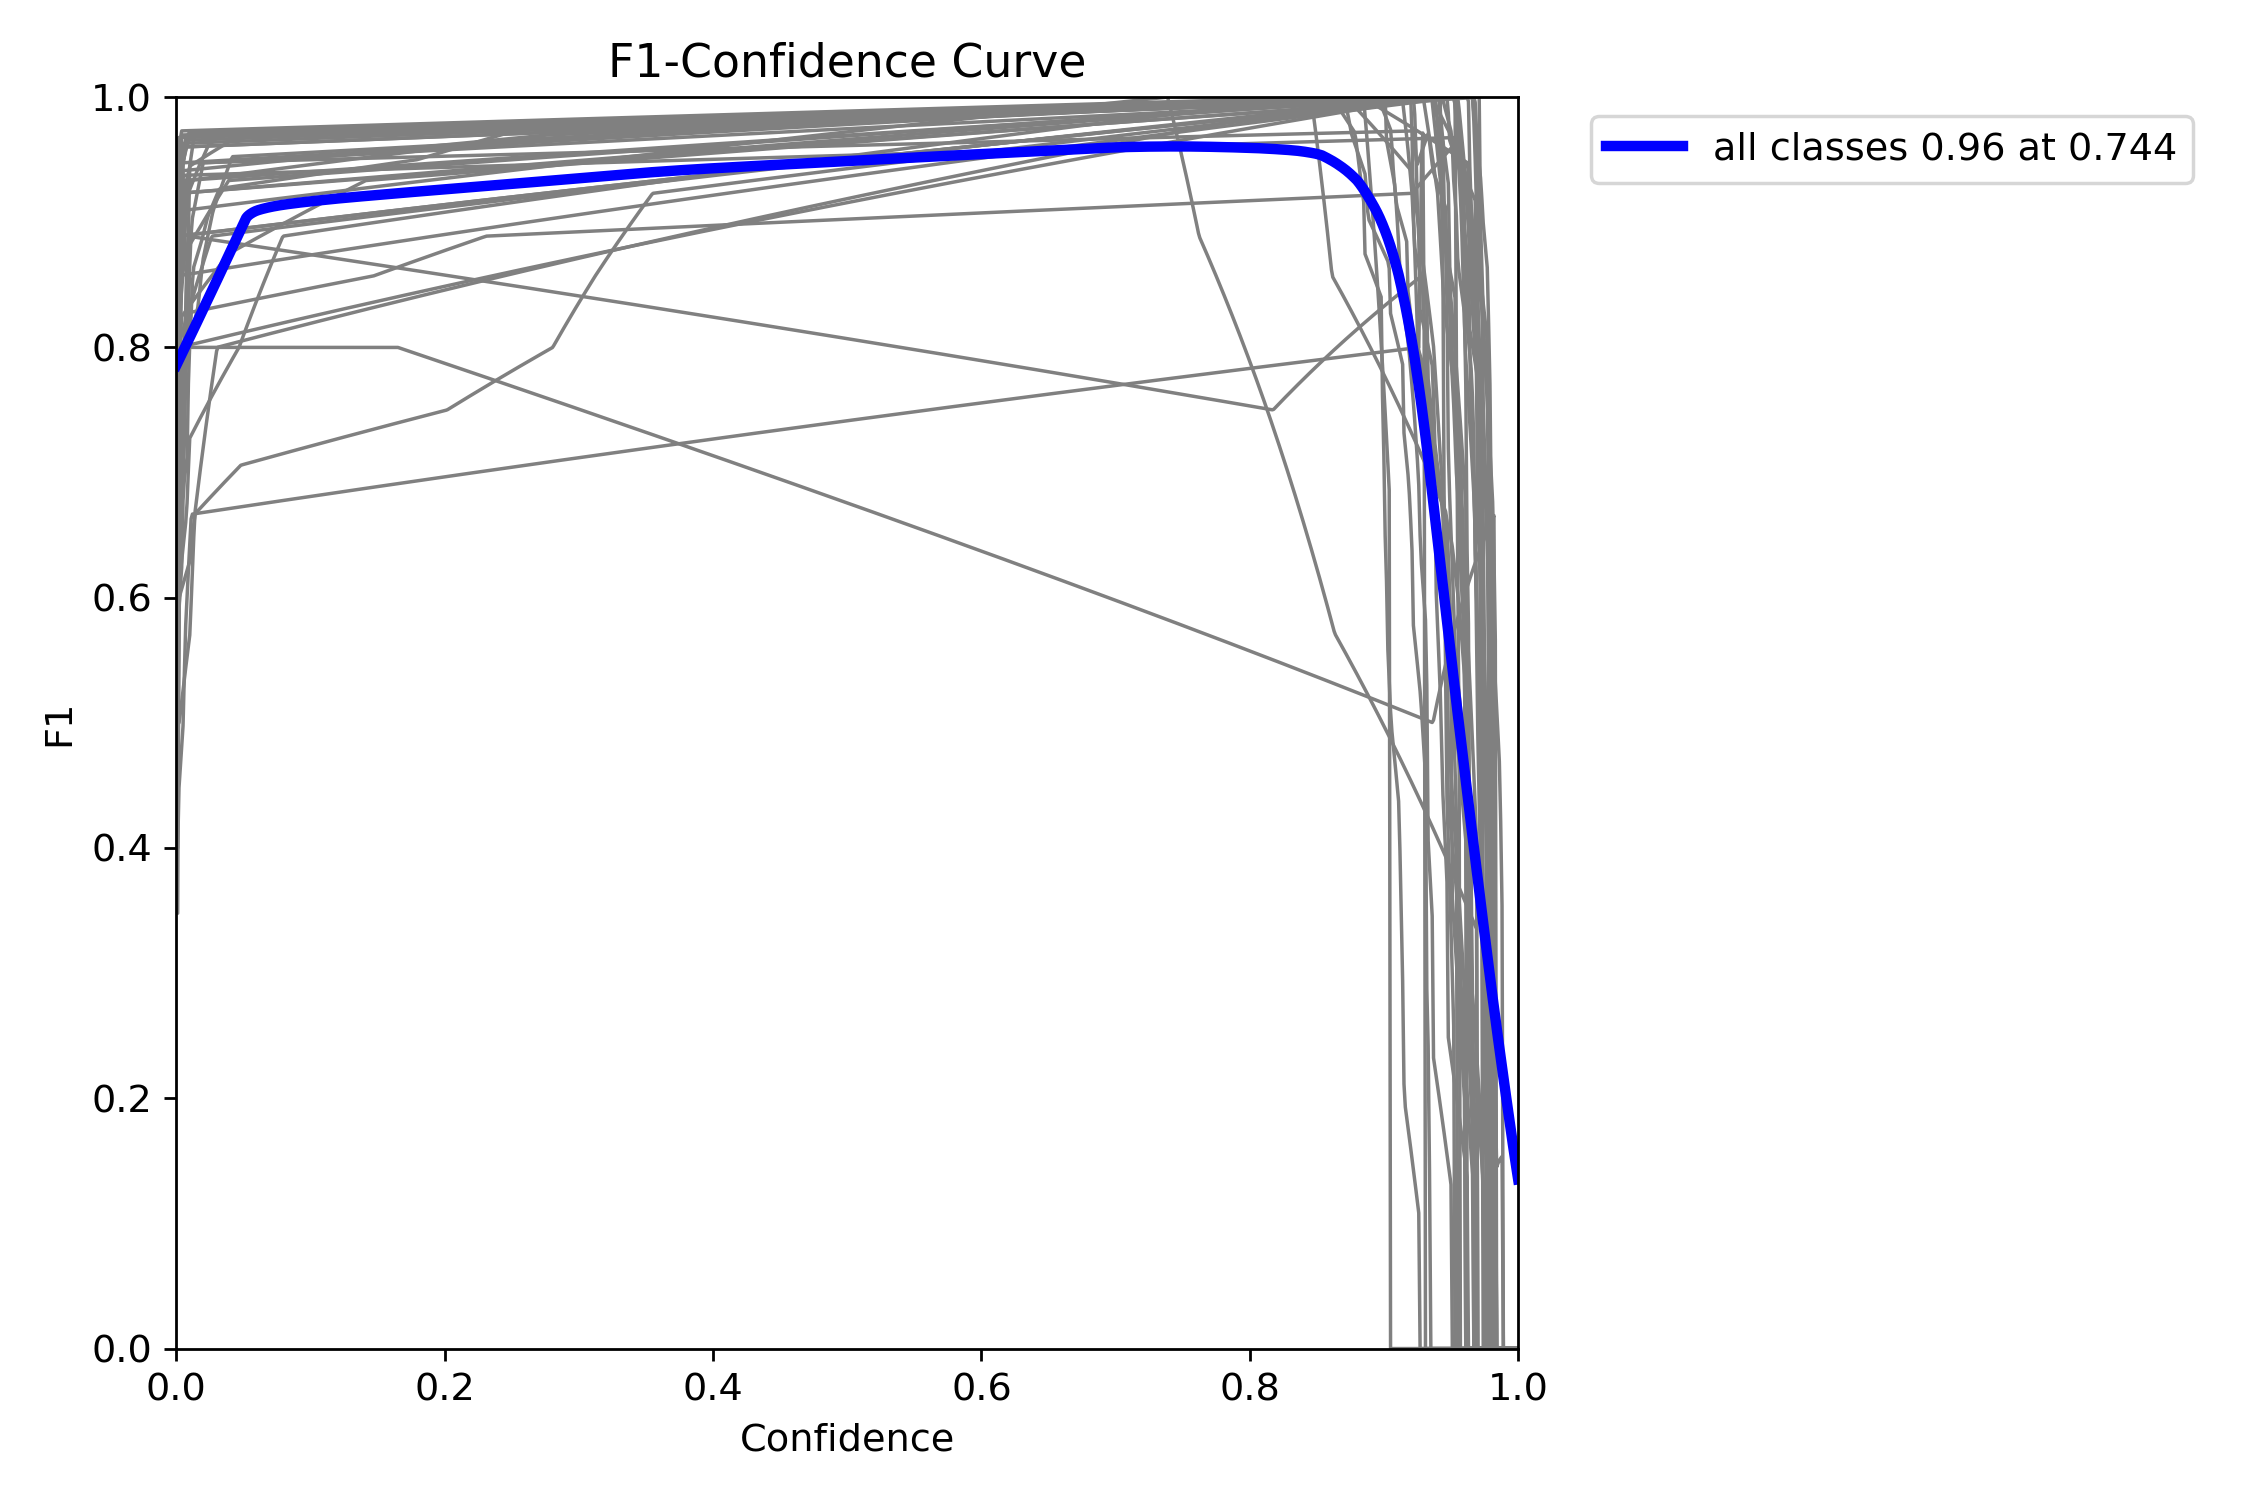

In [ ]:
display(Image('/content/runs/detect/train/BoxF1_curve.png'))

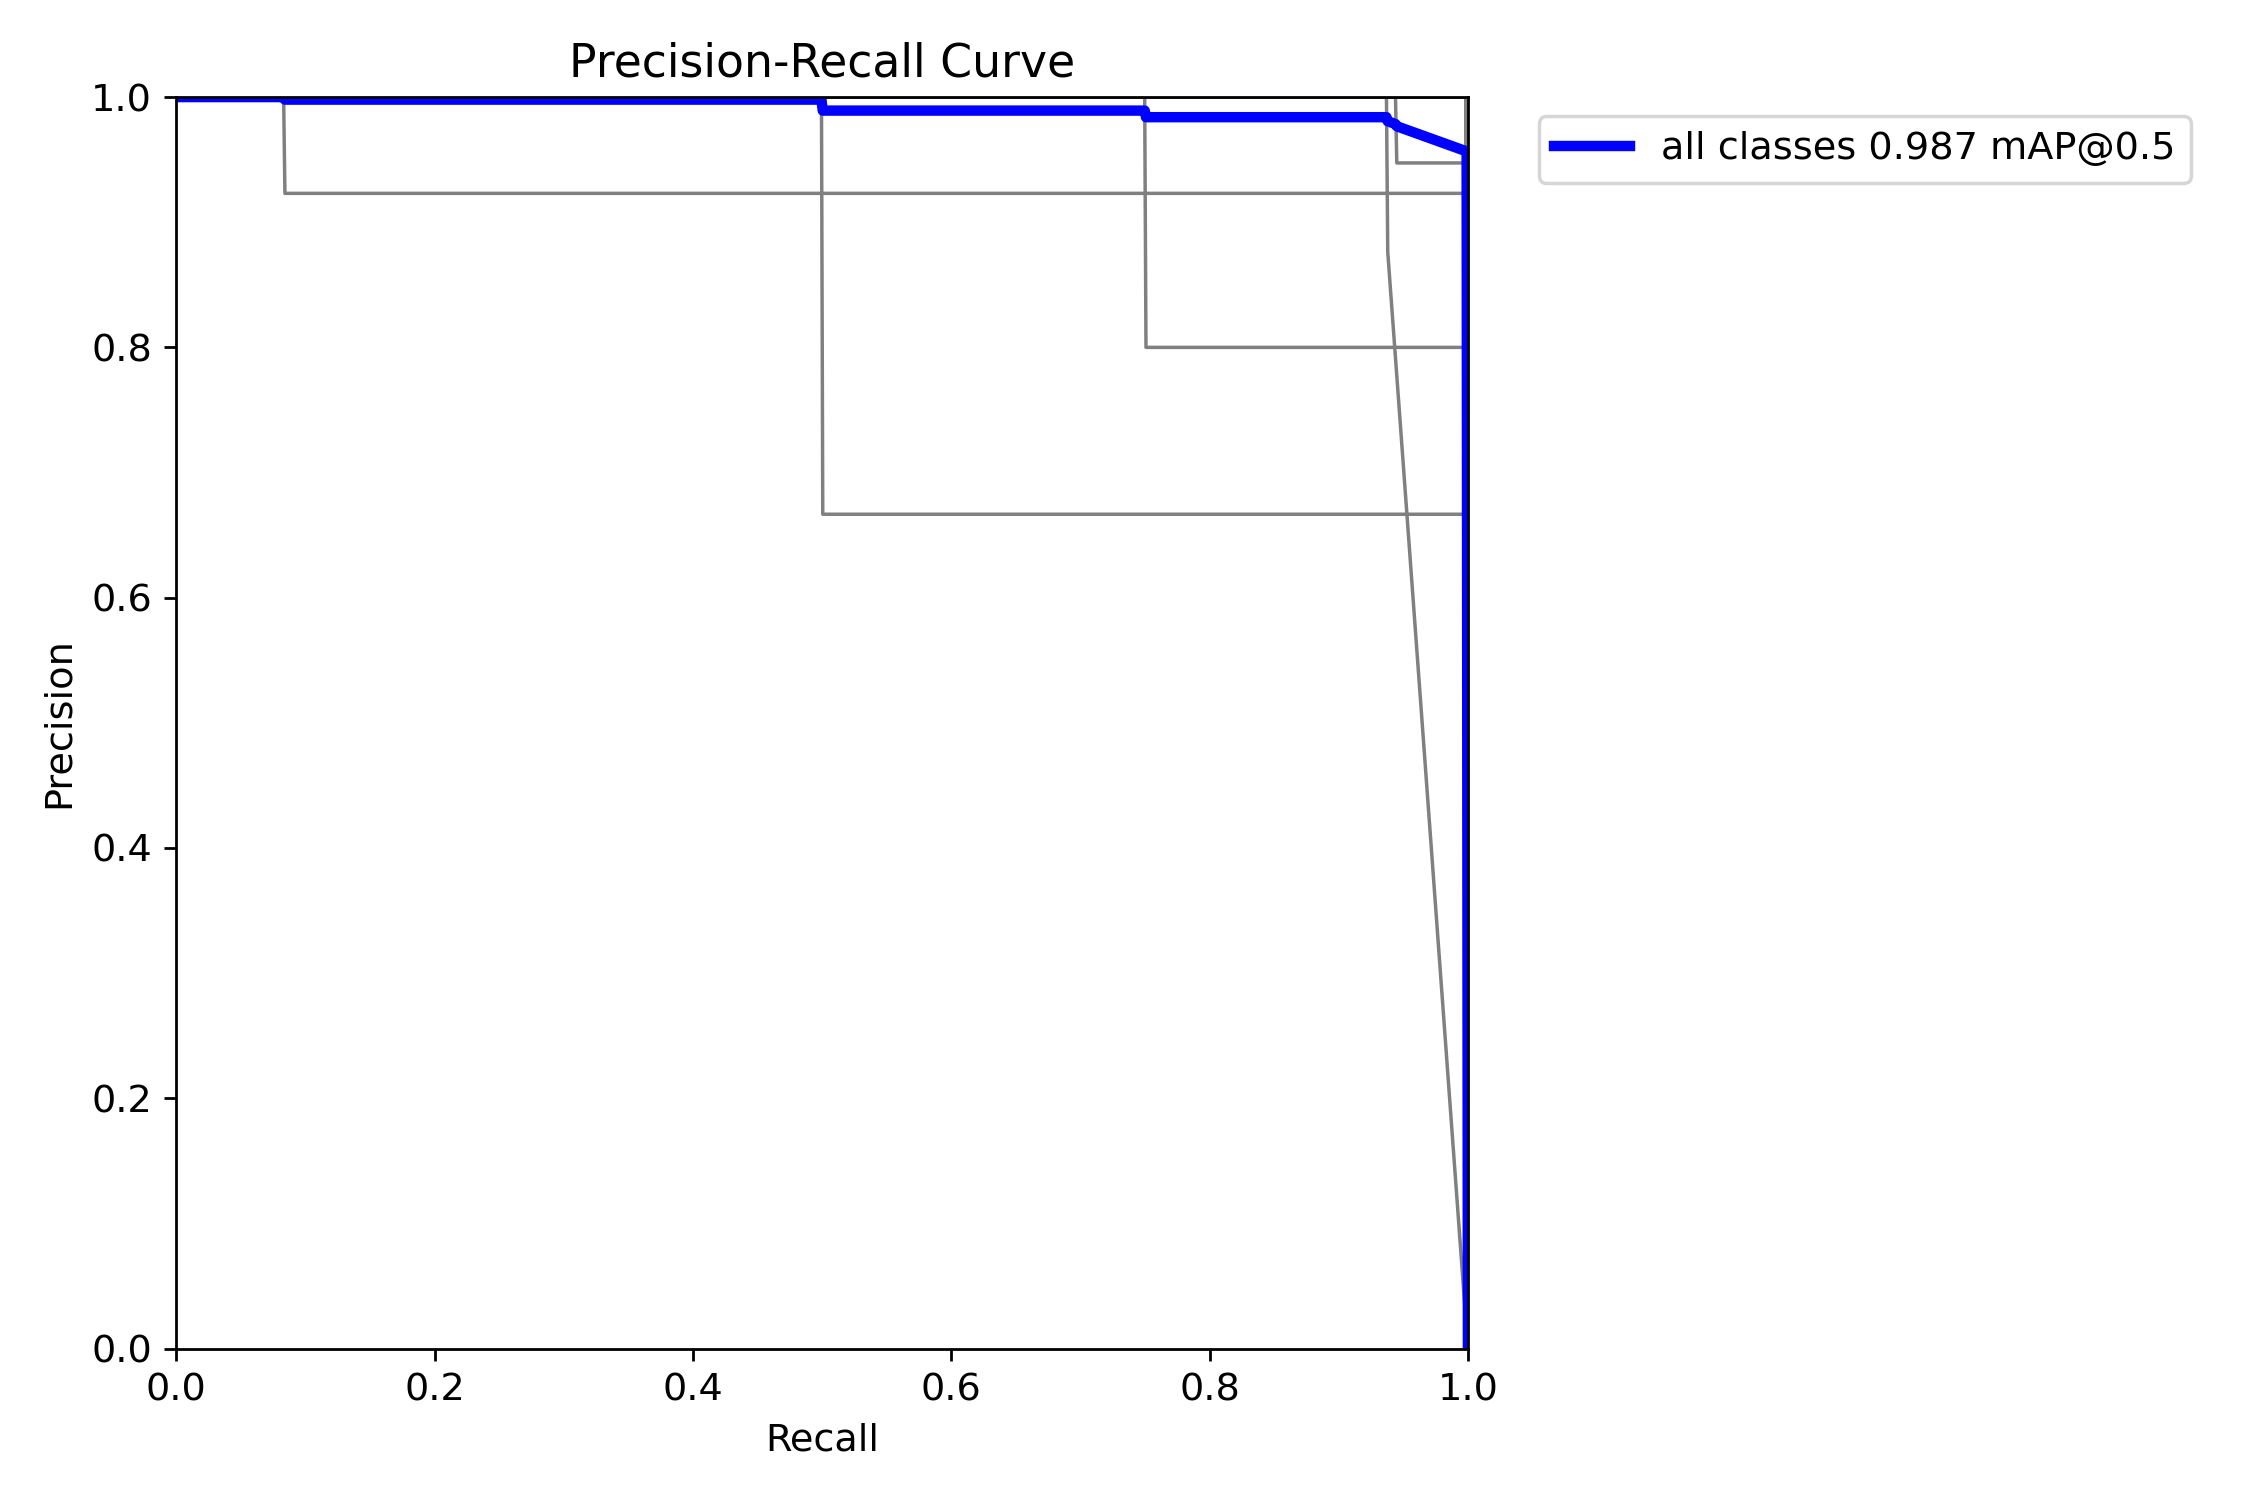

In [ ]:
display(Image('/content/runs/detect/train/BoxPR_curve.png'))

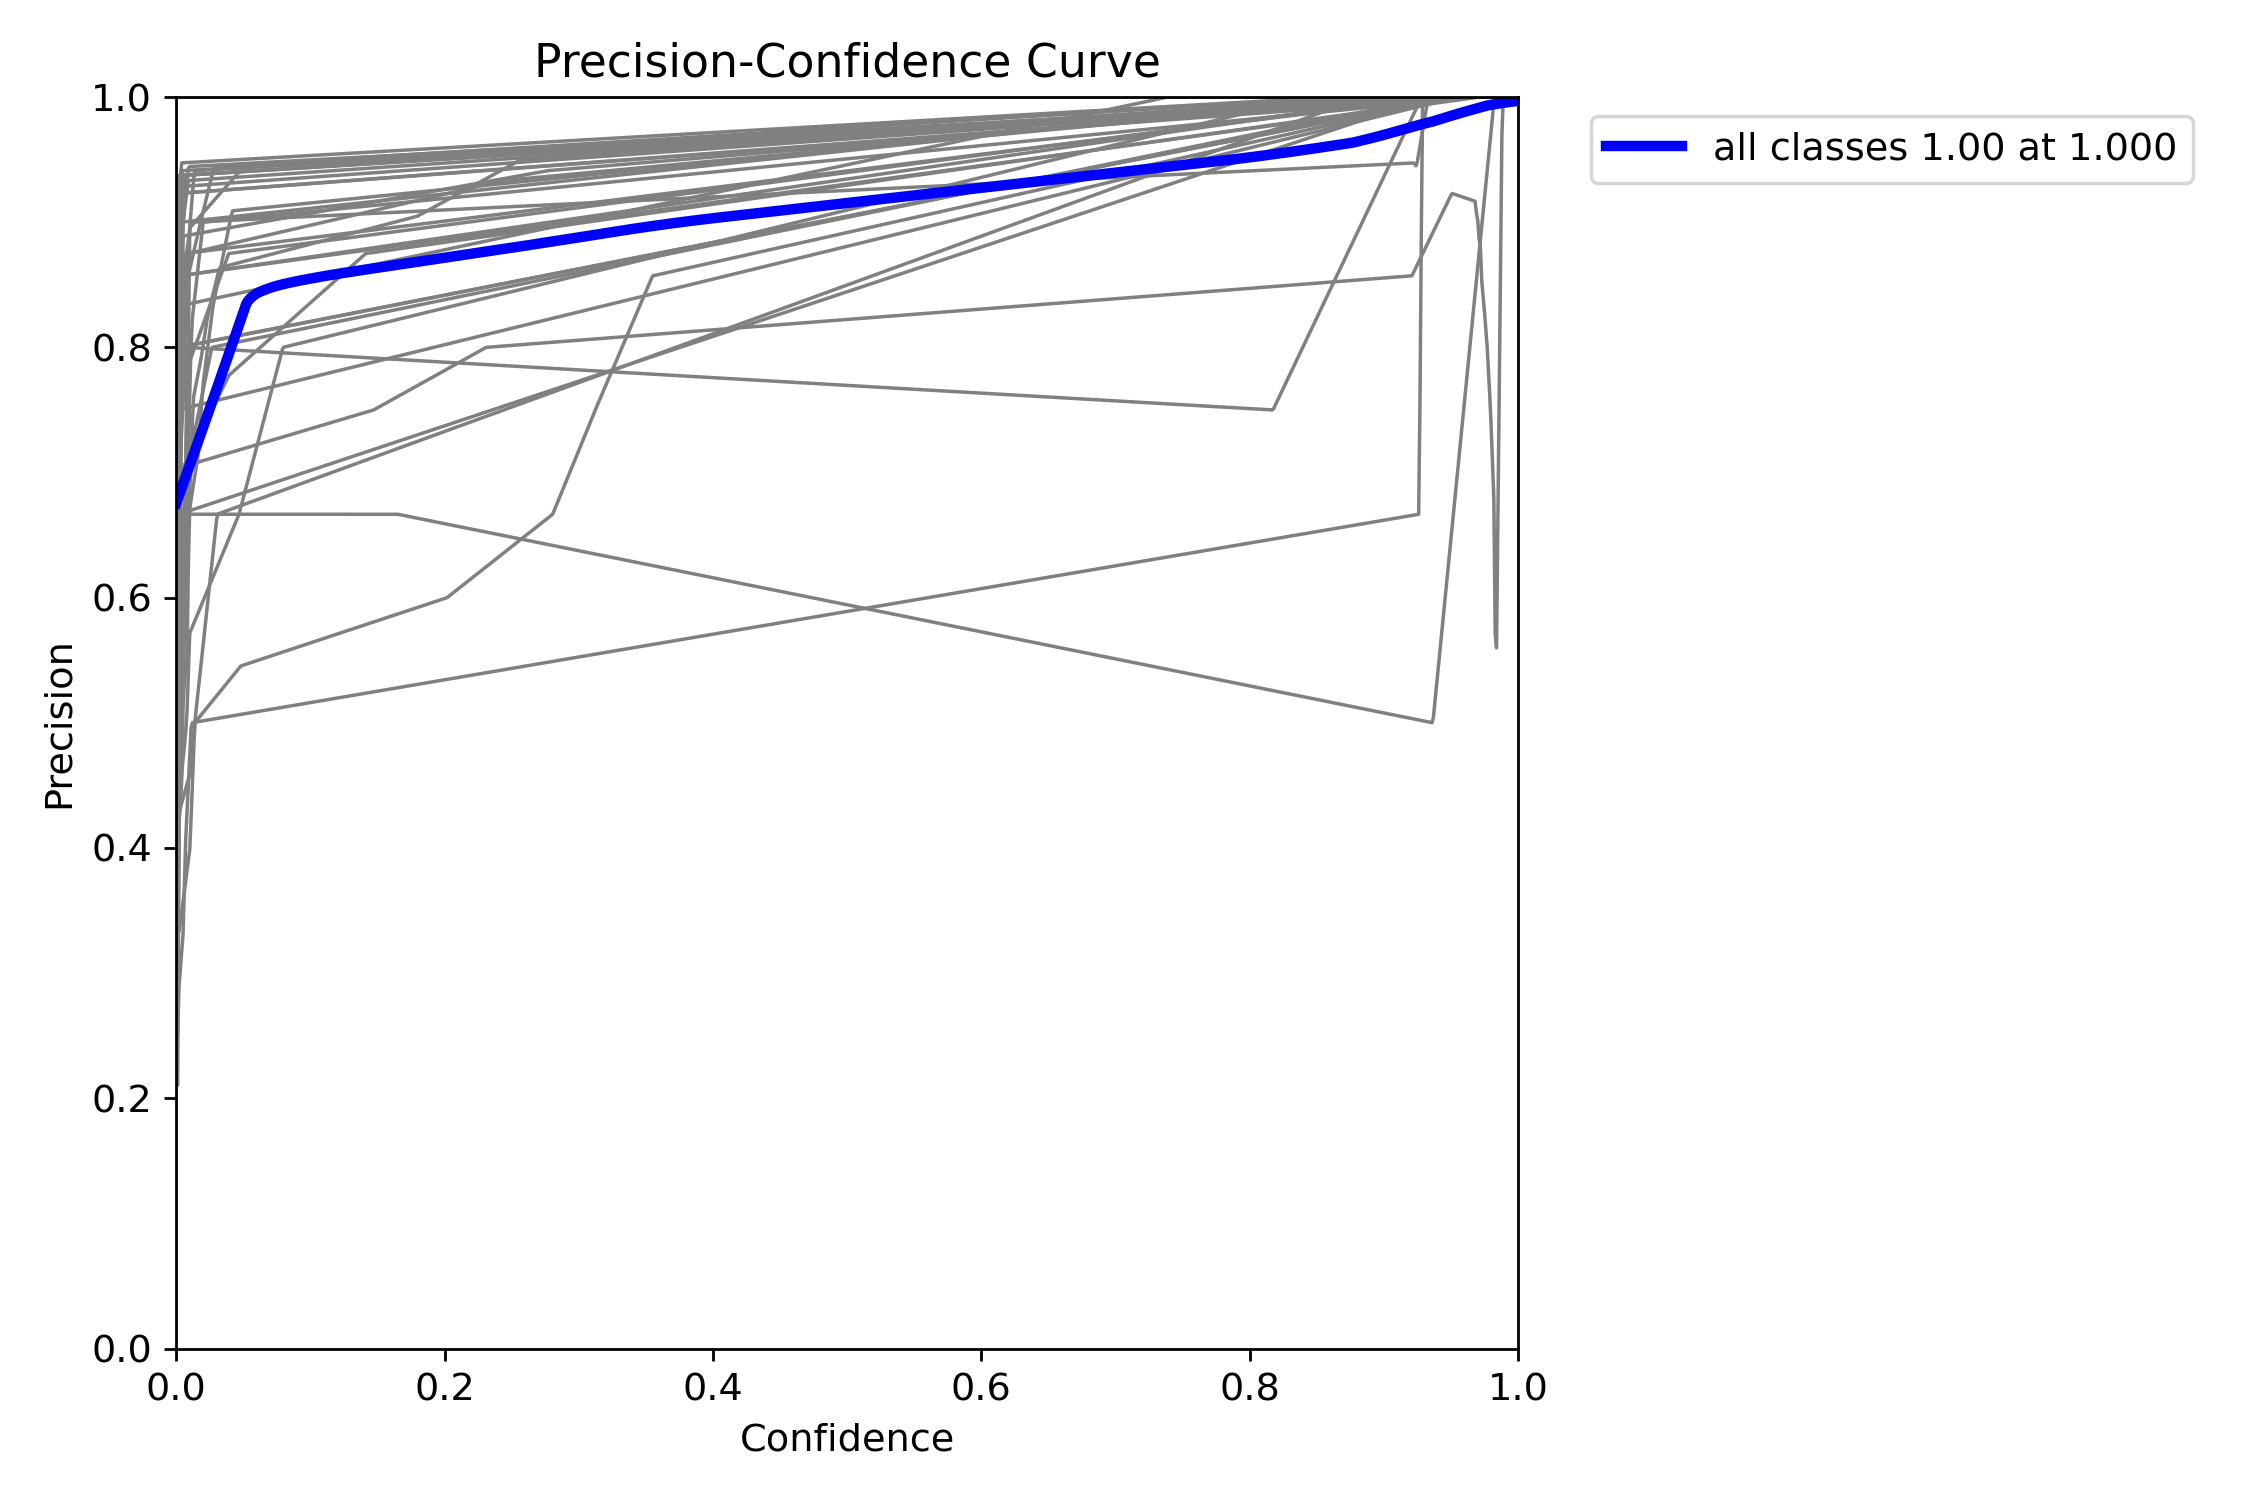

In [ ]:
display(Image('/content/runs/detect/train/BoxP_curve.png'))

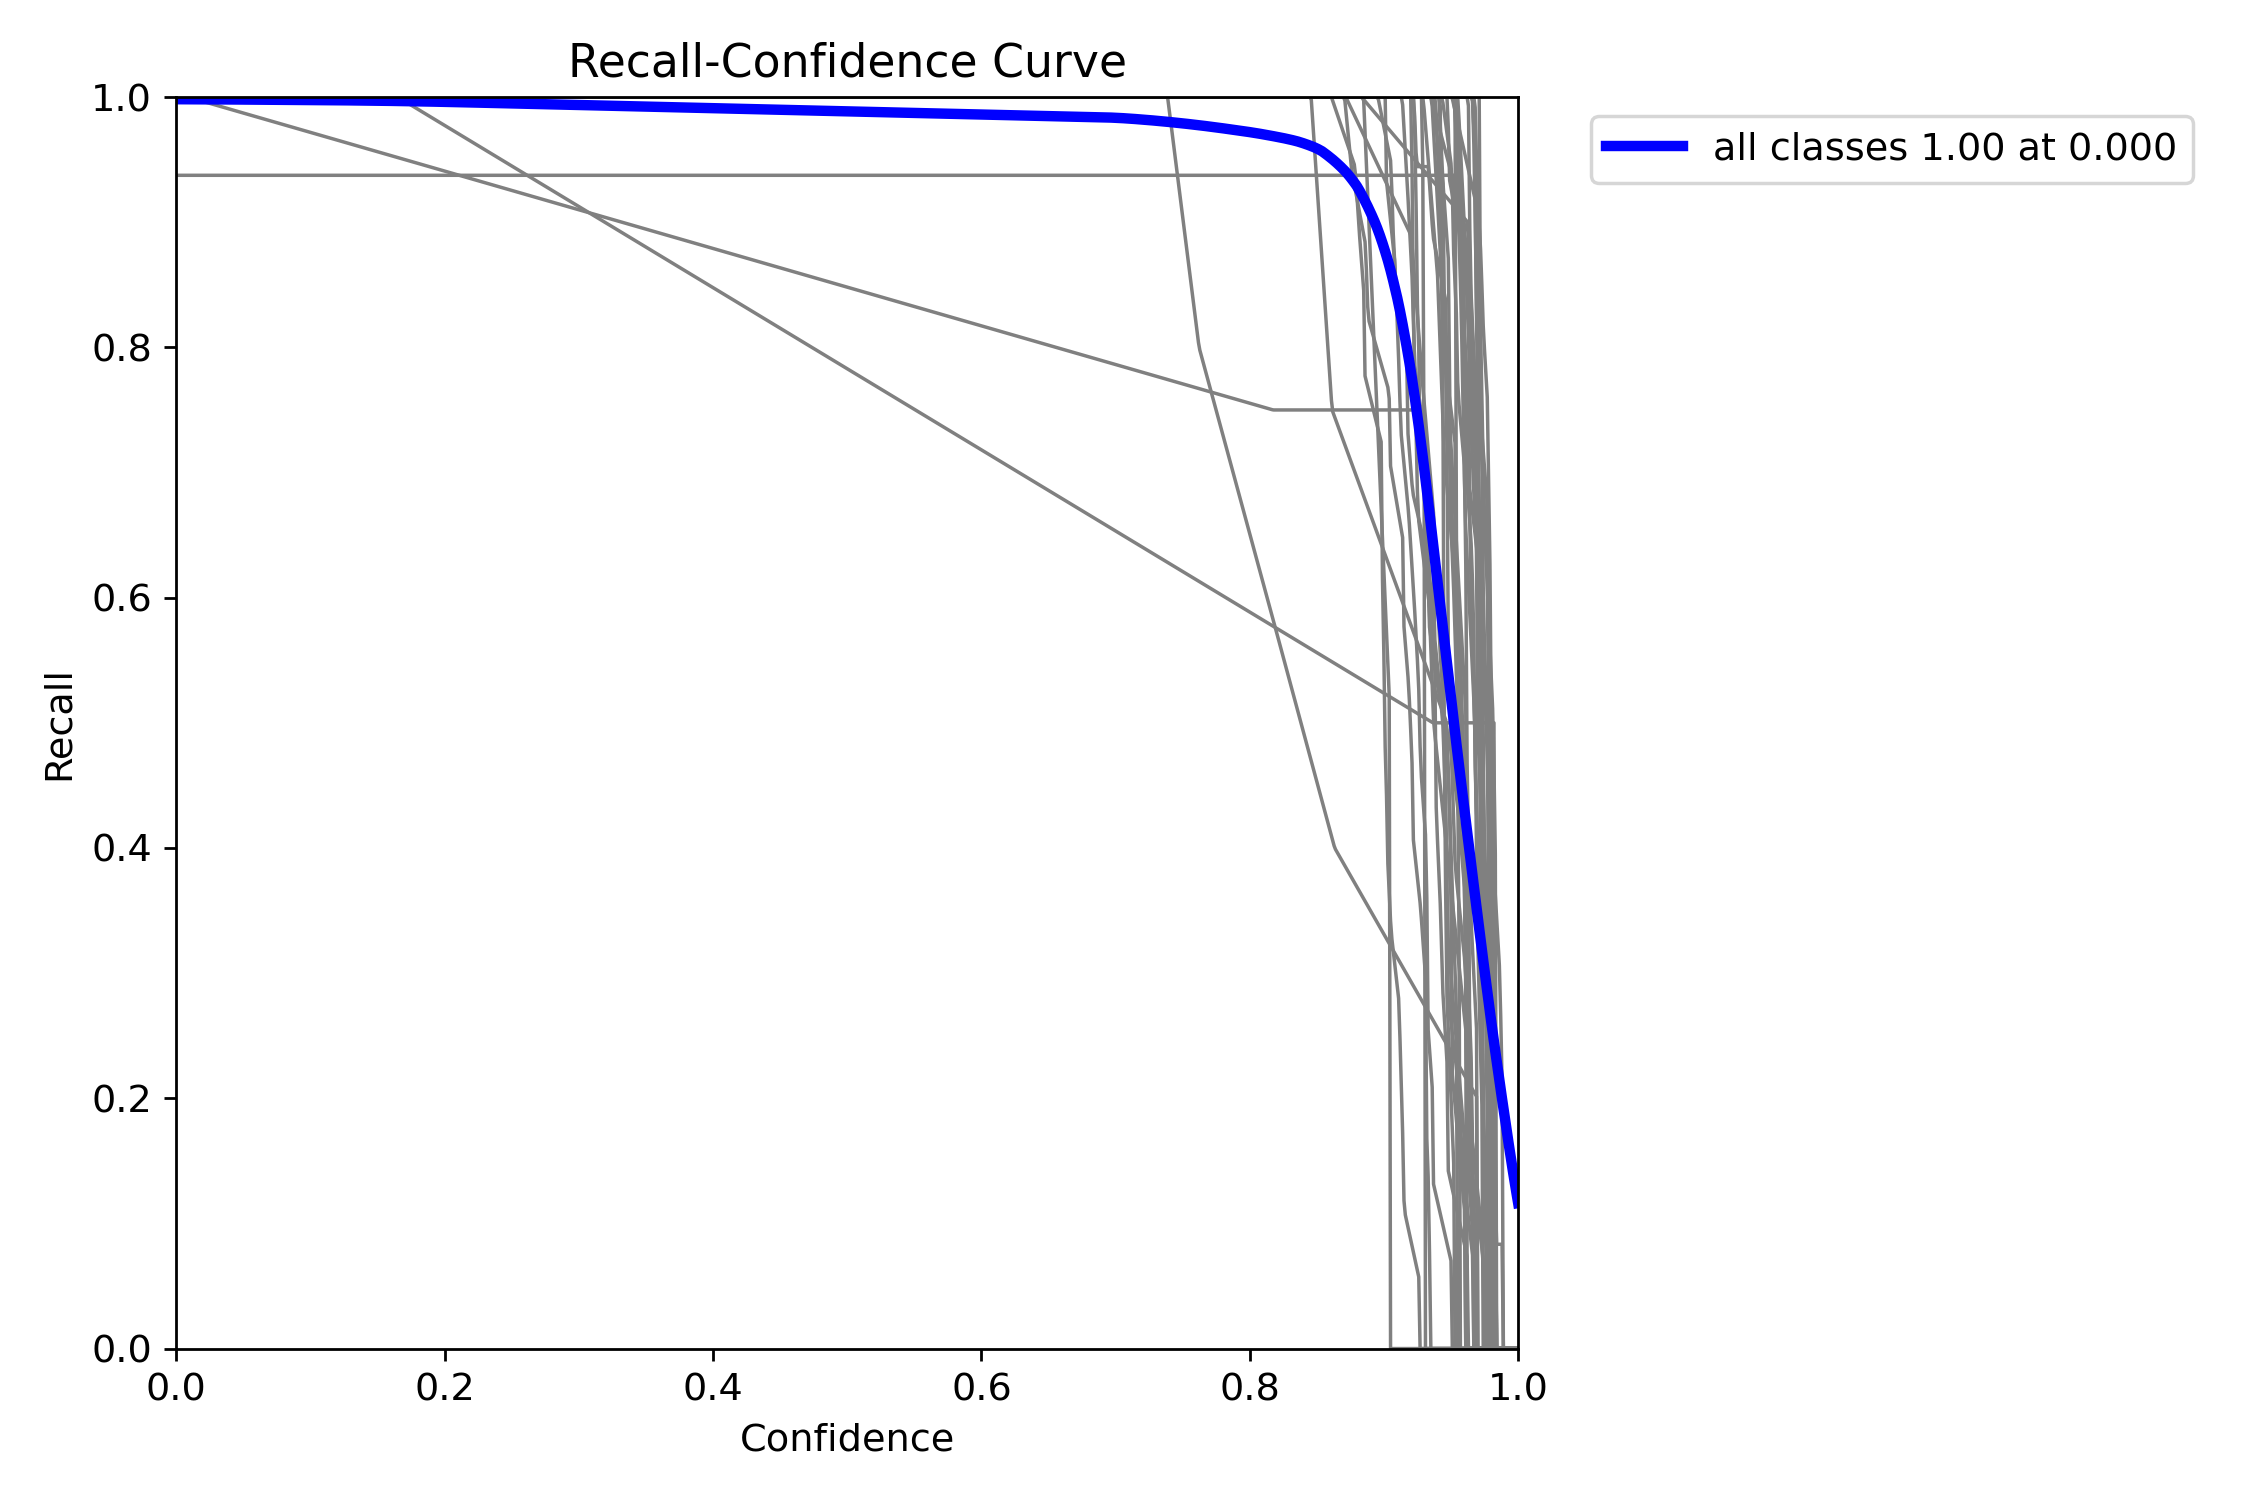

In [ ]:
display(Image('/content/runs/detect/train/BoxR_curve.png'))

## **Resultado De Imágenes**

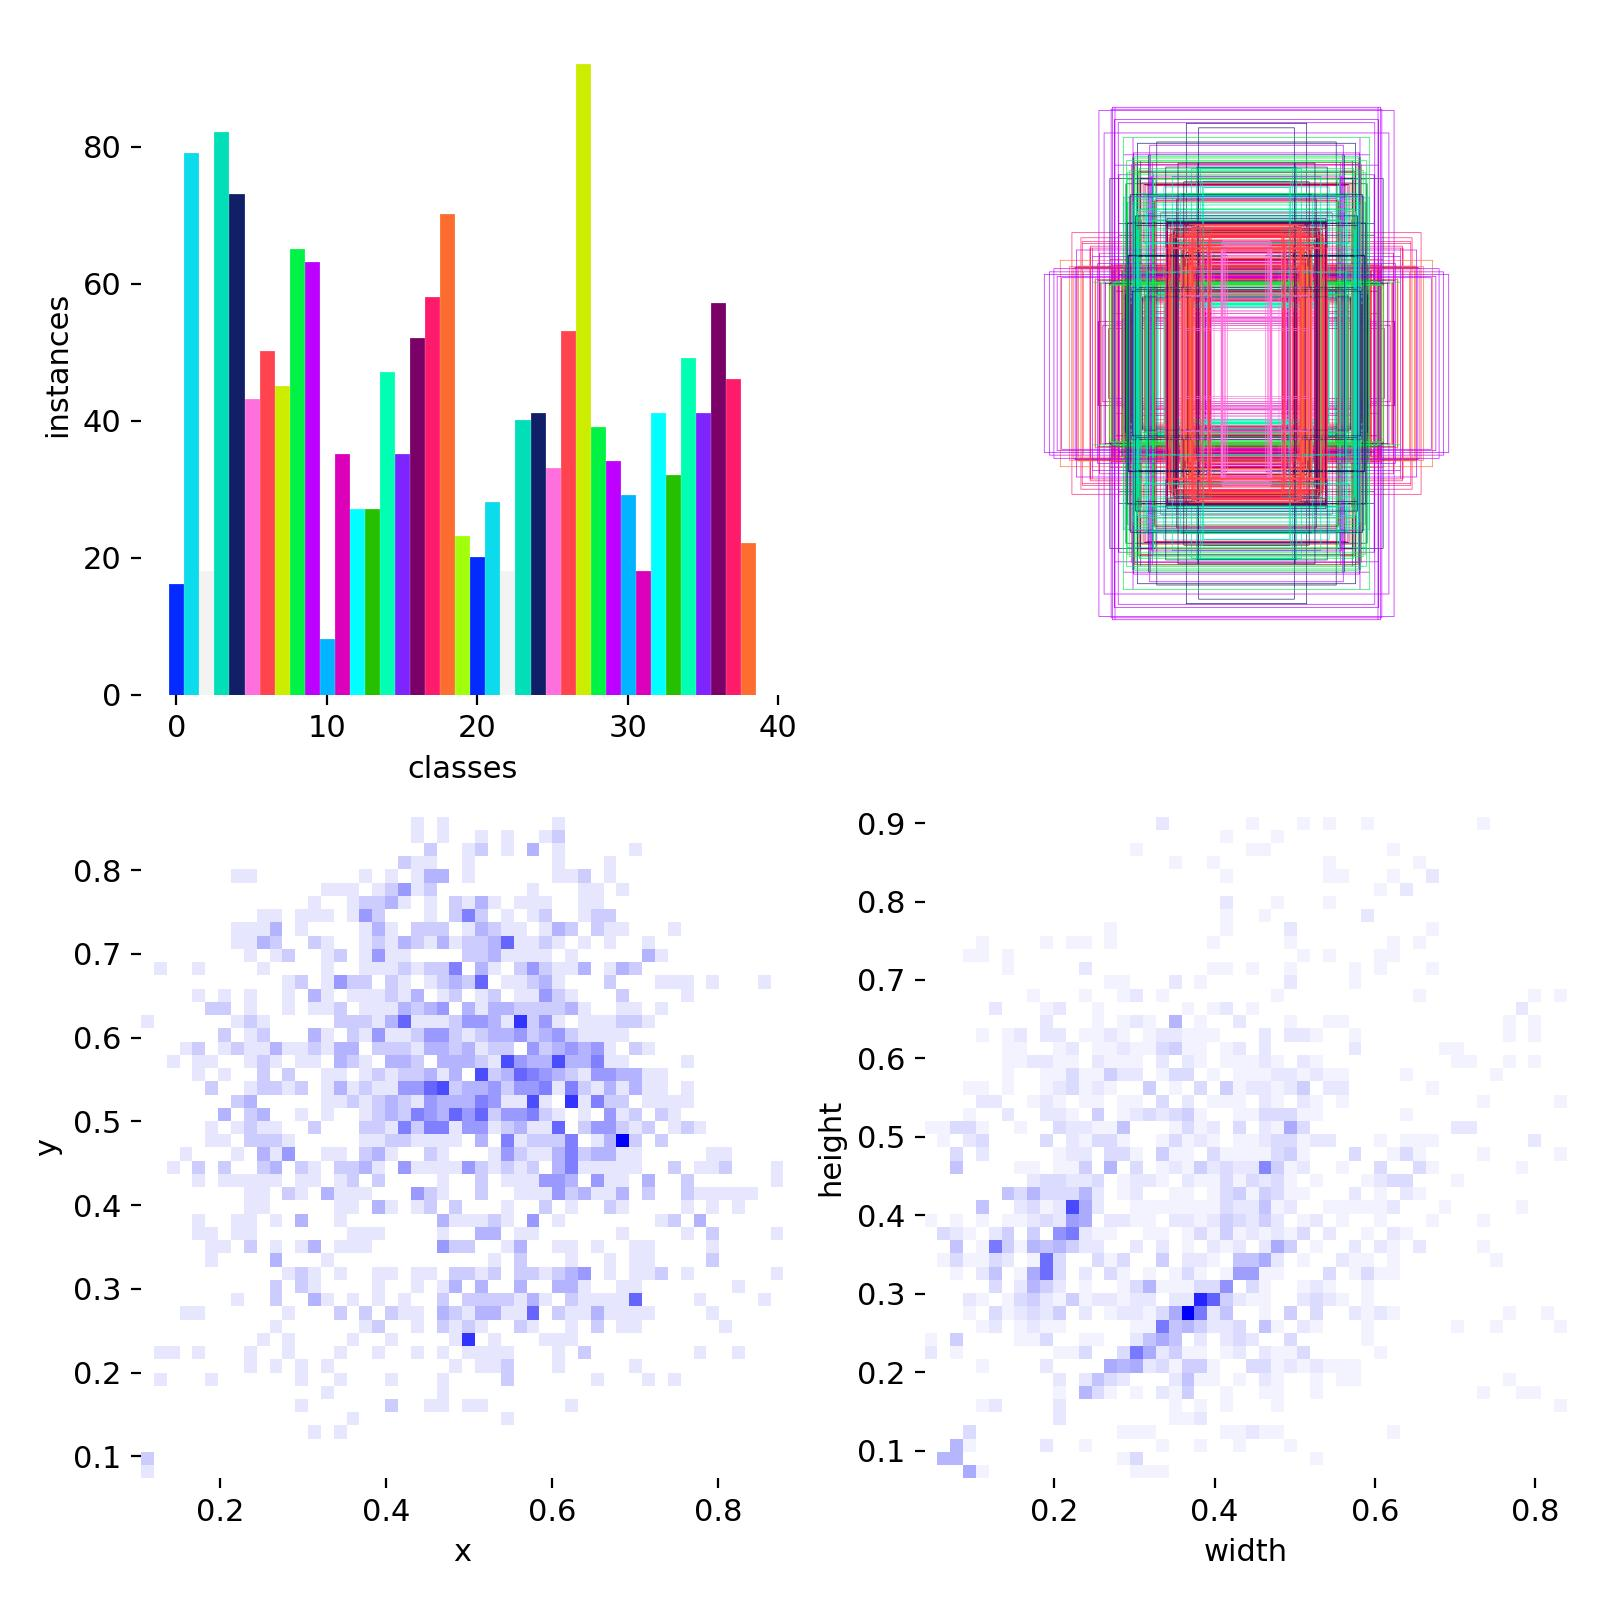

In [ ]:
display(Image('/content/runs/detect/train/labels.jpg'))

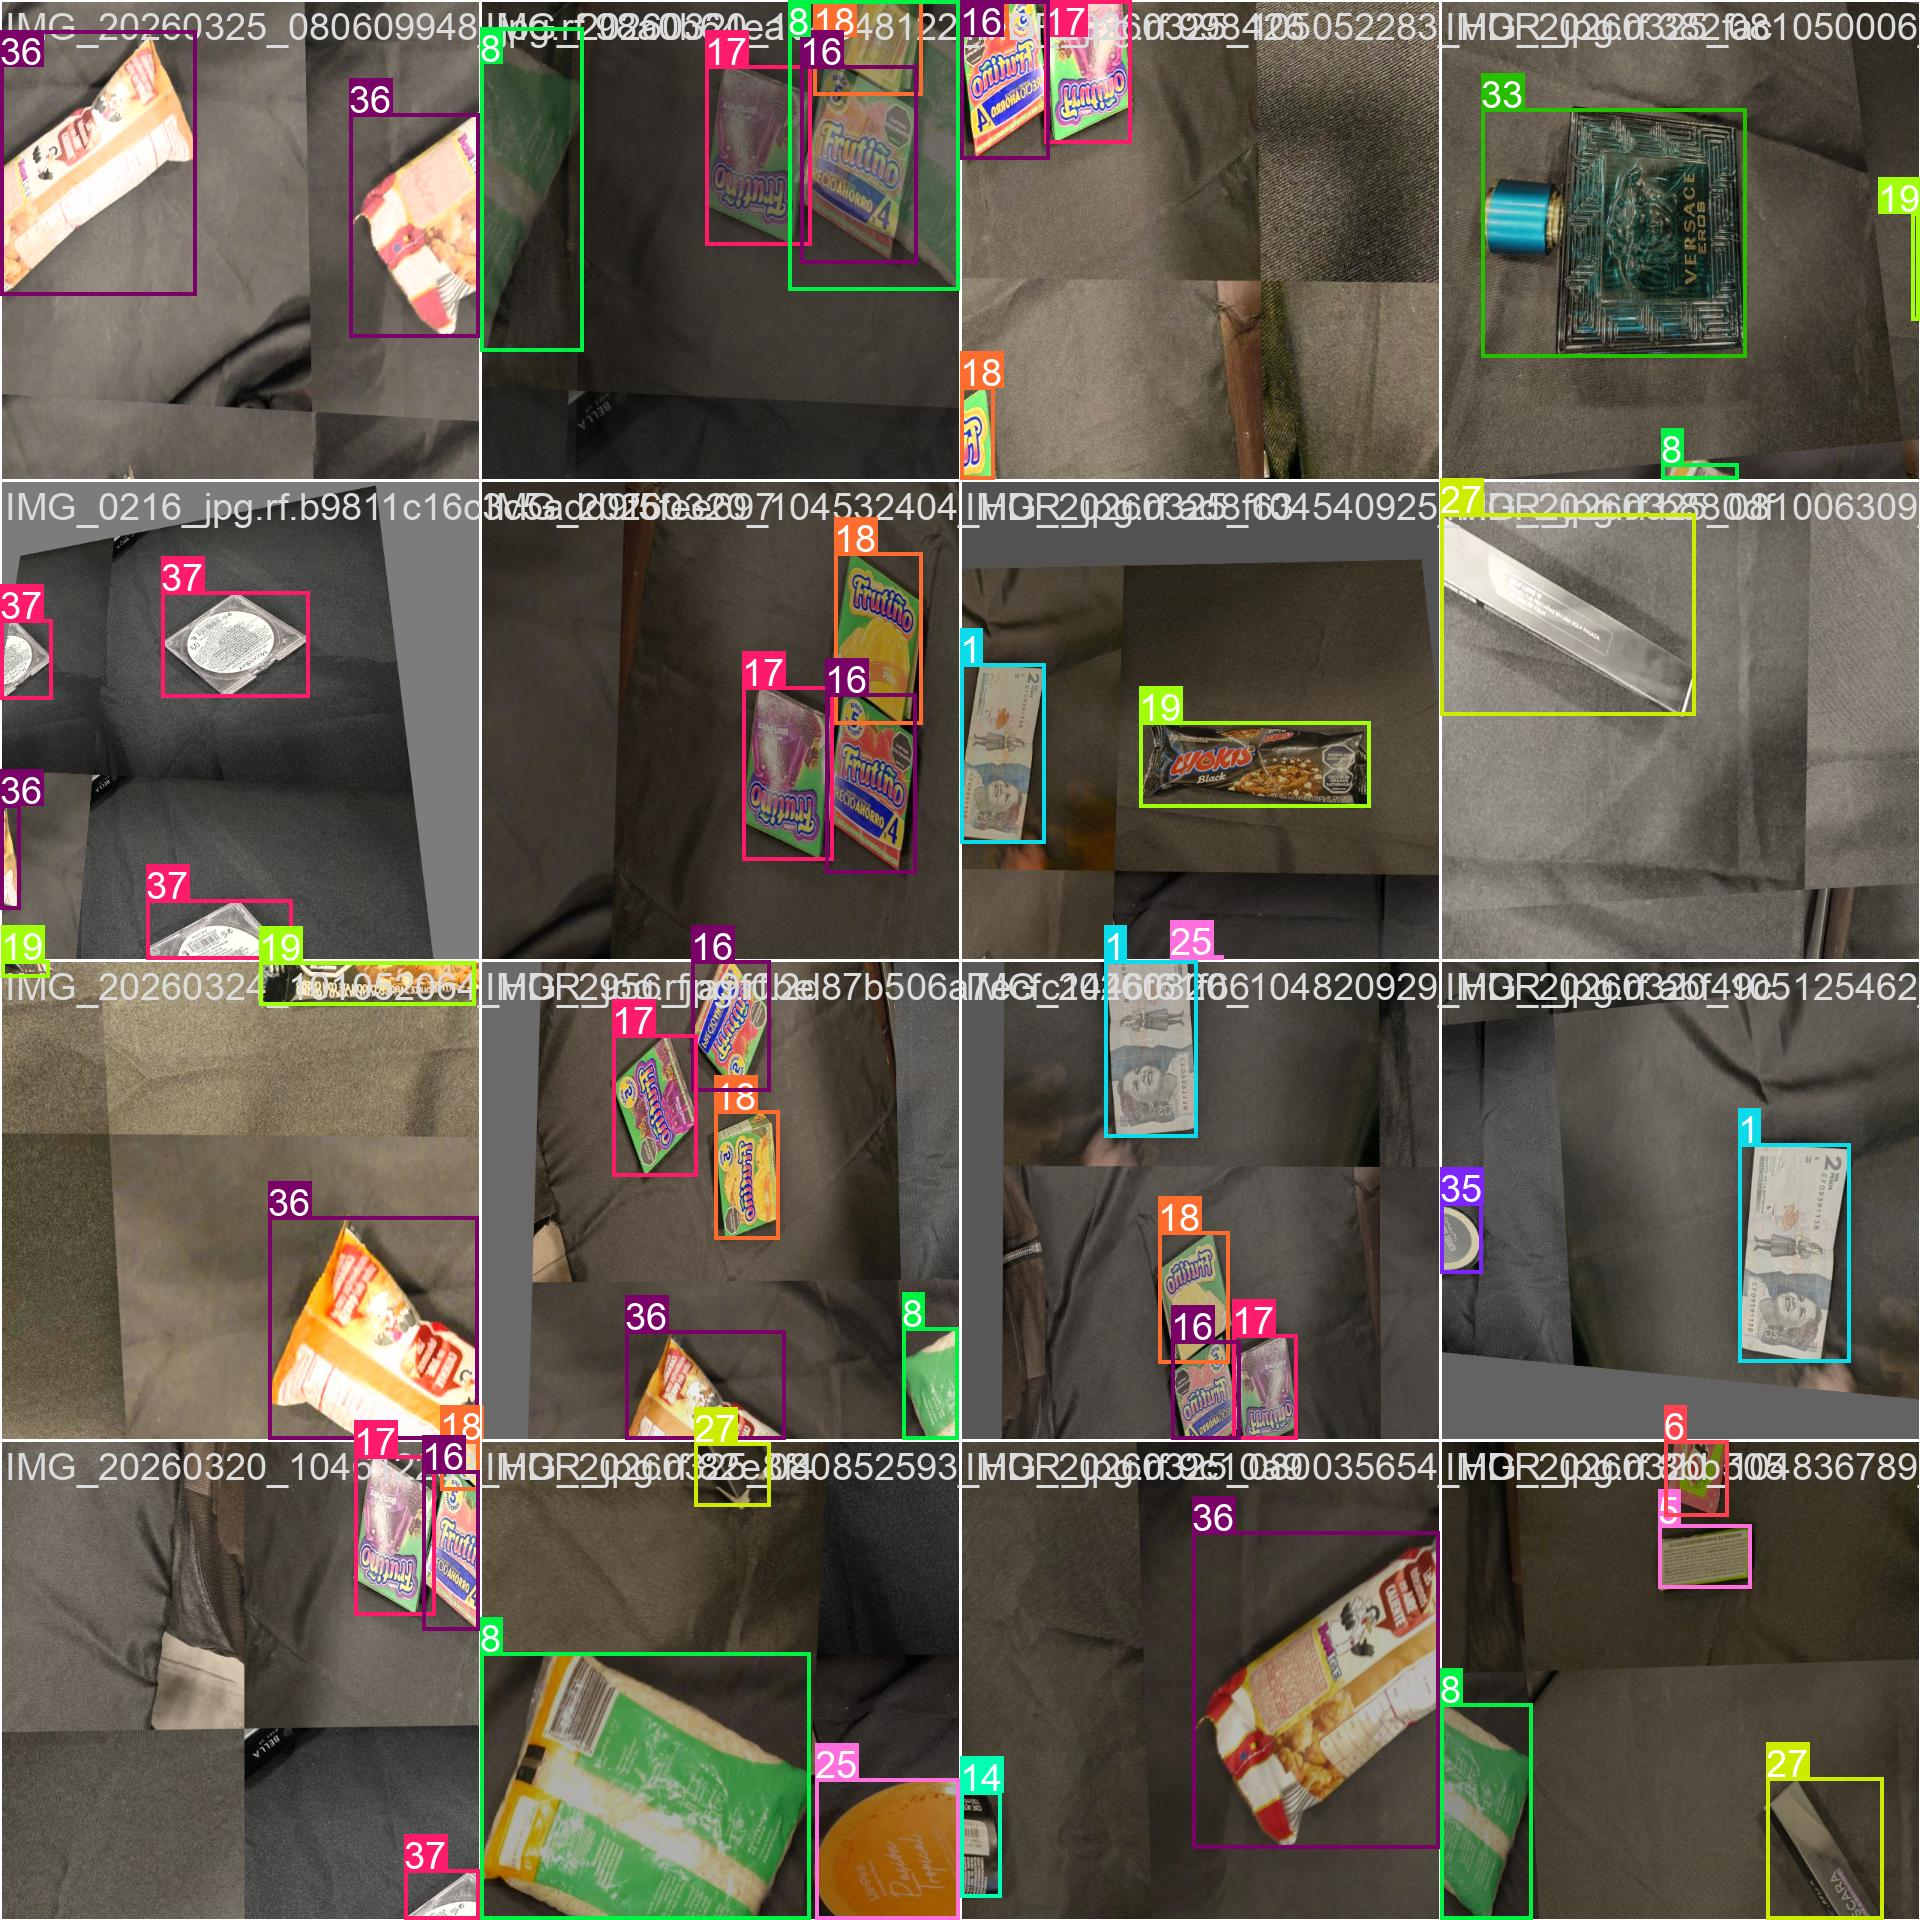

In [ ]:
display(Image('/content/runs/detect/train/train_batch1.jpg'))

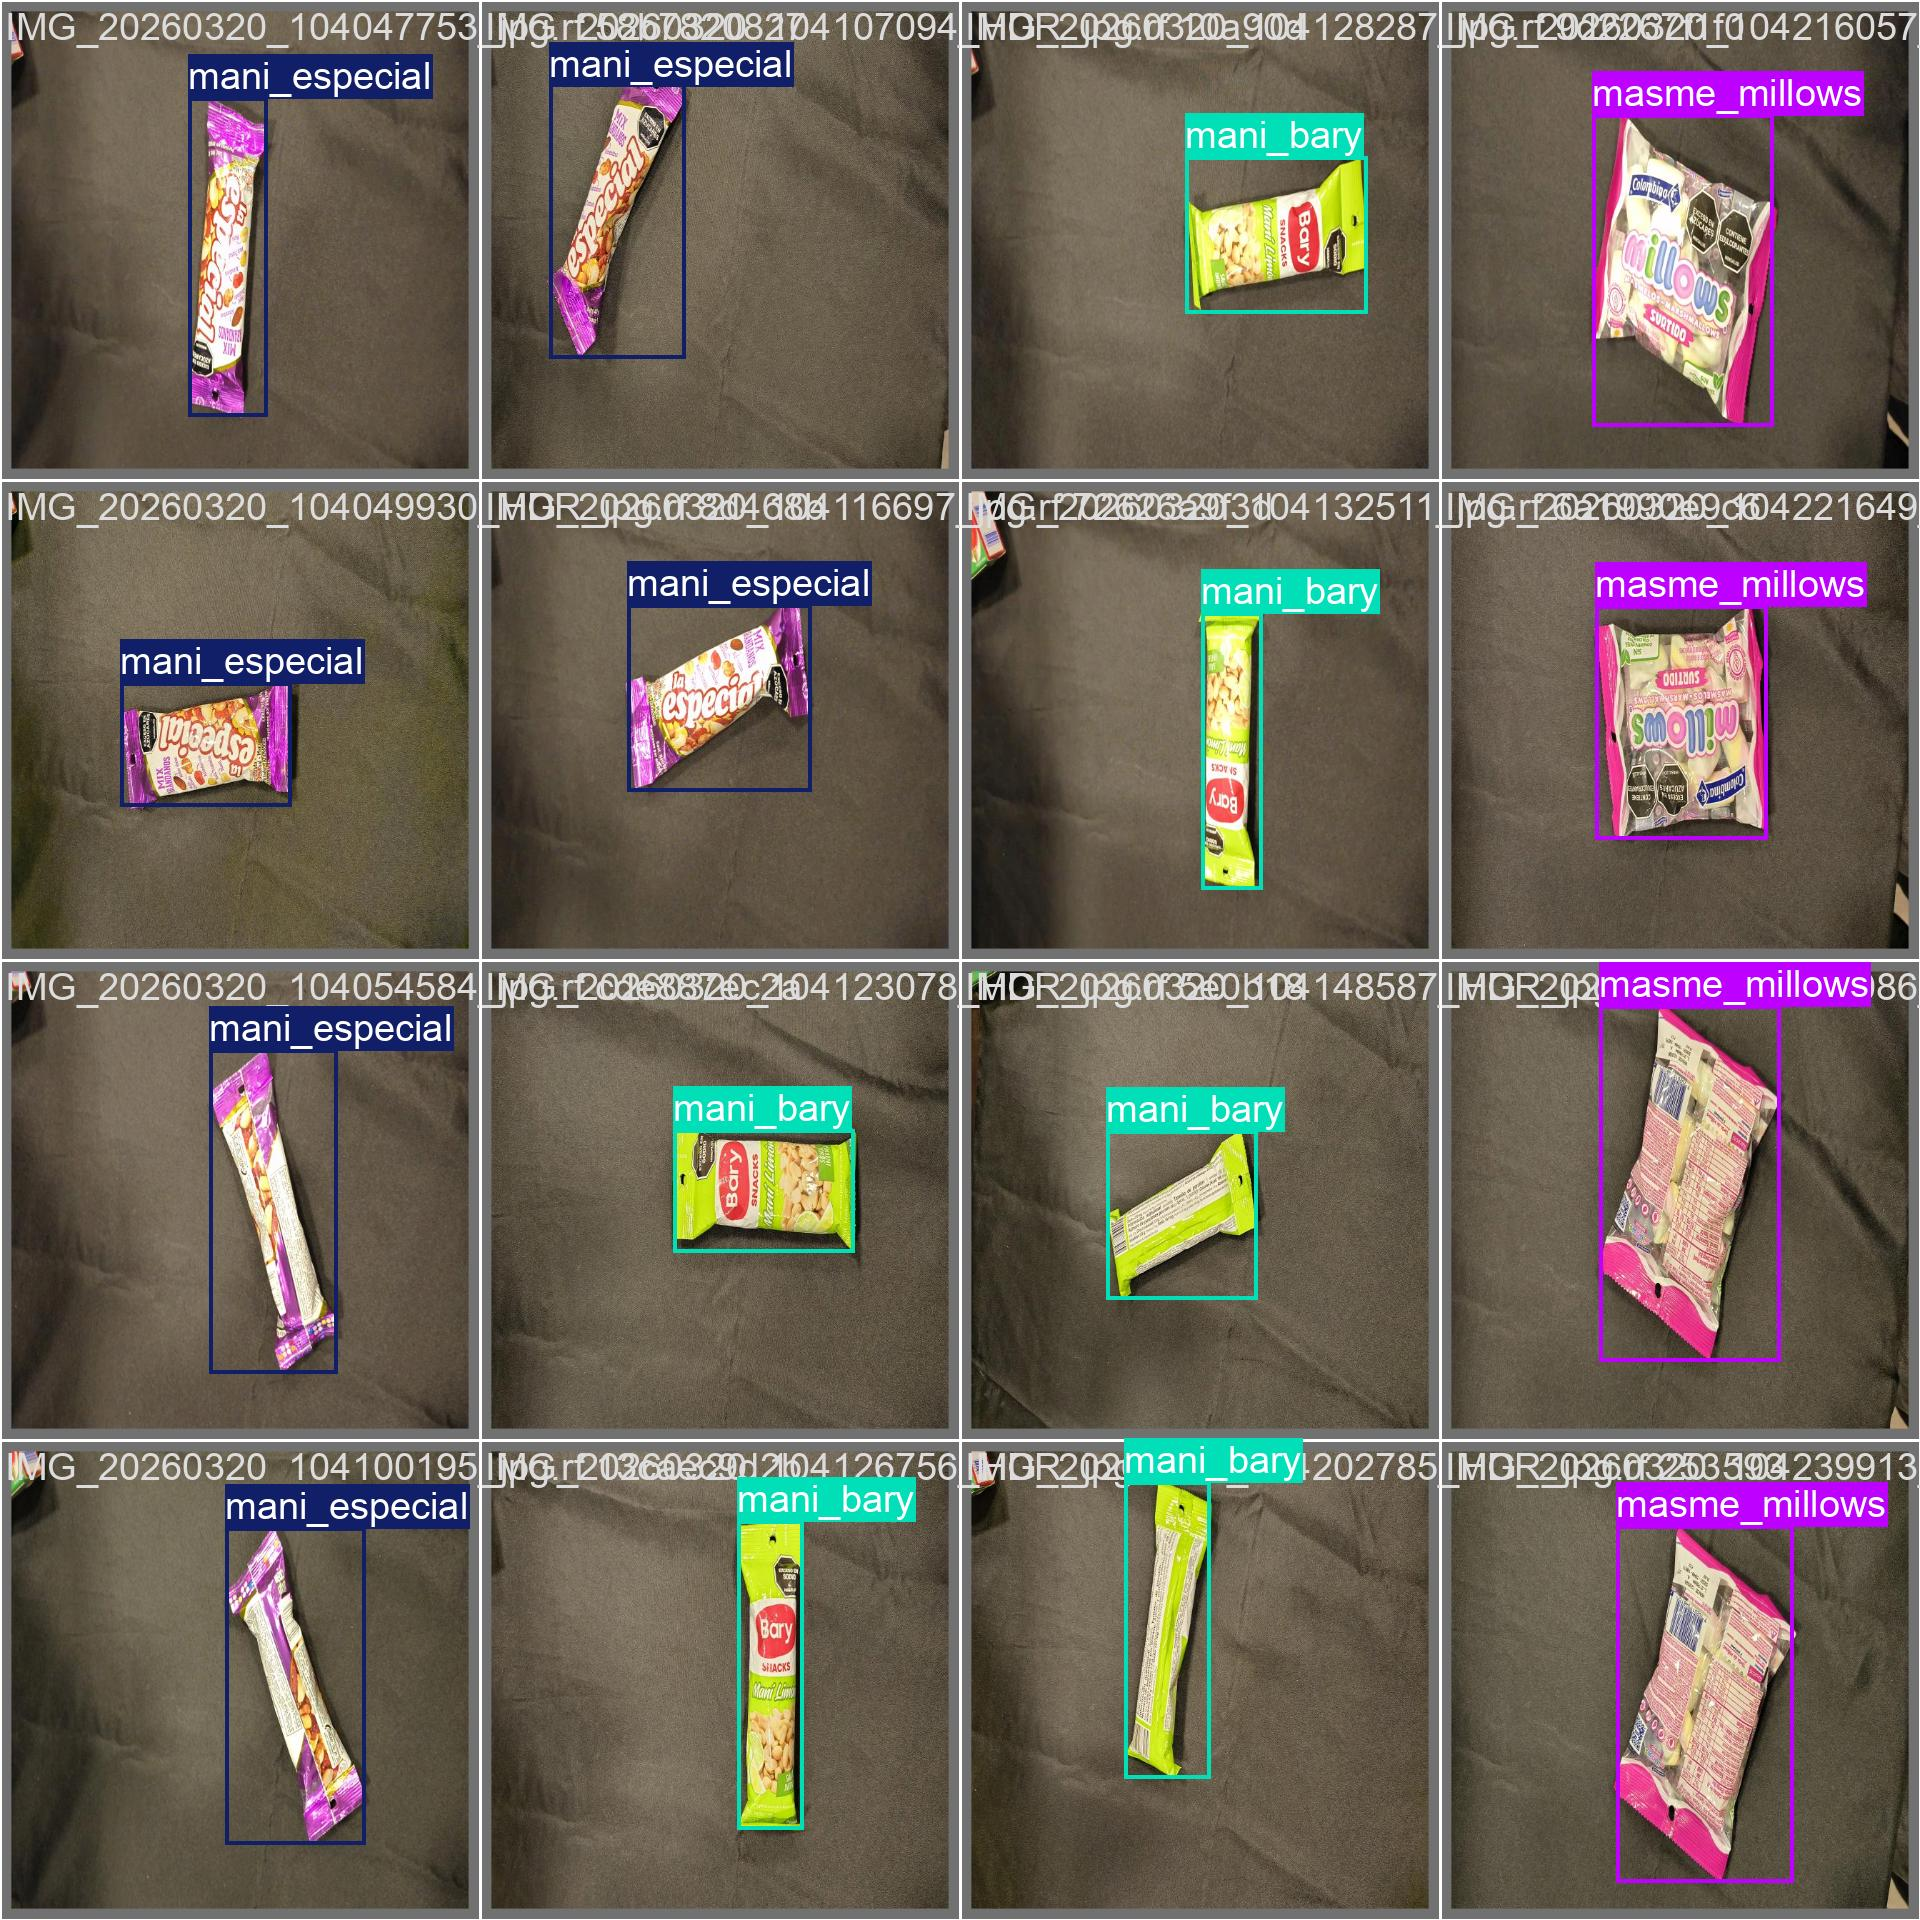

In [ ]:
display(Image('/content/runs/detect/train/val_batch2_labels.jpg'))

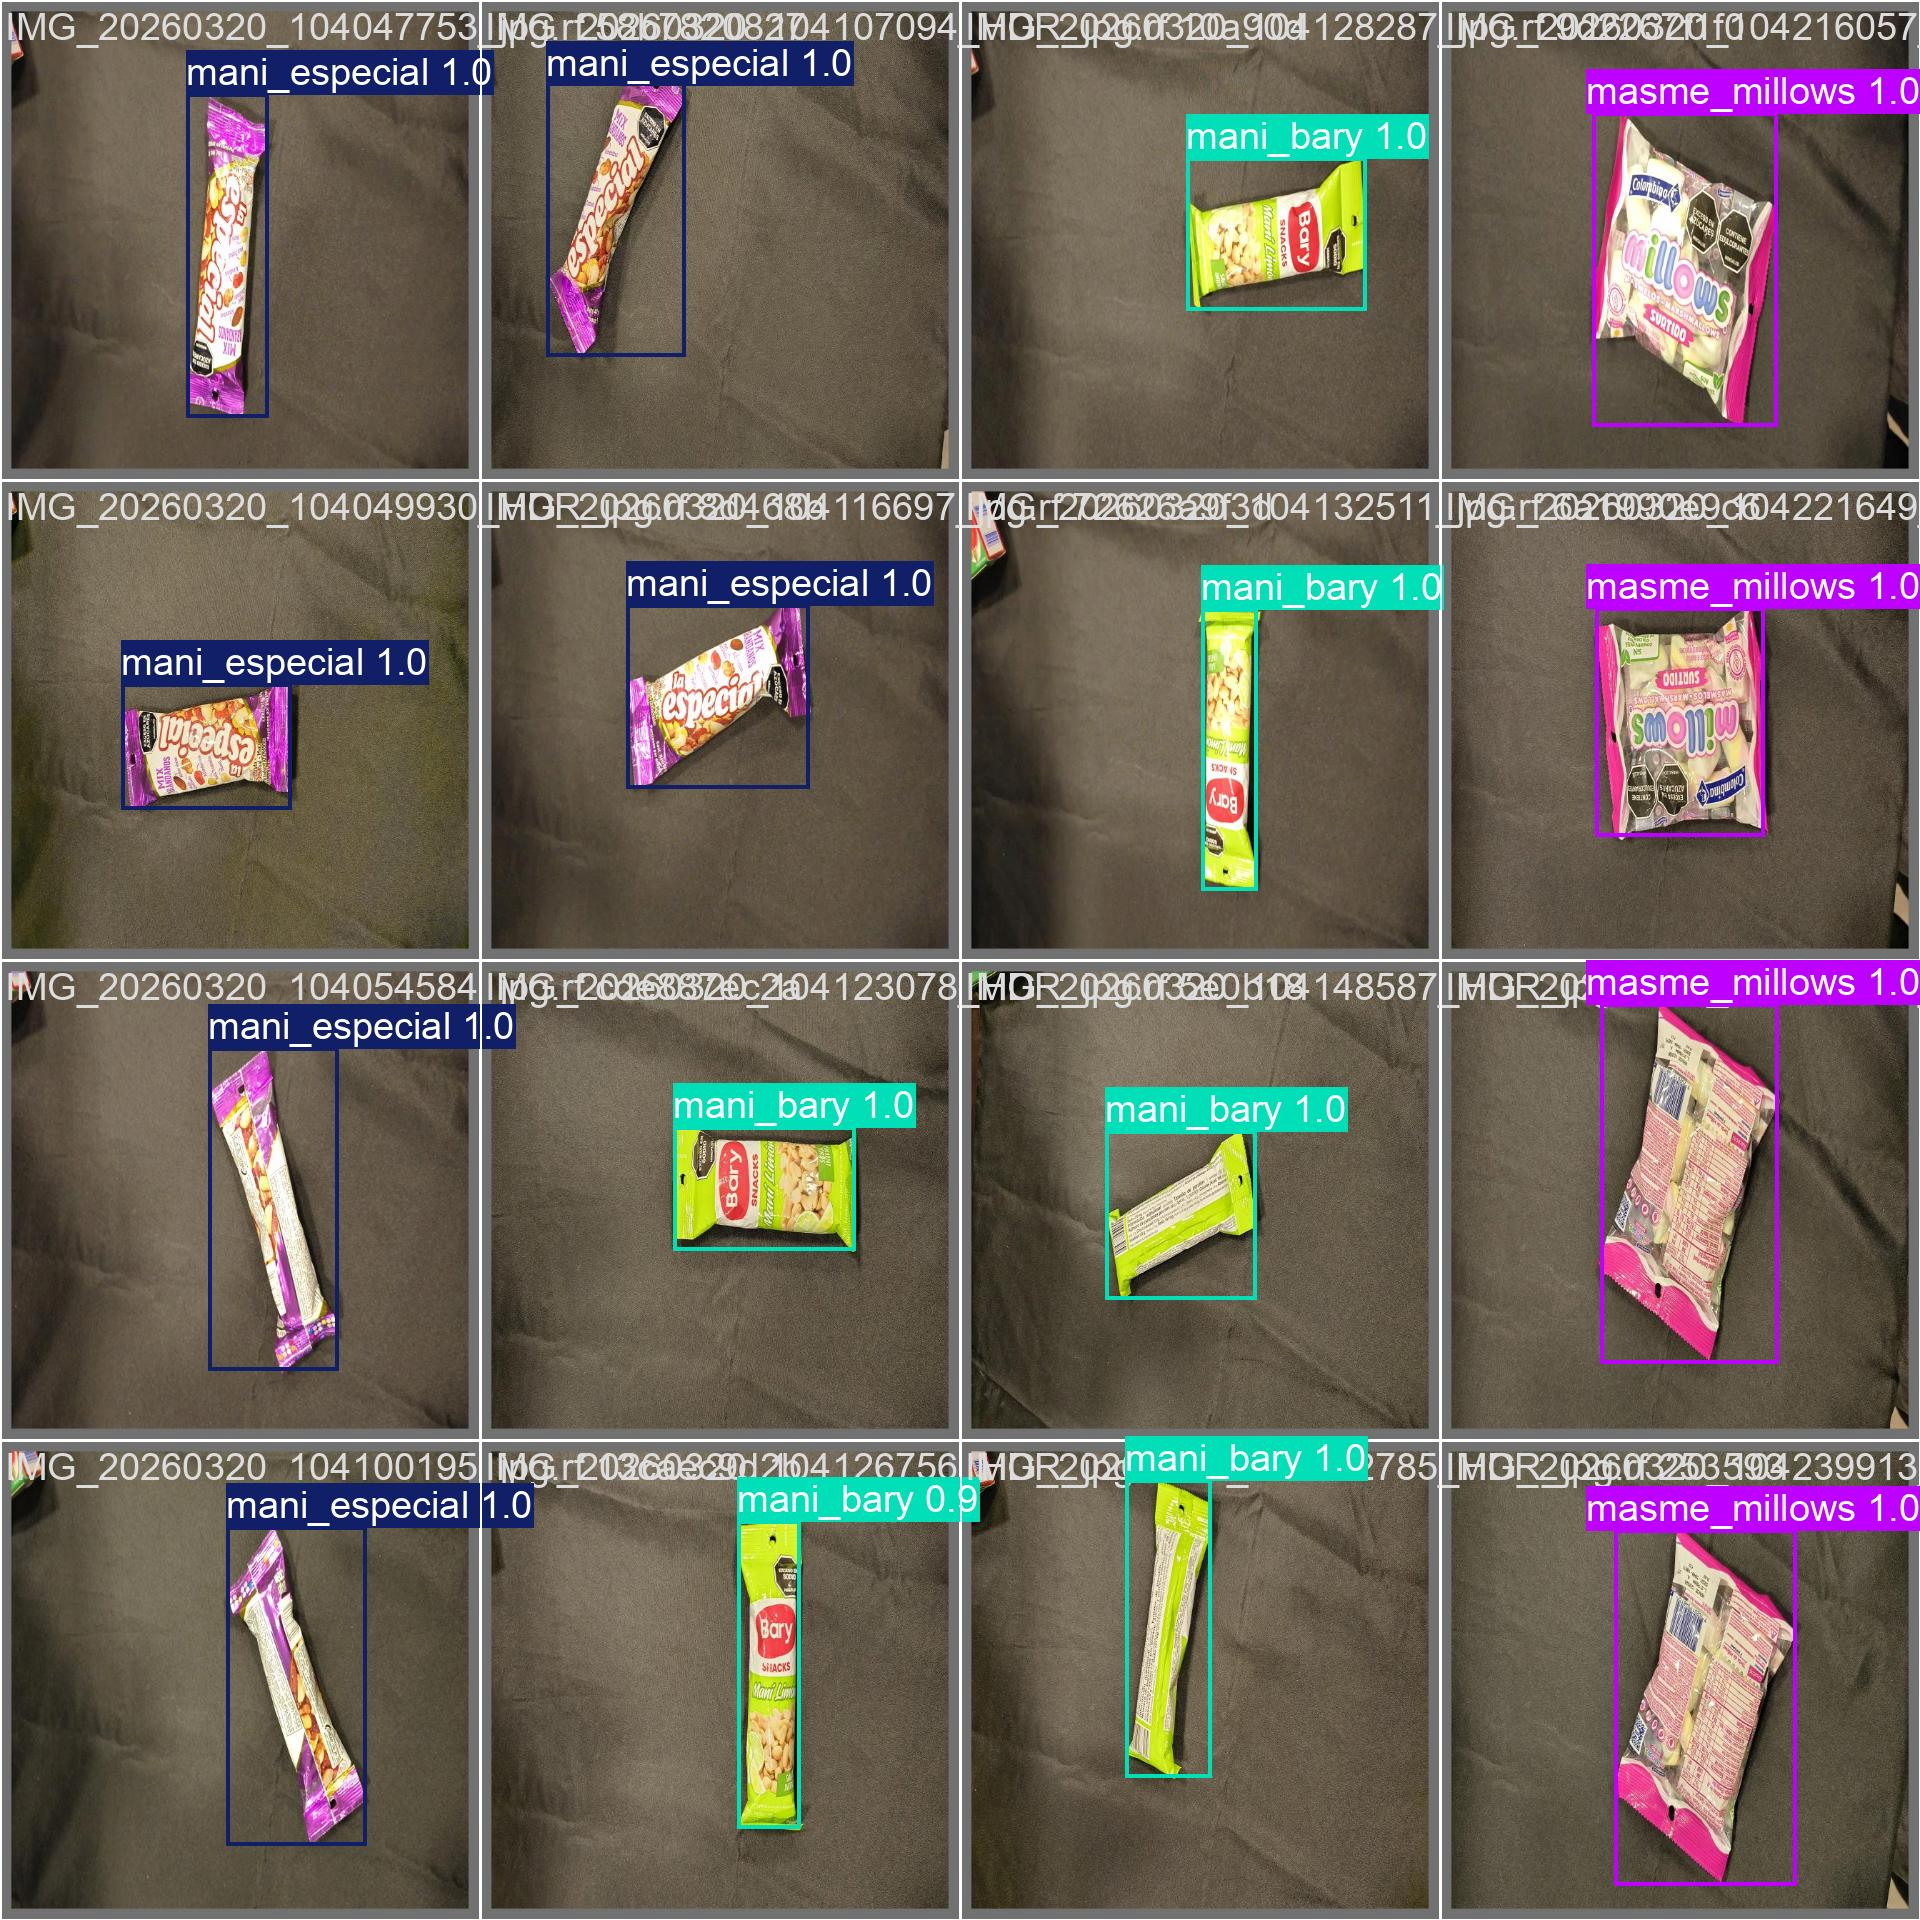

In [ ]:
display(Image('/content/runs/detect/train/val_batch2_pred.jpg'))